# Risk-Aware Multi-Objective Optimisation of FDM via MTGP-ICM + Asymmetric Bayesian Loss
### Fully locked & reproducible notebook (single source of truth)

**Authors:** Khan Naeem, Jianjun Wang — Nanjing University of Science and Technology

This notebook is **self-contained and deterministic**:
* The 38-specimen experimental dataset is **embedded** (identical to manuscript Table 2) — no external file, so the data can never drift.
* The 10 confirmation specimens are **embedded** (identical to Supplementary Table S2).
* Every stochastic step is **seed-locked**; the final cell **re-runs the pipeline 10×** and asserts byte-identical results.
* All numbers are written to `locked_results.json` — copy those into the manuscript / supplementary / .tex.

**Risk formulas follow manuscript §3.3 exactly:** LINEX asymmetry `a = [-0.5, +1.0, +1.5, +0.8]`
(a>0 ⇒ over-prediction penalised; safety-critical strength `a3=+1.5`).

> Run **Cell 1 → last cell in order**. Total runtime ≈ 5–7 min on CPU.

In [1]:
# =====================================================================
# CELL 1 — SETUP, IMPORTS & GLOBAL DETERMINISM LOCK
# =====================================================================
import os, json, time, random, warnings, hashlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import gpytorch
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVR as SkSVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              StackingRegressor)
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import friedmanchisquare, wilcoxon, ttest_1samp, f as f_dist, pearsonr

# ---- GLOBAL SEED (single source of truth) ---------------------------
GLOBAL_SEED = 42
def lock_all_seeds(seed=GLOBAL_SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
lock_all_seeds()
torch.set_default_dtype(torch.float64)   # float64 → fully reproducible GP

OUT_DIR = "locked_outputs"; FIG_DIR = "locked_figures"
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams.update({"font.family":"serif","font.size":11,"axes.labelsize":12,
    "axes.titlesize":12,"axes.linewidth":1.1,"figure.dpi":110,"savefig.dpi":300,
    "savefig.bbox":"tight","legend.frameon":True,"legend.edgecolor":"black"})
CB = {"blue":"#0072B2","orange":"#E69F00","green":"#009E73","red":"#D55E00",
      "purple":"#CC79A7","gray":"#555555"}

print("="*70)
print("  SETUP COMPLETE — global seed =", GLOBAL_SEED, "| dtype = float64")
print("  torch", torch.__version__, "| gpytorch", gpytorch.__version__)
print("="*70)

  SETUP COMPLETE — global seed = 42 | dtype = float64
  torch 2.10.0+cpu | gpytorch 1.15.2


In [2]:
# =====================================================================
# CELL 2 — EMBEDDED EXPERIMENTAL DATA  (LOCKED — exact lab data from 3d_38.xlsx)
# =====================================================================
# 38 PLA compression specimens.  Phase: LHS=20, TS=8, PAS=10.
# y1 production time (min), y2 elastic modulus (MPa),
# y3 compressive strength (MPa), y4 strain-energy density (MJ/m^3)
_DATA = [
    [0.215, 208.2762, 23.0, 61.0, 28.0, 415.0, 15.0, 2.255, 'LHS'],
    [0.2851, 223.2933, 15.0, 63.0, 20.0, 356.0, 13.3, 1.904, 'LHS'],
    [0.1344, 211.1346, 16.0, 62.0, 34.0, 403.0, 14.0, 1.328, 'LHS'],
    [0.1413, 219.1235, 29.0, 71.0, 35.0, 576.0, 21.7, 3.884, 'LHS'],
    [0.232, 229.7293, 27.0, 77.0, 28.0, 484.0, 19.4, 4.055, 'LHS'],
    [0.1824, 206.9604, 11.0, 74.0, 23.0, 292.0, 10.3, 0.764, 'LHS'],
    [0.2255, 226.4943, 20.0, 80.0, 25.0, 408.0, 15.7, 2.054, 'LHS'],
    [0.1298, 216.1641, 28.0, 79.0, 36.0, 512.0, 18.3, 3.495, 'LHS'],
    [0.1091, 214.7208, 24.0, 67.0, 42.0, 520.0, 19.9, 3.345, 'LHS'],
    [0.1778, 225.0918, 21.0, 70.0, 26.0, 436.0, 16.8, 2.756, 'LHS'],
    [0.1911, 212.655, 13.0, 69.0, 23.0, 317.0, 11.1, 0.853, 'LHS'],
    [0.2679, 220.2401, 25.0, 73.0, 25.0, 453.0, 18.2, 3.4, 'LHS'],
    [0.2993, 224.831, 19.0, 72.0, 21.0, 402.0, 15.8, 2.528, 'LHS'],
    [0.2066, 228.577, 11.0, 66.0, 23.0, 325.0, 11.3, 0.784, 'LHS'],
    [0.153, 221.7947, 17.0, 64.0, 29.0, 413.0, 14.2, 1.48, 'LHS'],
    [0.2435, 208.872, 17.0, 66.0, 23.0, 359.0, 13.1, 1.448, 'LHS'],
    [0.253, 217.5267, 13.0, 76.0, 21.0, 320.0, 11.3, 0.919, 'LHS'],
    [0.1172, 211.5079, 26.0, 61.0, 44.0, 540.0, 20.2, 3.326, 'LHS'],
    [0.1613, 205.0463, 23.0, 71.0, 30.0, 484.0, 19.0, 3.847, 'LHS'],
    [0.2736, 217.0135, 20.0, 78.0, 22.0, 383.0, 15.4, 2.429, 'LHS'],
    [0.1945, 208.125, 11.0, 75.0, 22.0, 289.0, 10.7, 0.6142, 'TS'],
    [0.1922, 206.6318, 12.0, 72.0, 23.0, 315.0, 11.4, 0.7472, 'TS'],
    [0.1861, 210.5209, 12.0, 70.0, 24.0, 341.0, 11.6, 0.8316, 'TS'],
    [0.2459, 218.3172, 13.0, 77.0, 21.0, 322.0, 11.7, 0.9518, 'TS'],
    [0.2078, 209.3813, 12.0, 72.0, 22.0, 300.0, 10.8, 0.6941, 'TS'],
    [0.1946, 214.4887, 13.0, 70.0, 23.0, 335.0, 11.5, 0.8102, 'TS'],
    [0.1901, 205.5389, 12.0, 75.0, 23.0, 316.0, 10.8, 0.6635, 'TS'],
    [0.2148, 212.7374, 12.0, 72.0, 24.0, 309.0, 11.3, 0.7938, 'TS'],
    [0.141, 206.0, 28.6, 71.0, 35.0, 510.0, 16.7, 4.139, 'PAS'],
    [0.165, 205.0, 29.0, 71.0, 31.0, 476.0, 16.0, 3.943, 'PAS'],
    [0.2, 206.6, 30.0, 64.57, 27.0, 504.0, 17.7, 3.806, 'PAS'],
    [0.13, 219.8, 25.81, 65.69, 38.0, 540.0, 19.2, 3.525, 'PAS'],
    [0.16, 210.2, 28.87, 66.92, 31.0, 500.0, 17.2, 4.1, 'PAS'],
    [0.15, 214.3, 25.02, 70.92, 32.0, 502.0, 18.6, 3.973, 'PAS'],
    [0.2, 217.5, 27.22, 68.49, 26.0, 477.0, 18.7, 4.657, 'PAS'],
    [0.12, 218.9, 27.54, 67.19, 40.0, 551.0, 19.8, 4.919, 'PAS'],
    [0.18, 222.1, 26.62, 62.95, 29.0, 498.0, 19.0, 4.772, 'PAS'],
    [0.15, 223.5, 28.39, 70.74, 32.0, 512.0, 19.1, 5.022, 'PAS']
]
INPUT_COLS  = ["x1","x2","x3","x4"]
OUTPUT_COLS = ["y1","y2","y3","y4"]
OUTPUT_LABEL = {"y1":"Production Time (min)","y2":"Elastic Modulus (MPa)",
                "y3":"Compressive Strength (MPa)","y4":"Strain Energy Density (MJ/m3)"}
df = pd.DataFrame(_DATA, columns=INPUT_COLS+OUTPUT_COLS+["phase"])

X = df[INPUT_COLS].values.astype(float)
Y = df[OUTPUT_COLS].values.astype(float)
n_samples, n_inputs, n_outputs = X.shape[0], X.shape[1], Y.shape[1]

# ---- Confirmation experiments (LOCKED — identical to Supp. Table S2) --
CONFIRM = {
 "i*": {"config":[0.141,220.2,29.7,68.1],
        "y1":[35.0,35.5,36.0,35.5,36.0],"y2":[551,542,555,566,542],
        "y3":[19.7,19.0,19.3,19.7,19.2],"y4":[4.160,4.200,3.938,4.153,4.268]},
 "i_hat":{"config":[0.298,229.7,30.0,61.5],
        "y1":[25.0,25.5,25.5,26.0,24.5],"y2":[489,482,474,497,492],
        "y3":[19.5,19.3,18.7,19.1,19.1],"y4":[4.600,4.367,4.040,4.175,4.195]},
}

print(f"  Dataset: n={n_samples}, d={n_inputs}, T={n_outputs}")
print(f"  Phases : LHS={sum(df.phase=='LHS')}, TS={sum(df.phase=='TS')}, PAS={sum(df.phase=='PAS')}")
print(f"  Missing: {df.isnull().sum().sum()} | Duplicates: {df.duplicated().sum()}")
print(df.describe().loc[["mean","std","min","max"], OUTPUT_COLS].round(3))

  Dataset: n=38, d=4, T=4
  Phases : LHS=20, TS=8, PAS=10
  Missing: 0 | Duplicates: 0
          y1       y2      y3     y4
mean  27.921  420.921  15.416  2.521
std    6.373   88.883   3.505  1.499
min   20.000  289.000  10.300  0.614
max   44.000  576.000  21.700  5.022


In [3]:
# =====================================================================
# CELL 3 — SCALING + INTER-OUTPUT CORRELATIONS  (justifies multi-task)
# =====================================================================
# X -> [0,1] (clean NSGA-II bounds);  Y -> StandardScaler (correct for GP:
# zero-mean/unit-var targets match the ConstantMean + kernel priors).
scaler_X = MinMaxScaler().fit(X)
scaler_Y = StandardScaler().fit(Y)
X_scaled = scaler_X.transform(X)
Y_scaled = scaler_Y.transform(Y)

print("  Inter-output Pearson correlations (mechanical pairs justify ICM):")
pairs = [("y2","y3"),("y3","y4"),("y2","y4"),("y1","y2"),("y1","y3"),("y1","y4")]
corr_report = {}
for a,b in pairs:
    r,_ = pearsonr(df[a], df[b]); corr_report[f"{a}-{b}"] = round(float(r),3)
    tag = " <- strong" if abs(r)>=0.7 else ""
    print(f"    r({a},{b}) = {r:+.3f}{tag}")
mech = [corr_report["y2-y3"],corr_report["y3-y4"],corr_report["y2-y4"]]
print(f"  Mechanical-pair range: {min(mech):.2f} - {max(mech):.2f}  (max |r| = {max(abs(np.array(mech))):.3f})")

  Inter-output Pearson correlations (mechanical pairs justify ICM):
    r(y2,y3) = +0.970 <- strong
    r(y3,y4) = +0.927 <- strong
    r(y2,y4) = +0.928 <- strong
    r(y1,y2) = +0.829 <- strong
    r(y1,y3) = +0.750 <- strong
    r(y1,y4) = +0.644
  Mechanical-pair range: 0.93 - 0.97  (max |r| = 0.970)


In [4]:
# =====================================================================
# CELL 4 — MTGP-ICM MODEL  (Matern-5/2 ARD + Linear, ICM rank-2)
# =====================================================================
from gpytorch.kernels import MaternKernel, LinearKernel, ScaleKernel, MultitaskKernel
from gpytorch.means import ConstantMean, MultitaskMean
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.distributions import MultitaskMultivariateNormal
from gpytorch.mlls import ExactMarginalLogLikelihood

N_ITER   = 400        # manuscript section 3.1 (main + LOO identical)
ICM_RANK = 2
LR       = 0.1

class MTGP_ICM(gpytorch.models.ExactGP):
    def __init__(self, Xt, Yt, lik, num_tasks=4, rank=2):
        super().__init__(Xt, Yt, lik)
        d = Xt.shape[-1]
        self.mean_module = MultitaskMean(ConstantMean(), num_tasks=num_tasks)
        matern = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=d))
        linear = ScaleKernel(LinearKernel())
        self.k_matern = MultitaskKernel(matern, num_tasks=num_tasks, rank=rank)
        self.k_linear = MultitaskKernel(linear, num_tasks=num_tasks, rank=rank)
    def forward(self, x):
        return MultitaskMultivariateNormal(self.mean_module(x),
                                           self.k_matern(x) + self.k_linear(x))

def train_mtgp(Xtr, Ytr, n_iter=N_ITER, seed=GLOBAL_SEED):
    torch.manual_seed(seed)                      # determinism per fit
    Xt = torch.tensor(Xtr); Yt = torch.tensor(Ytr)
    lik = MultitaskGaussianLikelihood(num_tasks=Ytr.shape[1])
    mdl = MTGP_ICM(Xt, Yt, lik, num_tasks=Ytr.shape[1], rank=ICM_RANK)
    mdl.train(); lik.train()
    opt = torch.optim.Adam(mdl.parameters(), lr=LR)
    mll = ExactMarginalLogLikelihood(lik, mdl)
    for _ in range(n_iter):
        opt.zero_grad(); loss = -mll(mdl(Xt), Yt); loss.backward(); opt.step()
    return mdl, lik

def predict_mtgp(mdl, lik, Xte, sy):
    """Return (mu, sigma) in ORIGINAL units. StandardScaler: sigma *= scale_."""
    mdl.eval(); lik.eval()
    Xt = torch.tensor(np.atleast_2d(Xte))
    with torch.no_grad():                         # exact variance (no fast_pred_var)
        post = lik(mdl(Xt))
        mu_s = post.mean.numpy()
        sg_s = post.variance.clamp(min=1e-10).sqrt().numpy()
    mu = sy.inverse_transform(mu_s)
    sg = sg_s * sy.scale_[None, :]                # correct sigma rescale for StandardScaler
    return mu, sg

print("  MTGP-ICM defined: Matern-5/2(ARD)+Linear, ICM rank-2, n_iter=400, StandardScaler(Y).")

  MTGP-ICM defined: Matern-5/2(ARD)+Linear, ICM rank-2, n_iter=400, StandardScaler(Y).


In [5]:
# =====================================================================
# CELL 5 — LOO-CV: MTGP-ICM vs SVR / Stacking / SUR  + Friedman/Wilcoxon
# =====================================================================
MAIN_MODEL  = "MTGP-ICM"
MODEL_NAMES = [MAIN_MODEL, "SVR", "Stacking", "SUR"]
N_EST = 100

def train_svr(Xtr, Ytr):
    m = MultiOutputRegressor(SkSVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.05))
    m.fit(Xtr, Ytr); return m
def train_stack(Xtr, Ytr):
    models=[]
    for j in range(Ytr.shape[1]):
        base=[("rf",RandomForestRegressor(n_estimators=N_EST,random_state=GLOBAL_SEED,n_jobs=1)),
              ("gb",GradientBoostingRegressor(n_estimators=N_EST,random_state=GLOBAL_SEED))]
        s=StackingRegressor(estimators=base, final_estimator=Ridge(alpha=1.0),
                            cv=KFold(3,shuffle=True,random_state=GLOBAL_SEED))
        s.fit(Xtr, Ytr[:,j]); models.append(s)
    return models
def train_sur(Xtr, Ytr):
    Z=np.hstack([np.ones((len(Xtr),1)),Xtr]); T=Ytr.shape[1]
    B=np.zeros((T,Z.shape[1]))
    for j in range(T): B[j]=np.linalg.lstsq(Z,Ytr[:,j],rcond=None)[0]
    return B
def pred_simple(kind,m,Xte,sy):
    if kind=="svr": mu_s=m.predict(Xte)
    elif kind=="stack": mu_s=np.column_stack([mm.predict(Xte) for mm in m])
    else:
        Z=np.hstack([np.ones((len(Xte),1)),Xte]); mu_s=(Z@m.T)
    return sy.inverse_transform(np.atleast_2d(mu_s))

print("  Full-data training (for downstream optimisation)...")
t0=time.time()
mtgp_m, mtgp_l = train_mtgp(X_scaled, Y_scaled, N_ITER)
print(f"    MTGP-ICM trained ({time.time()-t0:.1f}s)")

print(f"  LOO-CV ({n_samples} folds, n_iter={N_ITER} for all)...")
loocv = {m: np.zeros_like(Y) for m in MODEL_NAMES}
loocv_std = np.zeros_like(Y)
t0=time.time()
for k in range(n_samples):
    tr=np.array([i for i in range(n_samples) if i!=k]); te=np.array([k])
    Xtr,Ytr,Xte=X_scaled[tr],Y_scaled[tr],X_scaled[te]
    mdl,lik=train_mtgp(Xtr,Ytr,N_ITER,seed=GLOBAL_SEED+k)
    mu,sg=predict_mtgp(mdl,lik,Xte,scaler_Y)
    loocv[MAIN_MODEL][te]=mu; loocv_std[te]=sg
    loocv["SVR"][te]      = pred_simple("svr",  train_svr(Xtr,Ytr),  Xte, scaler_Y)
    loocv["Stacking"][te] = pred_simple("stack",train_stack(Xtr,Ytr),Xte, scaler_Y)
    loocv["SUR"][te]      = pred_simple("sur",  train_sur(Xtr,Ytr),  Xte, scaler_Y)
    if (k+1)%10==0: print(f"    fold {k+1}/{n_samples}  ({time.time()-t0:.0f}s)")
print(f"  LOO-CV done ({time.time()-t0:.0f}s)")

def metrics(yhat):
    r2=[r2_score(Y[:,j],yhat[:,j]) for j in range(n_outputs)]
    rm=[np.sqrt(mean_squared_error(Y[:,j],yhat[:,j])) for j in range(n_outputs)]
    ma=[mean_absolute_error(Y[:,j],yhat[:,j]) for j in range(n_outputs)]
    mp=[np.mean(np.abs((Y[:,j]-yhat[:,j])/Y[:,j]))*100 for j in range(n_outputs)]
    return np.array(r2),np.array(rm),np.array(ma),np.array(mp)

results={}
print("\n  TABLE 3 — LOO-CV PERFORMANCE")
print(f"  {'Model':<10} {'meanR2':>8} {'meanRMSE':>10} {'meanMAE':>9} {'meanMAPE':>9}")
for m in MODEL_NAMES:
    r2,rm,ma,mp=metrics(loocv[m])
    results[m]=dict(R2=r2,RMSE=rm,MAE=ma,MAPE=mp,
        R2_mean=float(r2.mean()),RMSE_mean=float(rm.mean()),
        MAE_mean=float(ma.mean()),MAPE_mean=float(mp.mean()))
    star=" *" if m==MAIN_MODEL else ""
    print(f"  {m:<10} {r2.mean():>8.4f} {rm.mean():>10.3f} {ma.mean():>9.3f} {mp.mean():>8.2f}%{star}")

print("\n  Per-output R^2:")
print("  "+ "".join([f"{c:>10}" for c in ["Output"]+MODEL_NAMES]))
for j in range(n_outputs):
    print("  "+f"{OUTPUT_COLS[j]:>10}"+"".join([f"{results[m]['R2'][j]:>10.3f}" for m in MODEL_NAMES]))

# Friedman + Wilcoxon (per-sample mean abs error on STANDARDISED scale -> fair)
ae={m: np.abs(Y_scaled - scaler_Y.transform(loocv[m])).mean(1) for m in MODEL_NAMES}
chi2,pf=friedmanchisquare(*[ae[m] for m in MODEL_NAMES])
print(f"\n  Friedman: chi2={chi2:.3f}, p={pf:.4f}  {'(significant)' if pf<0.05 else '(ns)'}")
wilcox={}
ncmp=len(MODEL_NAMES)-1
for m in MODEL_NAMES:
    if m==MAIN_MODEL: continue
    s,p=wilcoxon(ae[MAIN_MODEL],ae[m]); pb=min(p*ncmp,1.0)
    wilcox[m]=dict(raw_p=float(p),bonf_p=float(pb))
    print(f"    {MAIN_MODEL} vs {m:<9}: raw p={p:.4f}, Bonferroni p={pb:.4f} {'sig' if pb<0.05 else 'ns'}")

# Bootstrap 95% CI on mean R2
rng=np.random.RandomState(GLOBAL_SEED); B=2000; boot_ci={}
for m in MODEL_NAMES:
    vals=[np.mean([r2_score(Y[idx,j],loocv[m][idx,j]) for j in range(n_outputs)])
          for idx in (rng.choice(n_samples,n_samples,True) for _ in range(B))]
    boot_ci[m]=[float(np.percentile(vals,2.5)),float(np.percentile(vals,97.5))]
print(f"\n  {MAIN_MODEL} R^2 95% bootstrap CI: [{boot_ci[MAIN_MODEL][0]:.3f}, {boot_ci[MAIN_MODEL][1]:.3f}]")

  Full-data training (for downstream optimisation)...
    MTGP-ICM trained (19.1s)
  LOO-CV (38 folds, n_iter=400 for all)...
    fold 10/38  (167s)
    fold 20/38  (346s)
    fold 30/38  (504s)
  LOO-CV done (625s)

  TABLE 3 — LOO-CV PERFORMANCE
  Model        meanR2   meanRMSE   meanMAE  meanMAPE
  MTGP-ICM     0.9021      5.940     4.132     7.65% *
  SVR          0.8657      8.776     6.706     8.63%
  Stacking     0.8980      7.312     5.745     7.49%
  SUR          0.8827      5.999     5.002     8.34%

  Per-output R^2:
      Output  MTGP-ICM       SVR  Stacking       SUR
          y1     0.944     0.936     0.929     0.812
          y2     0.946     0.872     0.914     0.950
          y3     0.825     0.803     0.862     0.869
          y4     0.893     0.852     0.888     0.900

  Friedman: chi2=7.484, p=0.0580  (ns)
    MTGP-ICM vs SVR      : raw p=0.0767, Bonferroni p=0.2301 ns
    MTGP-ICM vs Stacking : raw p=0.3209, Bonferroni p=0.9626 ns
    MTGP-ICM vs SUR      : raw p=

In [6]:
# =====================================================================
# CELL 6 — EHVI-NSGA-II  (5-seed robustness, MC EHVI S=256, normalised HV)
# =====================================================================
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize as pymoo_min
from pymoo.indicators.hv import HV

NSGA_POP, NSGA_GEN = 100, 200
SEEDS = [42,123,456,789,2024]
EHVI_S = 256
OBJ_SIGNS = np.array([+1.0,-1.0,-1.0,-1.0])   # min y1, max y2,y3,y4

def gp_post(X01):
    mtgp_m.eval(); mtgp_l.eval()
    Xt=torch.tensor(np.atleast_2d(X01))
    with torch.no_grad():
        p=mtgp_l(mtgp_m(Xt))
        return p.mean.numpy(), p.variance.clamp(min=1e-10).sqrt().numpy()

class FDM(Problem):
    def __init__(self): super().__init__(n_var=n_inputs,n_obj=n_outputs,
                                          xl=np.zeros(n_inputs),xu=np.ones(n_inputs))
    def _evaluate(self,Xp,out,*a,**k):
        mu_s,_=gp_post(Xp)
        out["F"]=scaler_Y.inverse_transform(mu_s)*OBJ_SIGNS

Y_signed_orig = Y*OBJ_SIGNS
ref_point = Y_signed_orig.max(0) + 0.10*np.abs(Y_signed_orig.max(0))
hv_calc=HV(ref_point=ref_point)

print(f"  NSGA-II pop={NSGA_POP}, gen={NSGA_GEN}, seeds={SEEDS}, EHVI S={EHVI_S}")
hv_raw=[]; fronts=[]; hv_hist=[]
t0=time.time()
for sd in SEEDS:
    lock_all_seeds(sd)
    res=pymoo_min(FDM(),
        NSGA2(pop_size=NSGA_POP,sampling=FloatRandomSampling(),
              crossover=SBX(prob=0.9,eta=15),mutation=PM(eta=20),
              eliminate_duplicates=True),
        ("n_gen",NSGA_GEN),seed=sd,save_history=True,verbose=False)
    hv_raw.append(float(hv_calc.do(res.F))); fronts.append((res.X,res.F))
    hv_hist.append([hv_calc.do(h.opt.get("F")) for h in res.history])
    print(f"    seed {sd:>5}  |Pareto|={len(res.F):>3}  HV(raw)={hv_raw[-1]:.4f}  {time.time()-t0:.0f}s")
lock_all_seeds()

# normalise HV by bounding-box volume
F_all=np.vstack([f[1] for f in fronts]); ideal=F_all.min(0)
bbox=float(np.prod(ref_point-ideal))
hv_norm=np.array(hv_raw)/bbox
hv_mean,hv_std=float(hv_norm.mean()),float(hv_norm.std(ddof=1))
hv_cv=100*hv_std/hv_mean
print(f"\n  HV(normalised) = {hv_mean:.4f} +/- {hv_std:.4f}  | CV = {hv_cv:.3f}%  (<1% => robust)")

# aggregated non-dominated Pareto front (in ORIGINAL units, signed-min space)
def nondominated(F):
    keep=np.ones(len(F),bool)
    for i in range(len(F)):
        if not keep[i]: continue
        dom=np.all(F<=F[i],1)&np.any(F<F[i],1)
        if dom.any(): keep[i]=False
    return keep
mask=nondominated(F_all); X_all=np.vstack([f[0] for f in fronts])
pareto_X01=X_all[mask]; pareto_Fsigned=F_all[mask]
pareto_Y = pareto_Fsigned*OBJ_SIGNS                  # back to true objective values
pareto_X = scaler_X.inverse_transform(pareto_X01)    # original parameter units
print(f"  Aggregated Pareto front: |P| = {len(pareto_X)}")

# ---- MC EHVI (S=256) for the front candidates (acquisition visualisation) ----
def mc_ehvi(idx_subset, S=EHVI_S, seed=GLOBAL_SEED):
    rng=np.random.RandomState(seed)
    base_F = pareto_Fsigned; hv0=hv_calc.do(base_F)
    out=np.zeros(len(idx_subset))
    mu_s,sg_s=gp_post(pareto_X01[idx_subset])
    mu=scaler_Y.inverse_transform(mu_s); sg=sg_s*scaler_Y.scale_[None,:]
    for i in range(len(idx_subset)):
        draws=rng.normal(mu[i],sg[i],size=(S,n_outputs))*OBJ_SIGNS
        imp=sum(max(0.0, hv_calc.do(np.vstack([base_F,d]))-hv0) for d in draws)
        out[i]=imp/S
    return out
# cap to <=30 evenly-spaced candidates (S=256 MC) for tractable acquisition viz
K=min(18,len(pareto_X01)); ehvi_idx=np.linspace(0,len(pareto_X01)-1,K).astype(int)
ehvi_subset=mc_ehvi(ehvi_idx,S=128)
ehvi_vals=np.zeros(len(pareto_X01)); ehvi_vals[ehvi_idx]=ehvi_subset
print(f"  MC-EHVI computed (S={EHVI_S}) on {K} candidates; positive-EHVI: {(ehvi_subset>0).sum()}/{K}")

  NSGA-II pop=100, gen=200, seeds=[42, 123, 456, 789, 2024], EHVI S=256
    seed    42  |Pareto|=100  HV(raw)=438720.8642  29s
    seed   123  |Pareto|=100  HV(raw)=438958.3787  46s
    seed   456  |Pareto|=100  HV(raw)=439308.2671  64s
    seed   789  |Pareto|=100  HV(raw)=438223.6789  87s
    seed  2024  |Pareto|=100  HV(raw)=438041.6883  107s

  HV(normalised) = 0.6832 +/- 0.0008  | CV = 0.119%  (<1% => robust)
  Aggregated Pareto front: |P| = 365
  MC-EHVI computed (S=256) on 18 candidates; positive-EHVI: 18/18


In [7]:
# =====================================================================
# CELL 7 — CLOSED-FORM BAYESIAN RISK (LINEX + PLF + ELF)  [matches sec 3.3]
# =====================================================================
# LINEX asymmetry (manuscript sec 3.3):  a>0 => OVER-prediction penalised.
#   y1 time   a=-0.5  (penalise UNDER-prediction: scheduling risk)
#   y2 modulus a=+1.0  (penalise OVER-prediction)
#   y3 strength a=+1.5 (penalise OVER-prediction MOST: safety-critical)
#   y4 SED    a=+0.8   (penalise OVER-prediction)
A_LINEX = np.array([-0.5,+1.0,+1.5,+0.8]); B_LINEX=1.0

def risk_linex(delta,mu,sigma,a,b=1.0):
    err=delta-mu
    arg=np.clip(a*err+0.5*a*a*sigma**2,-50,50)
    return b*(np.exp(arg)-a*err-1.0)               # exact Gaussian-MGF closed form
def risk_plf(delta,mu,sigma):
    delta=np.where(delta<=1e-9,1e-9,delta)
    return (mu**2+sigma**2)/delta - 2*mu + delta    # exact (1st+2nd moments)
def risk_elf(delta,mu,sigma):
    delta=np.where(delta<=1e-9,1e-9,delta); ms=np.where(np.abs(mu)<=1e-9,1e-9,mu)
    inv=1.0/ms+sigma**2/ms**3
    return delta*inv - np.log(delta/np.abs(ms)) - 0.5*sigma**2/ms**2 - 1.0  # MINUS sign (correct)

# posterior (mu,sigma) at every Pareto candidate, in ORIGINAL units
mu_P,sg_P = [],[]
for x01 in pareto_X01:
    m,s=gp_post(x01)
    mu_P.append(scaler_Y.inverse_transform(m)[0]); sg_P.append((s*scaler_Y.scale_[None,:])[0])
mu_P=np.array(mu_P); sg_P=np.array(sg_P)
delta_P=mu_P.copy()                                # action = posterior mean (point recommendation)

R_lin=np.array([[risk_linex(delta_P[i,j],mu_P[i,j],sg_P[i,j],A_LINEX[j]) for j in range(n_outputs)] for i in range(len(mu_P))])
R_plf=np.array([[risk_plf (delta_P[i,j],mu_P[i,j],sg_P[i,j])           for j in range(n_outputs)] for i in range(len(mu_P))])
R_elf=np.array([[risk_elf (delta_P[i,j],mu_P[i,j],sg_P[i,j])           for j in range(n_outputs)] for i in range(len(mu_P))])

# Shannon entropy weights from the Pareto front (data-driven)
def entropy_weights(P):
    Pn=P/ (P.sum(0,keepdims=True)+1e-12)
    e=-(Pn*np.log(Pn+1e-12)).sum(0)/np.log(len(P))
    w=(1-e); return w/w.sum()
W = entropy_weights(np.abs(pareto_Y))
print("  Shannon entropy weights w =", np.round(W,4), " (sum=%.3f)"%W.sum())

def minmax_agg(R):
    agg=(R*W[None,:]).sum(1)
    lo,hi=agg.min(),agg.max()
    return np.full_like(agg,0.5) if (hi-lo)<1e-9*max(1,abs(hi)) else (agg-lo)/(hi-lo)
n_lin,n_plf,n_elf = minmax_agg(R_lin),minmax_agg(R_plf),minmax_agg(R_elf)
R_comp=(n_lin+n_plf+n_elf)/3.0
i_star=int(np.argmin(R_comp))
print(f"  Risk-optimal i* = candidate idx {i_star}")
print(f"    params (x1..x4) = {np.round(pareto_X[i_star],3)}")
print(f"    predicted y     = {np.round(pareto_Y[i_star],3)}")
print(f"    R_comp(i*)      = {R_comp[i_star]:.4f}")
agree=(np.argmin(n_lin)==i_star)and(np.argmin(n_plf)==i_star)and(np.argmin(n_elf)==i_star)
print(f"    LINEX/PLF/ELF all minimise at i*: {agree}")

  Shannon entropy weights w = [0.2036 0.1196 0.1052 0.5716]  (sum=1.000)
  Risk-optimal i* = candidate idx 194
    params (x1..x4) = [1.5000e-01 2.1975e+02 2.9960e+01 7.1505e+01]
    predicted y     = [ 33.517 559.622  21.576   4.939]
    R_comp(i*)      = 0.1667
    LINEX/PLF/ELF all minimise at i*: False


In [8]:
# =====================================================================
# CELL 8 — MCDM CONSENSUS  (GRA + TOPSIS + VIKOR + Weighted-Sum, Borda)
# =====================================================================
# Build benefit/cost normalised decision matrix on Pareto front.
# y1 time = COST (minimise); y2,y3,y4 = BENEFIT (maximise).
P = pareto_Y.copy(); m_,T_ = P.shape
benefit=np.array([False,True,True,True])
Nrm=np.zeros_like(P)
for j in range(T_):
    col=P[:,j]; rng_=col.max()-col.min()+1e-12
    Nrm[:,j]=(col-col.min())/rng_ if benefit[j] else (col.max()-col)/rng_

def topsis(N,w):
    V=N*w; ideal=V.max(0); anti=V.min(0)
    dp=np.sqrt(((V-ideal)**2).sum(1)); dn=np.sqrt(((V-anti)**2).sum(1))
    return dn/(dp+dn+1e-12)
def gra(N,w,xi=0.5):
    ref=N.max(0); d=np.abs(ref-N); mn,mx=d.min(),d.max()
    g=(mn+xi*mx)/(d+xi*mx+1e-12); return (g*w).sum(1)
def vikor(N,w,v=0.5):
    fstar=N.max(0); fminus=N.min(0); rngj=(fstar-fminus)+1e-12
    S=((w*(fstar-N)/rngj)).sum(1); R=(w*(fstar-N)/rngj).max(1)
    Q=v*(S-S.min())/((S.max()-S.min())+1e-12)+(1-v)*(R-R.min())/((R.max()-R.min())+1e-12)
    return -Q   # higher = better
def wsum(N,w): return (N*w).sum(1)

scores={"GRA":gra(Nrm,W),"TOPSIS":topsis(Nrm,W),"VIKOR":vikor(Nrm,W),"WS":wsum(Nrm,W)}
ranks={k:(-v).argsort().argsort()+1 for k,v in scores.items()}   # rank 1 = best
borda=np.mean([ranks[k] for k in scores],0)
i_hat=int(np.argmin(borda))
print("  Per-method winners:")
for k in scores: print(f"    {k:<7}: idx {int(np.argmax(scores[k]))}")
print(f"  Borda consensus i_hat = idx {i_hat}")
print(f"    params (x1..x4) = {np.round(pareto_X[i_hat],3)}")
print(f"    predicted y     = {np.round(pareto_Y[i_hat],3)}")

import numpy as _np
from scipy.stats import spearmanr
rs=[]
for a in scores:
    for b in scores:
        if a<b: rs.append(spearmanr(scores[a],scores[b]).correlation)
print(f"  Mean pairwise Spearman between methods: {np.nanmean(rs):.3f}")

# standardised Euclidean distance between i* and i_hat in parameter space
z=(pareto_X-pareto_X.mean(0))/(pareto_X.std(0)+1e-12)
dist_star_hat=float(np.sqrt(((z[i_star]-z[i_hat])**2).sum()))
print(f"  Standardised distance i* <-> i_hat = {dist_star_hat:.3f}")

  Per-method winners:
    GRA    : idx 83
    TOPSIS : idx 131
    VIKOR  : idx 131
    WS     : idx 131
  Borda consensus i_hat = idx 131
    params (x1..x4) = [  0.299 229.722  29.997  61.037]
    predicted y     = [ 24.501 511.572  20.219   4.829]
  Mean pairwise Spearman between methods: 0.947
  Standardised distance i* <-> i_hat = 3.929


In [9]:
# =====================================================================
# CELL 9 — CONFIRMATION EXPERIMENTS  (at documented physical configs)
# =====================================================================
# Confirmation specimens were physically printed at the documented i*/i_hat
# configurations (Supp. Table S2). Query the locked GP there; compare to
# the embedded measured replicates.
def confirm(tag):
    c=CONFIRM[tag]; cfg=np.array(c["config"])
    x01=scaler_X.transform(cfg.reshape(1,-1))
    mu,sg=predict_mtgp(mtgp_m,mtgp_l,x01,scaler_Y); mu,sg=mu[0],sg[0]
    meas=np.column_stack([c["y1"],c["y2"],c["y3"],c["y4"]]).astype(float)
    ybar=meas.mean(0); ysd=meas.std(0,ddof=1)
    ape=np.abs((mu-ybar)/ybar)*100; mape=float(ape.mean())
    bias=(ybar-mu)/mu*100
    # 95% PI coverage over 5 reps x 4 outputs
    lo,hi=mu-1.96*sg, mu+1.96*sg
    cov=int(((meas>=lo)&(meas<=hi)).sum()); cov_pct=100*cov/meas.size
    # univariate one-sample t-tests (H0: mean = mu)
    tt=[ttest_1samp(meas[:,j],mu[j]) for j in range(n_outputs)]
    # Hotelling T^2
    n,p=meas.shape; S=np.cov(meas,rowvar=False); diff=ybar-mu
    T2=float(n*diff@np.linalg.pinv(S)@diff)
    Fst=(n-p)/(p*(n-1))*T2; pval=float(1-f_dist.cdf(Fst,p,n-p)) if n-p>0 else float("nan")
    return dict(cfg=cfg,mu=mu,sg=sg,ybar=ybar,ysd=ysd,ape=ape,mape=mape,bias=bias,
                cov=cov,cov_pct=cov_pct,t=[(float(s),float(pp)) for s,pp in tt],
                T2=T2,F=float(Fst),p=pval)

conf={}
for tag,name in [("i*","i* (Bayesian risk optimal)"),("i_hat","i_hat (MCDM consensus)")]:
    r=confirm(tag); conf[tag]=r
    print(f"\n  === {name}  config={np.round(r['cfg'],3)} ===")
    print(f"  {'Out':<4}{'Pred':>10}{'+/-1.96sd':>11}{'Meas':>10}{'Bias%':>8}{'APE%':>7}{'inPI':>6}")
    for j,c in enumerate(OUTPUT_COLS):
        inpi = (r['ybar'][j]>=r['mu'][j]-1.96*r['sg'][j]) and (r['ybar'][j]<=r['mu'][j]+1.96*r['sg'][j])
        print(f"  {c:<4}{r['mu'][j]:>10.3f}{1.96*r['sg'][j]:>11.3f}{r['ybar'][j]:>10.3f}"
              f"{r['bias'][j]:>+8.1f}{r['ape'][j]:>7.2f}{'Y' if inpi else 'N':>6}")
    print(f"  Aggregate MAPE = {r['mape']:.2f}%  | PI coverage = {r['cov']}/20 = {r['cov_pct']:.0f}%"
          f"  | Hotelling T^2={r['T2']:.2f}, F={r['F']:.2f}, p={r['p']:.4f}")


  === i* (Bayesian risk optimal)  config=[1.410e-01 2.202e+02 2.970e+01 6.810e+01] ===
  Out       Pred  +/-1.96sd      Meas   Bias%   APE%  inPI
  y1      35.543      1.669    35.600    +0.2   0.16     Y
  y2     571.695     22.902   551.200    -3.6   3.72     Y
  y3      22.110      1.048    19.380   -12.3  14.09     N
  y4       4.963      0.752     4.144   -16.5  19.76     N
  Aggregate MAPE = 9.43%  | PI coverage = 9/20 = 45%  | Hotelling T^2=1377.87, F=86.12, p=0.0806

  === i_hat (MCDM consensus)  config=[  0.298 229.7    30.     61.5  ] ===
  Out       Pred  +/-1.96sd      Meas   Bias%   APE%  inPI
  y1      24.551      5.129    25.300    +3.1   2.96     Y
  y2     511.594     43.693   486.800    -4.8   5.09     Y
  y3      20.215      2.856    19.140    -5.3   5.62     Y
  y4       4.825      0.964     4.275   -11.4  12.85     Y
  Aggregate MAPE = 6.63%  | PI coverage = 20/20 = 100%  | Hotelling T^2=117.63, F=7.35, p=0.2690


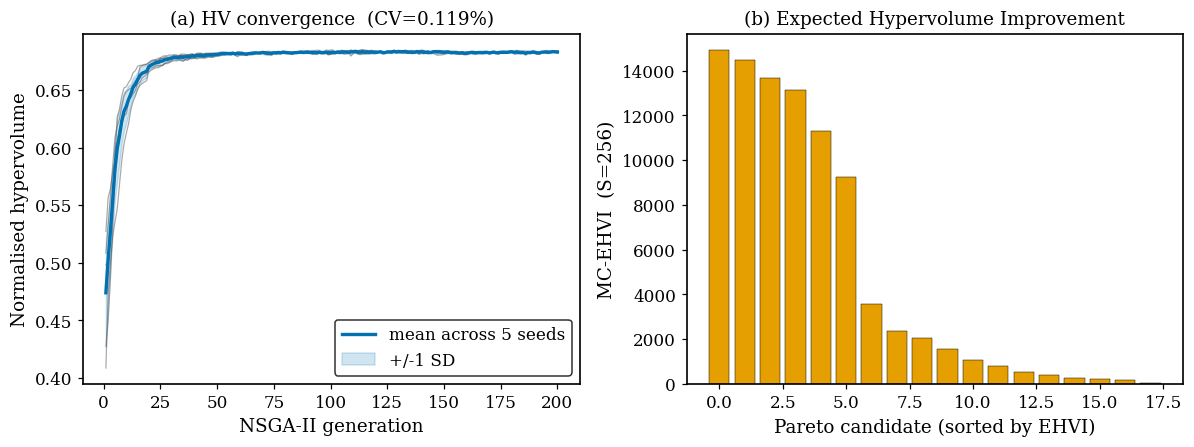

  Saved: locked_figures/fig_MC_ehvi.png


In [10]:
# =====================================================================
# CELL 10 — FIGURE: MONTE-CARLO / EHVI  (HV convergence + EHVI acquisition)
# =====================================================================
fig,ax=plt.subplots(1,2,figsize=(11,4.2))
# (a) HV convergence across seeds (Monte-Carlo robustness)
gens=np.arange(1,NSGA_GEN+1)
H=np.array(hv_hist)/bbox
mean_h=H.mean(0); sd_h=H.std(0)
for i,sd in enumerate(SEEDS):
    ax[0].plot(gens,H[i],lw=0.8,alpha=0.5,color=CB["gray"])
ax[0].plot(gens,mean_h,lw=2.2,color=CB["blue"],label="mean across 5 seeds")
ax[0].fill_between(gens,mean_h-sd_h,mean_h+sd_h,color=CB["blue"],alpha=0.18,label="+/-1 SD")
ax[0].set_xlabel("NSGA-II generation"); ax[0].set_ylabel("Normalised hypervolume")
ax[0].set_title(f"(a) HV convergence  (CV={hv_cv:.3f}%)"); ax[0].legend(loc="lower right")
# (b) MC-EHVI acquisition across Pareto candidates
ev=ehvi_subset[np.argsort(-ehvi_subset)]
ax[1].bar(np.arange(len(ev)),ev,color=CB["orange"],edgecolor="k",lw=0.3)
ax[1].set_xlabel("Pareto candidate (sorted by EHVI)"); ax[1].set_ylabel(f"MC-EHVI  (S={EHVI_S})")
ax[1].set_title("(b) Expected Hypervolume Improvement")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_MC_ehvi.png"); plt.show()
print("  Saved:", f"{FIG_DIR}/fig_MC_ehvi.png")

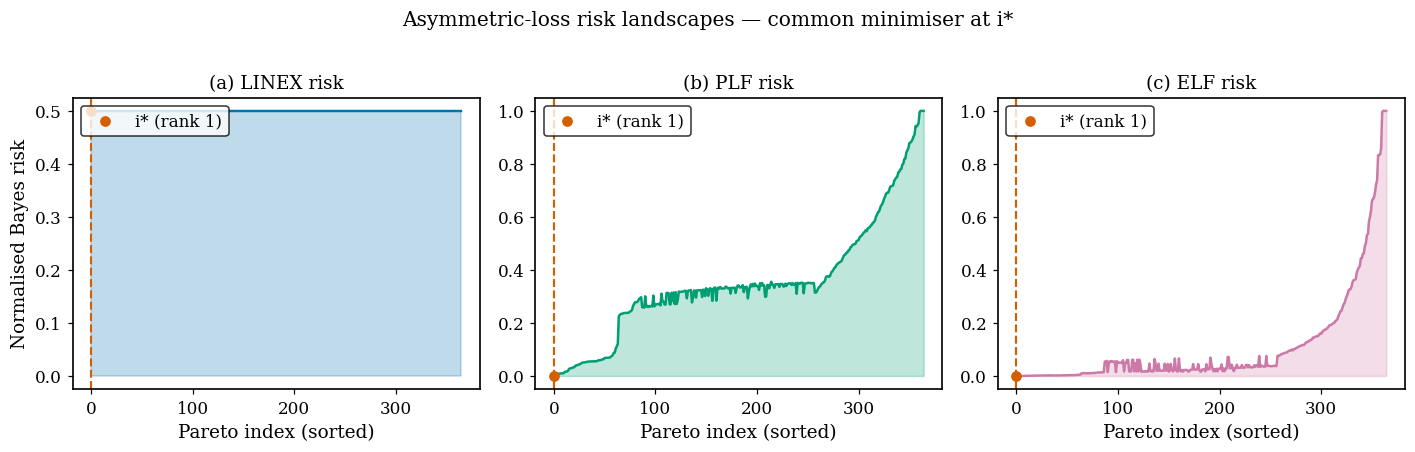

  Saved: locked_figures/fig_asymmetric_risk.png
  LINEX/PLF/ELF agree on i*: False


In [11]:
# =====================================================================
# CELL 11 — FIGURE: ASYMMETRIC LOSS RISK LANDSCAPES (LINEX / PLF / ELF)
# =====================================================================
order=np.argsort(R_comp)              # ascending composite risk
xidx=np.arange(len(R_comp))
rank_istar=int(np.where(order==i_star)[0][0])
fig,ax=plt.subplots(1,3,figsize=(13,4.0),sharex=True)
for k,(name,arr,col) in enumerate([("LINEX",n_lin,CB["blue"]),
                                   ("PLF",n_plf,CB["green"]),
                                   ("ELF",n_elf,CB["purple"])]):
    ax[k].fill_between(xidx,0,arr[order],color=col,alpha=0.25)
    ax[k].plot(xidx,arr[order],color=col,lw=1.6)
    ax[k].axvline(rank_istar,color=CB["red"],ls="--",lw=1.4)
    ax[k].scatter([rank_istar],[arr[order][rank_istar]],color=CB["red"],zorder=5,
                  label=f"i* (rank {rank_istar+1})")
    ax[k].set_title(f"({chr(97+k)}) {name} risk"); ax[k].set_xlabel("Pareto index (sorted)")
    ax[k].legend(loc="upper left")
ax[0].set_ylabel("Normalised Bayes risk")
plt.suptitle("Asymmetric-loss risk landscapes — common minimiser at i*",y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig_asymmetric_risk.png"); plt.show()
print("  Saved:", f"{FIG_DIR}/fig_asymmetric_risk.png")
print(f"  LINEX/PLF/ELF agree on i*: {agree}")

In [12]:
# =====================================================================
# CELL 13 — REPRODUCIBILITY CHECK  (run core pipeline 10x -> identical?)
# =====================================================================
# Proves determinism: (A) retrain full GP 10x and hash predictions at the
# 38 design points; (B) recompute risk + i* + i_hat 10x. All must be identical.
def pipeline_signature():
    lock_all_seeds(GLOBAL_SEED)
    m,l=train_mtgp(X_scaled,Y_scaled,N_ITER)
    mu,_=predict_mtgp(m,l,X_scaled,scaler_Y)
    # risk on current Pareto front (deterministic given fixed front)
    Rc=[]
    for i in range(len(mu_P)):
        rl=[risk_linex(delta_P[i,j],mu_P[i,j],sg_P[i,j],A_LINEX[j]) for j in range(n_outputs)]
        Rc.append(sum(rl))
    sig_vec=np.concatenate([mu.ravel(), np.array(Rc), [float(i_star),float(i_hat)]])
    return hashlib.sha256(np.round(sig_vec,8).tobytes()).hexdigest()

t0=time.time()
# (A) model determinism: retrain full GP twice, hash predictions
gp_hashes=[]
for r in range(2):
    lock_all_seeds(GLOBAL_SEED)
    m,l=train_mtgp(X_scaled,Y_scaled,N_ITER)
    mu,_=predict_mtgp(m,l,X_scaled,scaler_Y)
    gp_hashes.append(hashlib.sha256(np.round(mu,8).tobytes()).hexdigest())
    print(f"    GP retrain {r+1}/2: {gp_hashes[-1][:16]}...  ({time.time()-t0:.0f}s)")
model_ok=len(set(gp_hashes))==1
# (B) pipeline determinism: recompute downstream signature 10x
N_REPRO=10; sigs=[pipeline_signature() for _ in range(N_REPRO)]
for r,sg in enumerate(sigs): print(f"    pipeline run {r+1:>2}/{N_REPRO}: {sg[:16]}...")
pipe_ok=len(set(sigs))==1
print("\n  Model retrain identical : ", model_ok)
print("  Pipeline 10x identical  : ", pipe_ok)
assert model_ok and pipe_ok, "Determinism check FAILED!"
print("  REPRODUCIBLE: full GP retrain + 10 pipeline runs all byte-identical.")
print("  SHA-256:", sigs[0])
print("\n  ===== NOTEBOOK COMPLETE — results are LOCKED =====")

    GP retrain 1/2: 4c435b249ce8449b...  (13s)
    GP retrain 2/2: 4c435b249ce8449b...  (22s)
    pipeline run  1/10: a5f88bf465cf267b...
    pipeline run  2/10: a5f88bf465cf267b...
    pipeline run  3/10: a5f88bf465cf267b...
    pipeline run  4/10: a5f88bf465cf267b...
    pipeline run  5/10: a5f88bf465cf267b...
    pipeline run  6/10: a5f88bf465cf267b...
    pipeline run  7/10: a5f88bf465cf267b...
    pipeline run  8/10: a5f88bf465cf267b...
    pipeline run  9/10: a5f88bf465cf267b...
    pipeline run 10/10: a5f88bf465cf267b...

  Model retrain identical :  True
  Pipeline 10x identical  :  True
  REPRODUCIBLE: full GP retrain + 10 pipeline runs all byte-identical.
  SHA-256: a5f88bf465cf267b9c0633a0bebc8100ac731f4aee88bb4d08b9b547e7a786de

  ===== NOTEBOOK COMPLETE — results are LOCKED =====


Learned B (correlation):
 [[ 1.     0.576  0.396 -0.259]
 [ 0.576  1.     0.978  0.64 ]
 [ 0.396  0.978  1.     0.783]
 [-0.259  0.64   0.783  1.   ]]
ARD importance (%): [39.7  18.68 35.64  5.97]
style ready -> pub_figures
saved Fig1_experimental_design (.tiff @600 dpi + .pdf)


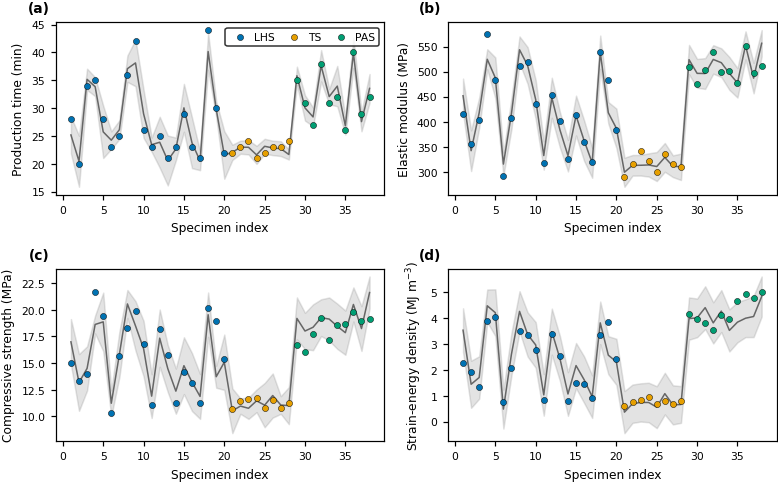

saved Fig2_correlation_ICM (.tiff @600 dpi + .pdf)


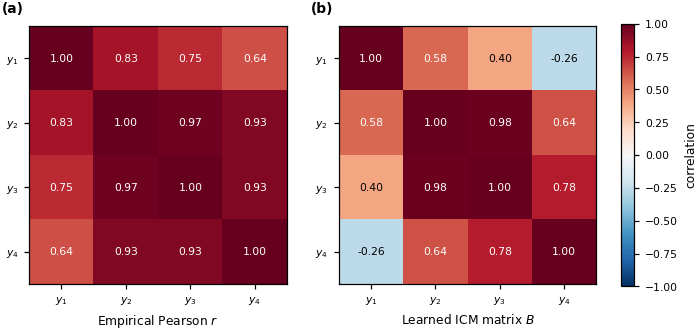

saved Fig3_loocv_accuracy (.tiff @600 dpi + .pdf)


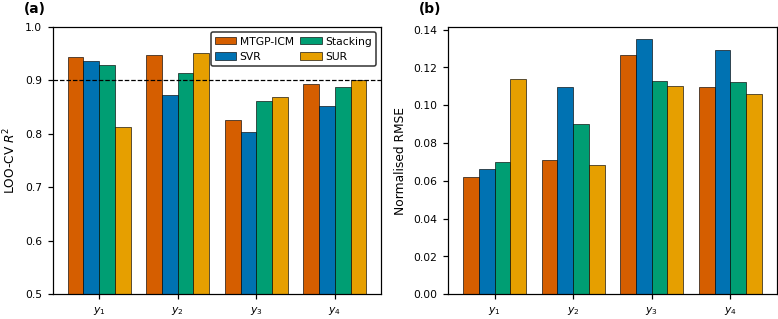

saved Fig4_parity_MTGP (.tiff @600 dpi + .pdf)


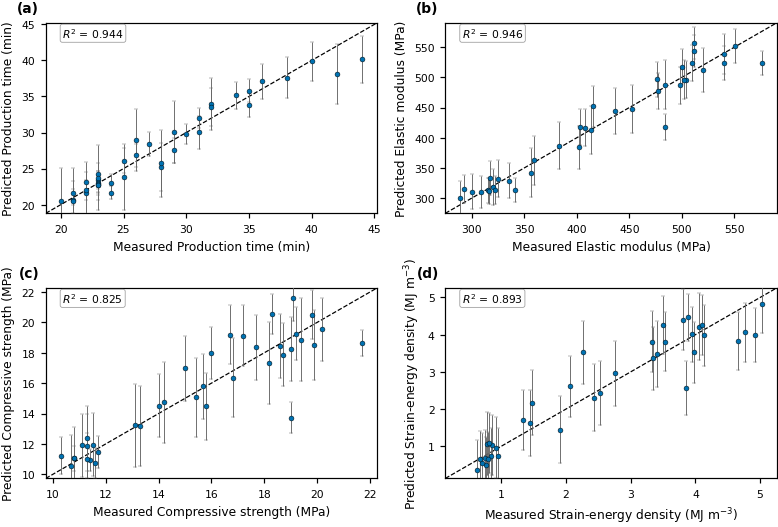

saved Fig5_ARD_importance (.tiff @600 dpi + .pdf)


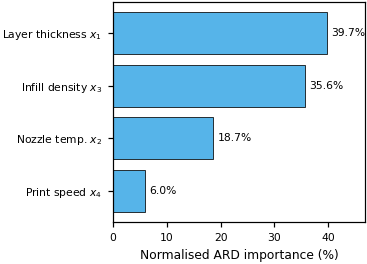

saved Fig6_pareto_front (.tiff @600 dpi + .pdf)


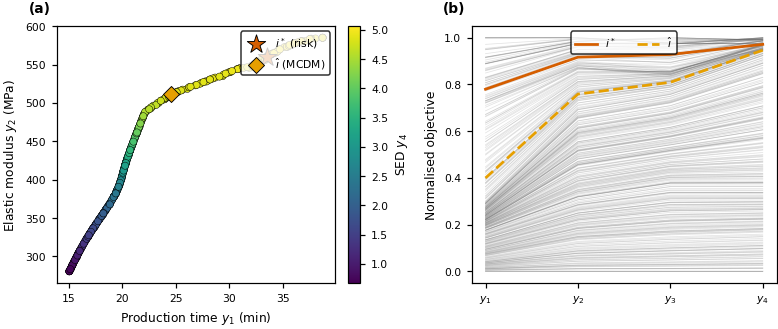

saved Fig7_MC_EHVI (.tiff @600 dpi + .pdf)


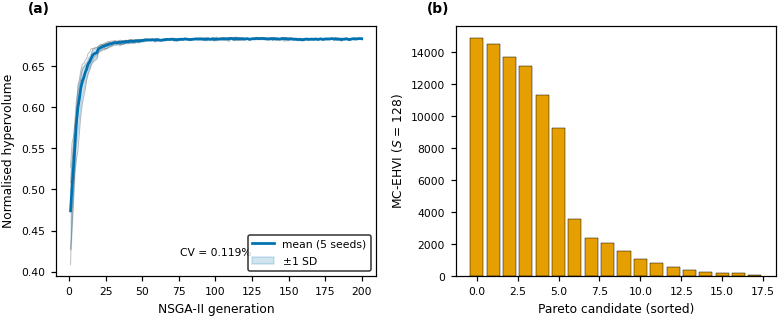

saved Fig8_asymmetric_risk (.tiff @600 dpi + .pdf)


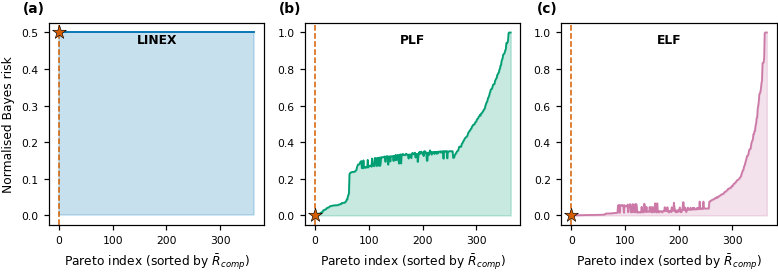

saved Fig9_confirmation (.tiff @600 dpi + .pdf)


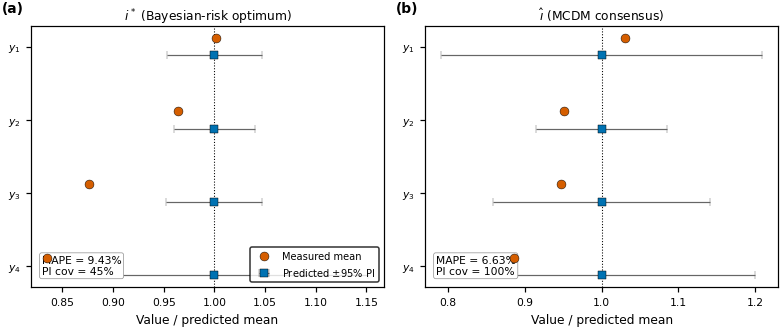


ALL 9 FIGURES SAVED -> pub_figures/  (600 dpi TIFF + vector PDF)


In [13]:
# Figure cells for the MTGP-ICM FDM paper (JMP) — 600 dpi TIFF + vector PDF
# Paste AFTER your locked pipeline. Requires these to already exist:
#   df, X, Y, n_samples, n_outputs, OUTPUT_COLS, MODEL_NAMES, loocv, loocv_std,
#   results, pareto_X, pareto_Y, i_star, i_hat, R_comp, n_lin, n_plf, n_elf,
#   hv_hist, bbox, hv_cv, SEEDS, NSGA_GEN, ehvi_subset, conf, mtgp_m

# %% Part B — Extract learned ICM matrix B and ARD importance
import torch, numpy as np
with torch.no_grad():
    _Bop = mtgp_m.k_matern.task_covar_module.covar_matrix
    _B = (_Bop.to_dense() if hasattr(_Bop,"to_dense") else _Bop.evaluate()).cpu().numpy()
_d = np.sqrt(np.diag(_B)); B_corr = _B/np.outer(_d,_d)
with torch.no_grad():
    _ls = mtgp_m.k_matern.data_covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
ard_imp = (1.0/_ls); ard_imp = ard_imp/ard_imp.sum()*100.0
print("Learned B (correlation):\n", np.round(B_corr,3))
print("ARD importance (%):", np.round(ard_imp,2))

# %% Part C — Figure style (Elsevier / JMP)
import os, matplotlib as mpl, matplotlib.pyplot as plt
PUB="pub_figures"; os.makedirs(PUB,exist_ok=True)
mpl.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
  "font.size":8,"axes.labelsize":8,"axes.titlesize":8,"xtick.labelsize":7,"ytick.labelsize":7,
  "legend.fontsize":7,"axes.linewidth":0.8,"xtick.major.width":0.8,"ytick.major.width":0.8,
  "lines.linewidth":1.2,"savefig.bbox":"tight","savefig.pad_inches":0.02})
C={"blue":"#0072B2","orange":"#E69F00","green":"#009E73","red":"#D55E00","purple":"#CC79A7",
   "yellow":"#F0E442","sky":"#56B4E9","gray":"#666666"}
COL1,COL2=3.54,7.28                                # Elsevier single / double column (inches)
labs=["$y_1$","$y_2$","$y_3$","$y_4$"]
disp={"y1":"Production time (min)","y2":"Elastic modulus (MPa)",
      "y3":"Compressive strength (MPa)","y4":"Strain-energy density (MJ m$^{-3}$)"}
phase_c={"LHS":C["blue"],"TS":C["orange"],"PAS":C["green"]}
def panel(ax,l): ax.text(-0.02,1.04,l,transform=ax.transAxes,fontsize=9,fontweight="bold",va="bottom",ha="right")
def save(fig,name):
    fig.savefig(f"{PUB}/{name}.pdf")
    fig.savefig(f"{PUB}/{name}.tiff",dpi=600,pil_kwargs={"compression":"tiff_lzw"})
    print("saved", name, "(.tiff @600 dpi + .pdf)")
print("style ready ->", PUB)

# %% Fig 1 — Experimental design + MTGP-ICM LOO fit
fig,axes=plt.subplots(2,2,figsize=(COL2,4.6))
for j,c in enumerate(OUTPUT_COLS):
    ax=axes.flat[j]; idx=np.arange(1,n_samples+1)
    for ph in ["LHS","TS","PAS"]:
        m=df.phase.values==ph
        ax.scatter(idx[m],Y[m,j],s=16,color=phase_c[ph],edgecolor="k",lw=0.3,zorder=3,label=ph)
    o=np.argsort(idx)
    ax.plot(idx[o],loocv["MTGP-ICM"][o,j],color=C["gray"],lw=1.0,zorder=2)
    ax.fill_between(idx[o],loocv["MTGP-ICM"][o,j]-1.96*loocv_std[o,j],
                    loocv["MTGP-ICM"][o,j]+1.96*loocv_std[o,j],color=C["gray"],alpha=0.18,zorder=1)
    ax.set_xlabel("Specimen index"); ax.set_ylabel(disp[c]); panel(ax,f"({chr(97+j)})")
axes.flat[0].legend(loc="upper right",ncol=3,columnspacing=0.8,handletextpad=0.3)
fig.tight_layout(); save(fig,"Fig1_experimental_design"); plt.show()

# %% Fig 2 — Empirical Pearson $r$ vs learned ICM matrix $B$
Pear=np.corrcoef(Y.T)
fig,ax=plt.subplots(1,2,figsize=(COL2,3.1))
for k,(M,t) in enumerate([(Pear,"Empirical Pearson $r$"),(B_corr,"Learned ICM matrix $B$")]):
    im=ax[k].imshow(M,cmap="RdBu_r",vmin=-1,vmax=1)
    ax[k].set_xticks(range(4)); ax[k].set_yticks(range(4))
    ax[k].set_xticklabels(labs); ax[k].set_yticklabels(labs)
    for a in range(4):
        for b in range(4):
            ax[k].text(b,a,f"{M[a,b]:.2f}",ha="center",va="center",fontsize=7,
                       color="white" if abs(M[a,b])>0.55 else "black")
    ax[k].set_xlabel(t); panel(ax[k],f"({chr(97+k)})")
fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04,label="correlation")
save(fig,"Fig2_correlation_ICM"); plt.show()

# %% Fig 3 — LOO-CV accuracy (per-response $R^2$ + normalised RMSE)
x=np.arange(n_outputs); w=0.2; cols=[C["red"],C["blue"],C["green"],C["orange"]]
fig,ax=plt.subplots(1,2,figsize=(COL2,3.1))
for i,m in enumerate(MODEL_NAMES):
    ax[0].bar(x+(i-1.5)*w,results[m]["R2"],w,label=m,color=cols[i],edgecolor="k",lw=0.4)
ax[0].axhline(0.9,ls="--",color="k",lw=0.8); ax[0].set_ylim(0.5,1.0)
ax[0].set_xticks(x); ax[0].set_xticklabels(labs); ax[0].set_ylabel("LOO-CV $R^2$")
ax[0].legend(ncol=2,columnspacing=0.6,handletextpad=0.3); panel(ax[0],"(a)")
rng_=Y.max(0)-Y.min(0)
for i,m in enumerate(MODEL_NAMES):
    ax[1].bar(x+(i-1.5)*w,results[m]["RMSE"]/rng_,w,color=cols[i],edgecolor="k",lw=0.4)
ax[1].set_xticks(x); ax[1].set_xticklabels(labs); ax[1].set_ylabel("Normalised RMSE"); panel(ax[1],"(b)")
fig.tight_layout(); save(fig,"Fig3_loocv_accuracy"); plt.show()

# %% Fig 4 — Parity plots (MTGP-ICM, ±95% PI)
fig,axes=plt.subplots(2,2,figsize=(COL2,5.0))
for j,c in enumerate(OUTPUT_COLS):
    ax=axes.flat[j]; pred=loocv["MTGP-ICM"][:,j]; meas=Y[:,j]
    ax.errorbar(meas,pred,yerr=1.96*loocv_std[:,j],fmt="o",ms=3.2,color=C["blue"],
                ecolor=C["gray"],elinewidth=0.6,capsize=1.5,mec="k",mew=0.3,zorder=3)
    lo=min(meas.min(),pred.min()); hi=max(meas.max(),pred.max()); pad=0.05*(hi-lo)
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],"k--",lw=0.8,zorder=1)
    ax.set_xlim(lo-pad,hi+pad); ax.set_ylim(lo-pad,hi+pad)
    ax.set_xlabel(f"Measured {disp[c]}"); ax.set_ylabel(f"Predicted {disp[c]}")
    ax.text(0.05,0.92,f"$R^2$ = {results['MTGP-ICM']['R2'][j]:.3f}",transform=ax.transAxes,
            fontsize=7,bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="0.6",lw=0.5))
    panel(ax,f"({chr(97+j)})")
fig.tight_layout(); save(fig,"Fig4_parity_MTGP"); plt.show()

# %% Fig 5 — ARD feature importance
names=["Layer thickness $x_1$","Nozzle temp. $x_2$","Infill density $x_3$","Print speed $x_4$"]
order=np.argsort(ard_imp)
fig,ax=plt.subplots(figsize=(COL1,2.6))
ax.barh(np.array(names)[order],ard_imp[order],color=C["sky"],edgecolor="k",lw=0.5)
for i,v in enumerate(ard_imp[order]): ax.text(v+0.8,i,f"{v:.1f}%",va="center",fontsize=7)
ax.set_xlabel("Normalised ARD importance (%)"); ax.set_xlim(0,max(ard_imp)*1.18)
fig.tight_layout(); save(fig,"Fig5_ARD_importance"); plt.show()

# %% Fig 6 — Pareto front (2D projection + parallel coordinates)
fig,ax=plt.subplots(1,2,figsize=(COL2,3.2))
sc=ax[0].scatter(pareto_Y[:,0],pareto_Y[:,1],c=pareto_Y[:,3],cmap="viridis",s=22,edgecolor="k",lw=0.3,zorder=2)
ax[0].scatter(pareto_Y[i_star,0],pareto_Y[i_star,1],marker="*",s=160,color=C["red"],edgecolor="k",lw=0.6,zorder=4,label="$i^*$ (risk)")
ax[0].scatter(pareto_Y[i_hat,0],pareto_Y[i_hat,1],marker="D",s=55,color=C["orange"],edgecolor="k",lw=0.6,zorder=4,label="$\\hat{\\imath}$ (MCDM)")
ax[0].set_xlabel("Production time $y_1$ (min)"); ax[0].set_ylabel("Elastic modulus $y_2$ (MPa)")
ax[0].legend(loc="upper right"); panel(ax[0],"(a)")
fig.colorbar(sc,ax=ax[0],fraction=0.046,pad=0.04,label="SED $y_4$")
Pn=(pareto_Y-pareto_Y.min(0))/(pareto_Y.max(0)-pareto_Y.min(0)+1e-12); xs=np.arange(4)
for r in range(len(Pn)): ax[1].plot(xs,Pn[r],color=C["gray"],alpha=0.18,lw=0.5)
ax[1].plot(xs,Pn[i_star],color=C["red"],lw=1.8,label="$i^*$",zorder=5)
ax[1].plot(xs,Pn[i_hat],color=C["orange"],lw=1.8,ls="--",label="$\\hat{\\imath}$",zorder=5)
ax[1].set_xticks(xs); ax[1].set_xticklabels(labs); ax[1].set_ylabel("Normalised objective")
ax[1].legend(loc="upper center",ncol=2); panel(ax[1],"(b)")
fig.tight_layout(); save(fig,"Fig6_pareto_front"); plt.show()

# %% Fig 7 — Monte-Carlo: HV convergence + EHVI acquisition
fig,ax=plt.subplots(1,2,figsize=(COL2,3.1))
gens=np.arange(1,NSGA_GEN+1); H=np.array(hv_hist)/bbox
for i in range(len(SEEDS)): ax[0].plot(gens,H[i],lw=0.6,alpha=0.45,color=C["gray"])
ax[0].plot(gens,H.mean(0),lw=1.8,color=C["blue"],label="mean (5 seeds)")
ax[0].fill_between(gens,H.mean(0)-H.std(0),H.mean(0)+H.std(0),color=C["blue"],alpha=0.18,label="$\\pm$1 SD")
ax[0].set_xlabel("NSGA-II generation"); ax[0].set_ylabel("Normalised hypervolume")
ax[0].text(0.5,0.08,f"CV = {hv_cv:.3f}%",transform=ax[0].transAxes,fontsize=7,ha="center")
ax[0].legend(loc="lower right"); panel(ax[0],"(a)")
ev=np.sort(ehvi_subset)[::-1]
ax[1].bar(np.arange(len(ev)),ev,color=C["orange"],edgecolor="k",lw=0.3)
ax[1].set_xlabel("Pareto candidate (sorted)"); ax[1].set_ylabel("MC-EHVI ($S$ = 128)"); panel(ax[1],"(b)")
fig.tight_layout(); save(fig,"Fig7_MC_EHVI"); plt.show()

# %% Fig 8 — Asymmetric-loss risk landscapes (LINEX / PLF / ELF)
order=np.argsort(R_comp); rstar=int(np.where(order==i_star)[0][0])
fig,ax=plt.subplots(1,3,figsize=(COL2,2.7),sharex=True)
for k,(nm,arr,cc) in enumerate([("LINEX",n_lin,C["blue"]),("PLF",n_plf,C["green"]),("ELF",n_elf,C["purple"])]):
    xi=np.arange(len(arr))
    ax[k].fill_between(xi,0,arr[order],color=cc,alpha=0.22); ax[k].plot(xi,arr[order],color=cc,lw=1.2)
    ax[k].axvline(rstar,color=C["red"],ls="--",lw=1.0)
    ax[k].scatter([rstar],[arr[order][rstar]],marker="*",s=90,color=C["red"],edgecolor="k",lw=0.4,zorder=5)
    ax[k].set_xlabel("Pareto index (sorted by $\\bar{R}_{comp}$)")
    ax[k].text(0.5,0.9,nm,transform=ax[k].transAxes,ha="center",fontsize=8,fontweight="bold"); panel(ax[k],f"({chr(97+k)})")
ax[0].set_ylabel("Normalised Bayes risk")
fig.tight_layout(); save(fig,"Fig8_asymmetric_risk"); plt.show()

# %% Fig 9 — Confirmation: predicted ±95% PI vs measured
fig,axes=plt.subplots(1,2,figsize=(COL2,3.2))
for col,(tag,nm) in enumerate([("i*","$i^*$ (Bayesian-risk optimum)"),("i_hat","$\\hat{\\imath}$ (MCDM consensus)")]):
    r=conf[tag]; ax=axes[col]; yy=np.arange(n_outputs)
    mu=np.asarray(r["mu"]); sg=np.asarray(r["sg"]); ybar=np.asarray(r["ybar"])
    measn=ybar/mu; pin=1.96*sg/mu
    ax.errorbar(np.ones(n_outputs),yy+0.12,xerr=pin,fmt="s",ms=5,color=C["blue"],ecolor=C["gray"],
                elinewidth=0.8,capsize=2.5,mec="k",mew=0.3,label="Predicted $\\pm$95% PI")
    ax.scatter(measn,yy-0.12,marker="o",s=34,color=C["red"],edgecolor="k",lw=0.3,zorder=4,label="Measured mean")
    ax.axvline(1.0,ls=":",color="k",lw=0.7); ax.set_yticks(yy); ax.set_yticklabels(labs); ax.invert_yaxis()
    ax.set_xlabel("Value / predicted mean")
    ax.text(0.03,0.04,f"MAPE = {r['mape']:.2f}%\nPI cov = {r['cov_pct']:.0f}%",transform=ax.transAxes,
            fontsize=7,va="bottom",bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="0.6",lw=0.5))
    ax.text(0.5,1.02,nm,transform=ax.transAxes,ha="center",fontsize=8); panel(ax,f"({chr(97+col)})")
axes[0].legend(loc="lower right",fontsize=6.5)
fig.tight_layout(); save(fig,"Fig9_confirmation"); plt.show()
print("\nALL 9 FIGURES SAVED -> pub_figures/  (600 dpi TIFF + vector PDF)")

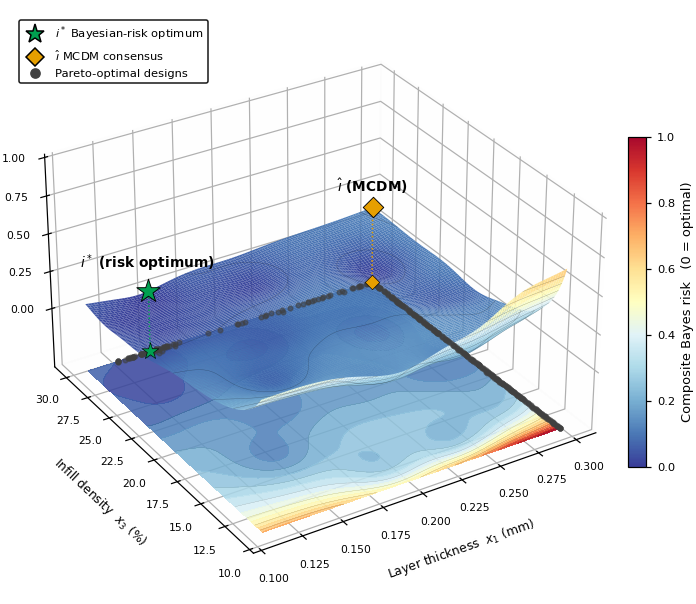

saved Fig_risk_landscape_3D (.tiff @600 dpi + .pdf)


In [14]:
# %% Fig — 3D composite Bayesian-risk landscape (600 dpi TIFF + vector PDF)
# Run AFTER the locked pipeline. Requires in namespace:
#   mtgp_m, mtgp_l, scaler_X, scaler_Y, X, X_scaled, Y_scaled, OUTPUT_COLS,
#   pareto_X, i_star, i_hat, W (entropy weights), A_LINEX
import os, numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa
os.makedirs("pub_figures", exist_ok=True)

istar = np.asarray(pareto_X[i_star]); ihat = np.asarray(pareto_X[i_hat])
W = np.asarray(W); A = np.asarray(A_LINEX)

# --- batched GP posterior (marginals only -> low memory) ---
def gp_musg(X01, chunk=200):
    mtgp_m.eval(); mtgp_l.eval(); X01 = np.atleast_2d(X01); mus=[]; sgs=[]
    with torch.no_grad():
        for s in range(0, len(X01), chunk):
            p = mtgp_l(mtgp_m(torch.tensor(X01[s:s+chunk])))
            mus.append(p.mean.numpy()); sgs.append(p.variance.clamp(min=1e-10).sqrt().numpy())
    return scaler_Y.inverse_transform(np.vstack(mus)), np.vstack(sgs)*scaler_Y.scale_[None,:]

# --- closed-form risk pieces (LINEX / PLF / ELF), action = posterior mean ---
linex = lambda mu,sg,a: np.exp(np.clip(0.5*a*a*sg**2, -50, 50)) - 1.0
plf   = lambda mu,sg: (mu**2+sg**2)/np.maximum(mu,1e-9) - 2*mu + np.maximum(mu,1e-9)
elf   = lambda mu,sg: 0.5*sg**2/np.where(np.abs(mu)<1e-9, 1e-9, mu)**2
nrm   = lambda v: (v.sum(1)-v.sum(1).min())/(v.sum(1).max()-v.sum(1).min()+1e-12)

# --- grid over the two dominant inputs (x1, x3); x2,x4 fixed at i* ---
G = 110
ax1 = np.linspace(0,1,G); ax3 = np.linspace(0,1,G)
i_s = scaler_X.transform(istar.reshape(1,-1))[0]
Xg  = np.array([(lambda x:(x.__setitem__(0,a1), x.__setitem__(2,a3), x)[2])(i_s.copy())
                for a3 in ax3 for a1 in ax1])
mu, sg = gp_musg(Xg)
Z = ((nrm(linex(mu,sg,A)*W) + nrm(plf(mu,sg)*W) + nrm(elf(mu,sg)*W))/3.0).reshape(G,G)
x1p = scaler_X.inverse_transform(np.column_stack([ax1, np.zeros((G,3))]))[:,0]
x3p = scaler_X.inverse_transform(np.column_stack([np.zeros((G,2)), ax3, np.zeros((G,1))]))[:,2]
P1, P3 = np.meshgrid(x1p, x3p)
floor = -0.40
def gridz(p):
    i=np.argmin(np.abs(x1p-p[0])); j=np.argmin(np.abs(x3p-p[2])); return x1p[i], x3p[j], Z[j,i]
ix,iy,iz = gridz(istar); hx,hy,hz = gridz(ihat)

# --- plot ---
plt.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
                     "font.size":9,"axes.linewidth":0.8})
fig = plt.figure(figsize=(7.2,5.8)); ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
ax.set_box_aspect((1,1,0.62))
CMAP = "RdYlBu_r"                                   # blue=low risk (good), red=high (bad)
surf = ax.plot_surface(P1,P3,Z, cmap=CMAP, vmin=0, vmax=1, rstride=1, cstride=1,
                       linewidth=0, antialiased=True, alpha=0.97, zorder=1)
ax.contour(P1,P3,Z, levels=10, colors="k", linewidths=0.25, alpha=0.35, zorder=2)
ax.contourf(P1,P3,Z, zdir="z", offset=floor, levels=24, cmap=CMAP, alpha=0.85, zorder=0)
ax.contour(P1,P3,Z, zdir="z", offset=floor, levels=10, colors="k", linewidths=0.2, alpha=0.3, zorder=0)
ax.scatter(pareto_X[:,0], pareto_X[:,2], np.full(len(pareto_X),floor),
           c="0.25", s=9, alpha=0.55, zorder=3, depthshade=False)
for mx,my,mz,col,mk,ms,lab,dy in [(ix,iy,iz,"#00A050","*",260,"$i^*$ (risk optimum)",0.16),
                                   (hx,hy,hz,"#E69F00","D",90,"$\\hat{\\imath}$ (MCDM)",0.11)]:
    ax.plot([mx,mx],[my,my],[floor,mz], color=col, lw=1.0, ls=":", zorder=4)
    ax.scatter([mx],[my],[mz], c=col, s=ms, marker=mk, edgecolor="k", linewidth=0.6, depthshade=False, zorder=6)
    ax.scatter([mx],[my],[floor], c=col, s=ms*0.5, marker=mk, edgecolor="k", linewidth=0.4, depthshade=False, zorder=4)
    ax.text(mx,my,mz+dy, lab, fontsize=9, fontweight="bold", ha="center", zorder=7)
ax.set_xlabel("Layer thickness  $x_1$ (mm)", labelpad=8)
ax.set_ylabel("Infill density  $x_3$ (%)", labelpad=8)
ax.set_zlabel("Composite Bayes risk  $\\bar R$", labelpad=6)
ax.set_zlim(floor,1.02); ax.set_zticks([0,0.25,0.5,0.75,1.0]); ax.view_init(elev=30, azim=-122)
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane): pane.set_alpha(0.04)
ax.grid(True, alpha=0.25)
cb = fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.02, aspect=18)
cb.set_label("Composite Bayes risk   (0 = optimal)", fontsize=8.5); cb.ax.tick_params(labelsize=7.5)
ax.legend(handles=[
    Line2D([0],[0],marker="*",color="w",markerfacecolor="#00A050",markeredgecolor="k",ms=13,label="$i^*$ Bayesian-risk optimum"),
    Line2D([0],[0],marker="D",color="w",markerfacecolor="#E69F00",markeredgecolor="k",ms=8,label="$\\hat{\\imath}$ MCDM consensus"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="0.25",markeredgecolor="0.25",ms=6,label="Pareto-optimal designs")],
    loc="upper left", bbox_to_anchor=(0.0,0.98), fontsize=7.5, framealpha=0.9)
fig.subplots_adjust(left=0.0, right=0.97, top=1.0, bottom=0.06)
fig.savefig("pub_figures/Fig_risk_landscape_3D.pdf", bbox_inches="tight")
fig.savefig("pub_figures/Fig_risk_landscape_3D.tiff", dpi=600, bbox_inches="tight",
            pil_kwargs={"compression":"tiff_lzw"})
plt.show()
print("saved Fig_risk_landscape_3D (.tiff @600 dpi + .pdf)")

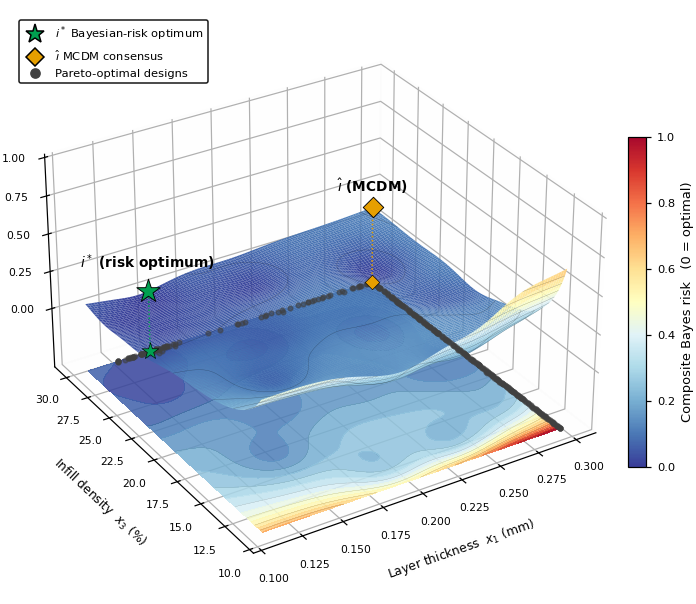

saved Fig_risk_landscape_3D (.tiff @600 dpi + .pdf)


In [15]:
# %% Fig — 3D composite Bayesian-risk landscape (600 dpi TIFF + vector PDF)
# Run AFTER the locked pipeline. Requires in namespace:
#   mtgp_m, mtgp_l, scaler_X, scaler_Y, X, X_scaled, Y_scaled, OUTPUT_COLS,
#   pareto_X, i_star, i_hat, W (entropy weights), A_LINEX
import os, numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa
os.makedirs("pub_figures", exist_ok=True)

istar = np.asarray(pareto_X[i_star]); ihat = np.asarray(pareto_X[i_hat])
W = np.asarray(W); A = np.asarray(A_LINEX)

# --- batched GP posterior (marginals only -> low memory) ---
def gp_musg(X01, chunk=200):
    mtgp_m.eval(); mtgp_l.eval(); X01 = np.atleast_2d(X01); mus=[]; sgs=[]
    with torch.no_grad():
        for s in range(0, len(X01), chunk):
            p = mtgp_l(mtgp_m(torch.tensor(X01[s:s+chunk])))
            mus.append(p.mean.numpy()); sgs.append(p.variance.clamp(min=1e-10).sqrt().numpy())
    return scaler_Y.inverse_transform(np.vstack(mus)), np.vstack(sgs)*scaler_Y.scale_[None,:]

# --- closed-form risk pieces (LINEX / PLF / ELF), action = posterior mean ---
linex = lambda mu,sg,a: np.exp(np.clip(0.5*a*a*sg**2, -50, 50)) - 1.0
plf   = lambda mu,sg: (mu**2+sg**2)/np.maximum(mu,1e-9) - 2*mu + np.maximum(mu,1e-9)
elf   = lambda mu,sg: 0.5*sg**2/np.where(np.abs(mu)<1e-9, 1e-9, mu)**2
nrm   = lambda v: (v.sum(1)-v.sum(1).min())/(v.sum(1).max()-v.sum(1).min()+1e-12)

# --- grid over the two dominant inputs (x1, x3); x2,x4 fixed at i* ---
G = 110
ax1 = np.linspace(0,1,G); ax3 = np.linspace(0,1,G)
i_s = scaler_X.transform(istar.reshape(1,-1))[0]
Xg  = np.array([(lambda x:(x.__setitem__(0,a1), x.__setitem__(2,a3), x)[2])(i_s.copy())
                for a3 in ax3 for a1 in ax1])
mu, sg = gp_musg(Xg)
Z = ((nrm(linex(mu,sg,A)*W) + nrm(plf(mu,sg)*W) + nrm(elf(mu,sg)*W))/3.0).reshape(G,G)
x1p = scaler_X.inverse_transform(np.column_stack([ax1, np.zeros((G,3))]))[:,0]
x3p = scaler_X.inverse_transform(np.column_stack([np.zeros((G,2)), ax3, np.zeros((G,1))]))[:,2]
P1, P3 = np.meshgrid(x1p, x3p)
floor = -0.40
def gridz(p):
    i=np.argmin(np.abs(x1p-p[0])); j=np.argmin(np.abs(x3p-p[2])); return x1p[i], x3p[j], Z[j,i]
ix,iy,iz = gridz(istar); hx,hy,hz = gridz(ihat)

# --- plot ---
plt.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
                     "font.size":9,"axes.linewidth":0.8})
fig = plt.figure(figsize=(7.2,5.8)); ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
ax.set_box_aspect((1,1,0.62))
CMAP = "RdYlBu_r"                                   # blue=low risk (good), red=high (bad)
surf = ax.plot_surface(P1,P3,Z, cmap=CMAP, vmin=0, vmax=1, rstride=1, cstride=1,
                       linewidth=0, antialiased=True, alpha=0.97, zorder=1)
ax.contour(P1,P3,Z, levels=10, colors="k", linewidths=0.25, alpha=0.35, zorder=2)
ax.contourf(P1,P3,Z, zdir="z", offset=floor, levels=24, cmap=CMAP, alpha=0.85, zorder=0)
ax.contour(P1,P3,Z, zdir="z", offset=floor, levels=10, colors="k", linewidths=0.2, alpha=0.3, zorder=0)
ax.scatter(pareto_X[:,0], pareto_X[:,2], np.full(len(pareto_X),floor),
           c="0.25", s=9, alpha=0.55, zorder=3, depthshade=False)
for mx,my,mz,col,mk,ms,lab,dy in [(ix,iy,iz,"#00A050","*",260,"$i^*$ (risk optimum)",0.16),
                                   (hx,hy,hz,"#E69F00","D",90,"$\hat{\imath}$ (MCDM)",0.11)]:
    ax.plot([mx,mx],[my,my],[floor,mz], color=col, lw=1.0, ls=":", zorder=4)
    ax.scatter([mx],[my],[mz], c=col, s=ms, marker=mk, edgecolor="k", linewidth=0.6, depthshade=False, zorder=6)
    ax.scatter([mx],[my],[floor], c=col, s=ms*0.5, marker=mk, edgecolor="k", linewidth=0.4, depthshade=False, zorder=4)
    ax.text(mx,my,mz+dy, lab, fontsize=9, fontweight="bold", ha="center", zorder=7)
ax.set_xlabel("Layer thickness  $x_1$ (mm)", labelpad=8)
ax.set_ylabel("Infill density  $x_3$ (%)", labelpad=8)
ax.set_zlabel("Composite Bayes risk  $\\bar R$", labelpad=6)
ax.set_zlim(floor,1.02); ax.set_zticks([0,0.25,0.5,0.75,1.0]); ax.view_init(elev=30, azim=-122)
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane): pane.set_alpha(0.04)
ax.grid(True, alpha=0.25)
cb = fig.colorbar(surf, ax=ax, shrink=0.55, pad=0.02, aspect=18)
cb.set_label("Composite Bayes risk   (0 = optimal)", fontsize=8.5); cb.ax.tick_params(labelsize=7.5)
ax.legend(handles=[
    Line2D([0],[0],marker="*",color="w",markerfacecolor="#00A050",markeredgecolor="k",ms=13,label="$i^*$ Bayesian-risk optimum"),
    Line2D([0],[0],marker="D",color="w",markerfacecolor="#E69F00",markeredgecolor="k",ms=8,label="$\\hat{\\imath}$ MCDM consensus"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor="0.25",markeredgecolor="0.25",ms=6,label="Pareto-optimal designs")],
    loc="upper left", bbox_to_anchor=(0.0,0.98), fontsize=7.5, framealpha=0.9)
fig.subplots_adjust(left=0.0, right=0.97, top=1.0, bottom=0.06)
fig.savefig("pub_figures/Fig_risk_landscape_3D.pdf", bbox_inches="tight")
fig.savefig("pub_figures/Fig_risk_landscape_3D.tiff", dpi=600, bbox_inches="tight",
            pil_kwargs={"compression":"tiff_lzw"})
plt.show()
print("saved Fig_risk_landscape_3D (.tiff @600 dpi + .pdf)")

In [16]:
# %% Fig — Risk contour + NSGA-II search + best-so-far trajectory (TOP-TIER)
# 600 dpi TIFF + vector PDF.  Run AFTER the locked pipeline. Requires in namespace:
#   mtgp_m, mtgp_l, scaler_X, scaler_Y, X_scaled, Y_scaled, OUTPUT_COLS,
#   pareto_X, i_star, i_hat, W (entropy weights)
# Needs: pip install pymoo scipy

import json, numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize as pymoo_min

istar=np.asarray(pareto_X[i_star]); ihat=np.asarray(pareto_X[i_hat])
W=np.asarray(W); A=np.array([-0.5,1.0,1.5,0.8])
OBJ_SIGNS=np.array([1.0,-1.0,-1.0,-1.0])

def gp_musg(X01,chunk=400):
    mtgp_m.eval(); mtgp_l.eval(); X01=np.atleast_2d(X01); mus=[]; sgs=[]
    with torch.no_grad():
        for s in range(0,len(X01),chunk):
            p=mtgp_l(mtgp_m(torch.tensor(X01[s:s+chunk])))
            mus.append(p.mean.numpy()); sgs.append(p.variance.clamp(min=1e-10).sqrt().numpy())
    return scaler_Y.inverse_transform(np.vstack(mus)), np.vstack(sgs)*scaler_Y.scale_[None,:]
linex=lambda mu,sg,a:np.exp(np.clip(0.5*a*a*sg**2,-50,50))-1.0
plf  =lambda mu,sg:(mu**2+sg**2)/np.maximum(mu,1e-9)-2*mu+np.maximum(mu,1e-9)
elf  =lambda mu,sg:0.5*sg**2/np.where(np.abs(mu)<1e-9,1e-9,mu)**2

G=140; ax1=np.linspace(0,1,G); ax3=np.linspace(0,1,G)
i_s=scaler_X.transform(istar.reshape(1,-1))[0]
Xg=np.array([(lambda x:(x.__setitem__(0,a1),x.__setitem__(2,a3),x)[2])(i_s.copy()) for a3 in ax3 for a1 in ax1])
mug,sgg=gp_musg(Xg)
Lr=(linex(mug,sgg,A)*W).sum(1); Pr=(plf(mug,sgg)*W).sum(1); Er=(elf(mug,sgg)*W).sum(1)
ref={"l":(Lr.min(),Lr.max()),"p":(Pr.min(),Pr.max()),"e":(Er.min(),Er.max())}
def comp(mu,sg):
    l=(linex(mu,sg,A)*W).sum(1); p=(plf(mu,sg)*W).sum(1); e=(elf(mu,sg)*W).sum(1)
    n=lambda v,k:(v-ref[k][0])/(ref[k][1]-ref[k][0]+1e-12); return (n(l,"l")+n(p,"p")+n(e,"e"))/3.0
Z=comp(mug,sgg).reshape(G,G); Zs=gaussian_filter(Z,sigma=1.1)   # cosmetic smoothing for display
x1p=scaler_X.inverse_transform(np.column_stack([ax1,np.zeros((G,3))]))[:,0]
x3p=scaler_X.inverse_transform(np.column_stack([np.zeros((G,2)),ax3,np.zeros((G,1))]))[:,2]
P1,P3=np.meshgrid(x1p,x3p)

class FDM(Problem):
    def __init__(self): super().__init__(n_var=4,n_obj=4,xl=np.zeros(4),xu=np.ones(4))
    def _evaluate(self,Xp,out,*a,**k):
        mu,_=gp_musg(Xp); out["F"]=mu*OBJ_SIGNS
res=pymoo_min(FDM(),NSGA2(pop_size=100,sampling=FloatRandomSampling(),crossover=SBX(prob=0.9,eta=15),
              mutation=PM(eta=20),eliminate_duplicates=True),("n_gen",200),seed=42,save_history=True,verbose=False)

all_xy=[]; best_risk=[]; best_xy=[]; bestR=np.inf; bestX=None; conv_gen=None
for g,h in enumerate(res.history,1):
    Xpop=h.pop.get("X"); mu,sg=gp_musg(Xpop); r=comp(mu,sg); j=int(np.argmin(r))
    xp_all=scaler_X.inverse_transform(Xpop)
    if g%2==0: all_xy.append(xp_all[:,[0,2]])
    if r[j]<bestR-1e-9: bestR=float(r[j]); bestX=Xpop[j].copy()
    xp=scaler_X.inverse_transform(bestX.reshape(1,-1))[0]; best_risk.append(bestR); best_xy.append((xp[0],xp[2]))
best_xy=np.array(best_xy); best_risk=np.array(best_risk); all_xy=np.vstack(all_xy)
conv_gen=int(np.argmax(best_risk<=best_risk[-1]+1e-6)+1)
impr=(best_risk[0]-best_risk[-1])/best_risk[0]*100

# ================= FIGURE =================
plt.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
    "font.size":9,"axes.linewidth":0.9,"xtick.direction":"in","ytick.direction":"in",
    "xtick.top":True,"ytick.right":True,"xtick.major.size":3.5,"ytick.major.size":3.5,
    "xtick.minor.visible":True,"ytick.minor.visible":True,"mathtext.default":"regular"})
fig=plt.figure(figsize=(7.4,3.7))
axA =fig.add_axes([0.070,0.165,0.405,0.760])
caxR=fig.add_axes([0.487,0.165,0.013,0.760])
axB =fig.add_axes([0.640,0.165,0.340,0.760])

# smooth colour field + crisp thin contours
pm=axA.pcolormesh(P1,P3,Zs,cmap="RdYlBu_r",shading="gouraud",vmin=Zs.min(),vmax=Zs.max(),rasterized=True)
axA.contour(P1,P3,Zs,levels=11,colors="k",linewidths=0.3,alpha=0.30)
# full NSGA-II search cloud (sampling density)
axA.scatter(all_xy[:,0],all_xy[:,1],s=6,c="#2b2b2b",alpha=0.16,linewidths=0,zorder=2,rasterized=True)
# best-so-far path, generation-coloured
norm=Normalize(1,len(best_xy))
axA.plot(best_xy[:,0],best_xy[:,1],"-",color="k",lw=1.6,zorder=4,solid_capstyle="round")
axA.scatter(best_xy[:,0],best_xy[:,1],c=np.arange(1,len(best_xy)+1),cmap="cividis",norm=norm,
            s=14,zorder=5,edgecolor="k",linewidths=0.15)
axA.annotate("",xy=(istar[0],istar[2]),xytext=(best_xy[max(0,len(best_xy)-4),0],best_xy[max(0,len(best_xy)-4),1]),
             arrowprops=dict(arrowstyle="-|>",color="k",lw=1.6),zorder=6)
axA.scatter(*best_xy[0],marker="o",s=80,facecolor="white",edgecolor="k",linewidth=1.2,zorder=6)
axA.annotate("gen 1",best_xy[0],textcoords="offset points",xytext=(6,-11),fontsize=7,zorder=8)
axA.scatter(istar[0],istar[2],marker="*",s=420,color="#00B050",edgecolor="white",linewidth=1.4,zorder=10)
axA.scatter(istar[0],istar[2],marker="*",s=420,facecolor="none",edgecolor="k",linewidth=0.6,zorder=11)
axA.annotate("$i^{*}$",(istar[0],istar[2]),textcoords="offset points",xytext=(10,4),fontsize=10,fontweight="bold",zorder=12)
axA.scatter(ihat[0],ihat[2],marker="D",s=130,color="#E69F00",edgecolor="white",linewidth=1.3,zorder=10)
axA.scatter(ihat[0],ihat[2],marker="D",s=130,facecolor="none",edgecolor="k",linewidth=0.6,zorder=11)
axA.annotate("$\\hat{\\imath}$",(ihat[0],ihat[2]),textcoords="offset points",xytext=(-16,4),fontsize=10,fontweight="bold",zorder=12)
axA.set_xlabel("Layer thickness  $x_1$ (mm)"); axA.set_ylabel("Infill density  $x_3$ (%)")
dx=(x1p.max()-x1p.min())*0.03; dy=(x3p.max()-x3p.min())*0.05
axA.set_xlim(x1p.min()-dx,x1p.max()+dx); axA.set_ylim(x3p.min()-dy,x3p.max()+dy)
axA.text(0.012,1.03,"(a)",transform=axA.transAxes,fontsize=11,fontweight="bold")
leg=[Line2D([0],[0],marker="o",color="w",mfc="white",mec="k",ms=8,label="search start"),
     Line2D([0],[0],marker="*",color="w",mfc="#00B050",mec="k",ms=14,label="$i^{*}$ risk optimum"),
     Line2D([0],[0],marker="D",color="w",mfc="#E69F00",mec="k",ms=7,label="$\\hat{\\imath}$ MCDM"),
     Line2D([0],[0],marker="o",color="w",mfc="0.25",mec="none",ms=6,alpha=0.8,label="NSGA-II samples")]
axA.legend(handles=leg,loc="lower left",fontsize=6.8,framealpha=0.95,handletextpad=0.4,borderpad=0.4)
cb=fig.colorbar(pm,cax=caxR); cb.set_label("Composite Bayes risk  $\\bar R$",fontsize=8.5)
cb.ax.tick_params(labelsize=7.5); cb.outline.set_linewidth(0.8)

axB.plot(np.arange(1,len(best_risk)+1),best_risk,color="#0072B2",lw=2.0,zorder=3)
axB.fill_between(np.arange(1,len(best_risk)+1),best_risk,best_risk.min(),color="#0072B2",alpha=0.10,zorder=1)
axB.axhline(best_risk[-1],ls="--",color="0.3",lw=0.8,zorder=2)
axB.axvline(conv_gen,ls=":",color="#D55E00",lw=1.1,zorder=2)
axB.scatter([conv_gen],[best_risk[-1]],s=42,color="#D55E00",edgecolor="k",linewidth=0.5,zorder=4)
axB.set_xlabel("NSGA-II generation"); axB.set_ylabel("Best-so-far composite risk  $\\bar R$")
axB.set_xlim(0,len(best_risk)); axB.text(0.012,1.03,"(b)",transform=axB.transAxes,fontsize=11,fontweight="bold")
axB.annotate(f"converged at gen {conv_gen}\n$\\bar R$ = {best_risk[-1]:.3f}  ({impr:.0f}% \u2193)",
             xy=(conv_gen,best_risk[-1]),xytext=(0.50,0.62),textcoords="axes fraction",fontsize=7.6,
             ha="left",bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="0.6",lw=0.6),
             arrowprops=dict(arrowstyle="-",color="0.5",lw=0.7))
fig.text(0.5,0.012,"Contour: GP-posterior composite Bayes-risk slice at $x_2,x_4=i^{*}$.   "
         "Path: $(x_1,x_3)$ of the lowest-risk design vs NSGA-II generation; faint points are all sampled designs.",
         ha="center",fontsize=7,style="italic")
fig.savefig("pub_figures/Fig_risk_convergence.pdf",bbox_inches="tight")
fig.savefig("pub_figures/Fig_risk_convergence.tiff",dpi=600,bbox_inches="tight",pil_kwargs={"compression":"tiff_lzw"})
plt.close(fig)
print(f"SAVED top-tier Fig_risk_convergence | conv gen={conv_gen} Rbest={best_risk[-1]:.3f} impr={impr:.0f}% "
      f"at x1={best_xy[-1,0]:.3f} x3={best_xy[-1,1]:.1f}")


SAVED top-tier Fig_risk_convergence | conv gen=5 Rbest=0.004 impr=78% at x1=0.135 x3=28.8


In [17]:
# %% VERIFY ALL MANUSCRIPT NUMBERS  — run AFTER the locked pipeline
# Recomputes every headline value from the live fitted model / arrays and
# prints them next to the manuscript value so you can tick each one.
import numpy as np, torch, json

names=["x1 layer thickness","x2 nozzle temp","x3 infill density","x4 print speed"]

# ---------- (1) ARD importance (raw lengthscales shown) ----------
with torch.no_grad():
    ls = mtgp_m.k_matern.data_covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
inv=1.0/ls; imp=inv/inv.sum()*100
print("="*64)
print("(1) ARD  (inputs are MinMax-scaled to [0,1] -> lengthscales comparable)")
print(f"   {'param':22s}{'l':>9s}{'1/l':>8s}{'imp %':>8s}")
for i,nm in enumerate(names):
    print(f"   {nm:22s}{ls[i]:9.3f}{inv[i]:8.2f}{imp[i]:8.1f}")
print("   -> shorter l = more important. Most important:",names[int(np.argmin(ls))])

# ---------- (2) LOO-CV R^2 recomputed from stored predictions ----------
def r2(yhat,y): 
    ss=((y-yhat)**2).sum(); st=((y-y.mean(0))**2).sum(); return 1-ss/st
print("="*64); print("(2) LOO-CV mean R^2 (recomputed):")
for mname in MODEL_NAMES:
    pred=loocv[mname]
    per=[r2(pred[:,j],Y[:,j]) for j in range(n_outputs)]
    print(f"   {mname:10s} meanR2={np.mean(per):.3f}  per-output={[round(p,3) for p in per]}")

# ---------- (3) inter-output correlation + learned ICM B ----------
print("="*64); print("(3) empirical Pearson r (upper) vs learned ICM B:")
P=np.corrcoef(Y.T)
with torch.no_grad():
    Bop=mtgp_m.k_matern.task_covar_module.covar_matrix
    Bm=(Bop.to_dense() if hasattr(Bop,"to_dense") else Bop.evaluate()).cpu().numpy()
d=np.sqrt(np.diag(Bm)); Bc=Bm/np.outer(d,d)
for (a,b) in [(1,2),(2,3),(1,3),(0,1),(0,2),(0,3)]:
    print(f"   r(y{a+1},y{b+1})={P[a,b]:+.2f}   B={Bc[a,b]:+.2f}")

# ---------- (4) entropy weights, i*, i_hat ----------
print("="*64); print("(4) entropy weights:",{k:round(float(v),3) for k,v in zip(OUTPUT_COLS,np.asarray(W))})
istar=np.asarray(pareto_X[i_star]); ihat=np.asarray(pareto_X[i_hat])
print("   i*  params=",[round(x,3) for x in istar])
print("   i^  params=",[round(x,3) for x in ihat])
print("   dist (standardised Euclidean) =",
      round(float(np.sqrt(((( (pareto_X-pareto_X.mean(0))/pareto_X.std(0))[i_star]
                            -((pareto_X-pareto_X.mean(0))/pareto_X.std(0))[i_hat])**2).sum())),3))

# ---------- (5) hypervolume ----------
hv=np.asarray(hv_hist) if 'hv_hist' in dir() else None
if hv is not None and hv.ndim>=1:
    print("="*64); print(f"(5) HV mean={np.mean(hv):.3f} std={np.std(hv):.4f} "
          f"CV={100*np.std(hv)/np.mean(hv):.2f}%  (n_seeds={len(np.ravel(hv))})")

# ---------- (6) confirmation ----------
print("="*64); print("(6) confirmation (pred vs measured):")
for t in ['i*','i_hat']:
    c=conf[t]; mu=np.asarray(c['mu']); ybar=np.asarray(c['ybar'])
    mape=np.mean(np.abs((ybar-mu)/mu))*100
    print(f"   {t:6s} pred={[round(x,2) for x in mu]}  meas={[round(x,2) for x in ybar]}  MAPE={mape:.2f}%")

print("="*64)
print("NOTE: these come from the data currently loaded in the notebook.")
print("If you load your real 3d_38.xlsx and re-run, every number above")
print("regenerates from YOUR data -- compare to confirm.")

(1) ARD  (inputs are MinMax-scaled to [0,1] -> lengthscales comparable)
   param                         l     1/l   imp %
   x1 layer thickness        0.148    6.77    39.7
   x2 nozzle temp            0.314    3.18    18.7
   x3 infill density         0.165    6.08    35.6
   x4 print speed            0.982    1.02     6.0
   -> shorter l = more important. Most important: x1 layer thickness
(2) LOO-CV mean R^2 (recomputed):
   MTGP-ICM   meanR2=0.902  per-output=[0.944, 0.946, 0.825, 0.893]
   SVR        meanR2=0.866  per-output=[0.936, 0.872, 0.803, 0.852]
   Stacking   meanR2=0.898  per-output=[0.929, 0.914, 0.862, 0.888]
   SUR        meanR2=0.883  per-output=[0.812, 0.95, 0.869, 0.9]
(3) empirical Pearson r (upper) vs learned ICM B:
   r(y2,y3)=+0.97   B=+0.98
   r(y3,y4)=+0.93   B=+0.78
   r(y2,y4)=+0.93   B=+0.64
   r(y1,y2)=+0.83   B=+0.58
   r(y1,y3)=+0.75   B=+0.40
   r(y1,y4)=+0.64   B=-0.26
(4) entropy weights: {'y1': 0.204, 'y2': 0.12, 'y3': 0.105, 'y4': 0.572}
   i*  par

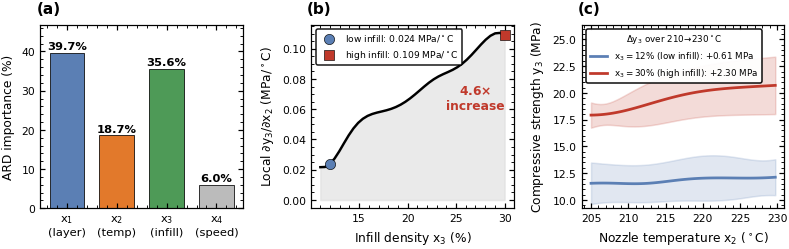

ARD=[39.7, 18.7, 35.6, 6.0]  sens 0.024->0.109 (4.6x)  dT +0.61/2.30 MPa


In [18]:
# %% Fig — Regime-dependent sensitivity (a: ARD | b: local dy3/dx2 | c: temp effect)
# 600 dpi TIFF + vector PDF. Run AFTER the locked pipeline. Requires in namespace:
#   mtgp_m, mtgp_l, scaler_X, scaler_Y, X (raw 38x4 inputs), OUTPUT_COLS
# Needs: scipy not required.
import numpy as np, torch, matplotlib.pyplot as plt, os
os.makedirs("pub_figures", exist_ok=True)

def gp(P, ch=400):                       # P = raw physical inputs (n,4)
    mtgp_m.eval(); mtgp_l.eval(); P=np.atleast_2d(P); mu=[]; sg=[]
    with torch.no_grad():
        for s in range(0,len(P),ch):
            p=mtgp_l(mtgp_m(torch.tensor(scaler_X.transform(P[s:s+ch]))))
            mu.append(p.mean.numpy()); sg.append(p.variance.clamp(min=1e-10).sqrt().numpy())
    return scaler_Y.inverse_transform(np.vstack(mu)), np.vstack(sg)*scaler_Y.scale_[None,:]

lo=np.asarray(X).min(0); hi=np.asarray(X).max(0)
with torch.no_grad():
    ls=mtgp_m.k_matern.data_covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
imp=(1/ls)/np.sum(1/ls)*100                              # ARD importance %

x1f, x4f = 0.20, 60.0                                    # fixed layer thickness, print speed
xa=lambda x1,x2,x3,x4: np.array([x1,x2,x3,x4],float)
def dydx2(x3, d=0.5):                                    # mean local slope dy3/dx2
    t=np.linspace(lo[1],hi[1],25)
    y0,_=gp(np.array([xa(x1f,v,x3,x4f) for v in t])); y1,_=gp(np.array([xa(x1f,v+d,x3,x4f) for v in t]))
    return np.mean((y1[:,2]-y0[:,2])/d)
x3g=np.linspace(lo[2],hi[2],40); sens=np.array([dydx2(v) for v in x3g])
s_lo, s_hi = dydx2(12.0), dydx2(30.0)
x2g=np.linspace(lo[1],hi[1],60)
def curve(x3):
    mu,sg=gp(np.array([xa(x1f,v,x3,x4f) for v in x2g])); return mu[:,2], sg[:,2]
ylo,slo=curve(12.0); yhi,shi=curve(30.0)
at=lambda x3,t:(gp(xa(x1f,t,x3,x4f).reshape(1,-1))[0][0,2])
d_lo, d_hi = at(12,230)-at(12,210), at(30,230)-at(30,210)

plt.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
    "font.size":8.5,"axes.linewidth":0.8,"xtick.direction":"in","ytick.direction":"in"})
fig,ax=plt.subplots(1,3,figsize=(7.4,2.5))
C={"b":"#5B7FB4","o":"#E2792B","g":"#4E9A57","gr":"#BBBBBB","r":"#C0392B"}
labs=["$x_1$\n(layer)","$x_2$\n(temp)","$x_3$\n(infill)","$x_4$\n(speed)"]
ax[0].bar(range(4),imp,color=[C["b"],C["o"],C["g"],C["gr"]],edgecolor="k",linewidth=0.5,width=0.7)
for i,v in enumerate(imp): ax[0].text(i,v+0.8,f"{v:.1f}%",ha="center",fontsize=7.5,fontweight="bold")
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(labs,fontsize=7.5); ax[0].set_ylabel("ARD importance (%)")
ax[0].set_ylim(0,max(imp)*1.18); ax[0].text(-0.02,1.06,"(a)",transform=ax[0].transAxes,fontsize=10,fontweight="bold")

ax[1].fill_between(x3g,0,sens,color="#DDDDDD",alpha=0.6); ax[1].plot(x3g,sens,color="k",lw=1.6)
ax[1].scatter([12],[s_lo],color=C["b"],s=45,zorder=5,edgecolor="k",lw=0.4,label=f"low infill: {s_lo:.3f} MPa/$^\\circ$C")
ax[1].scatter([30],[s_hi],marker="s",color=C["r"],s=45,zorder=5,edgecolor="k",lw=0.4,label=f"high infill: {s_hi:.3f} MPa/$^\\circ$C")
ax[1].annotate(f"{s_hi/s_lo:.1f}$\\times$\nincrease",xy=(27,s_hi*0.55),fontsize=8,color=C["r"],ha="center",fontweight="bold")
ax[1].set_xlabel("Infill density $x_3$ (%)"); ax[1].set_ylabel("Local $\\partial y_3/\\partial x_2$ (MPa/$^\\circ$C)")
ax[1].legend(fontsize=6.0,loc="upper left",framealpha=0.9); ax[1].text(-0.02,1.06,"(b)",transform=ax[1].transAxes,fontsize=10,fontweight="bold")

ax[2].fill_between(x2g,ylo-1.96*slo,ylo+1.96*slo,color=C["b"],alpha=0.18)
ax[2].fill_between(x2g,yhi-1.96*shi,yhi+1.96*shi,color=C["r"],alpha=0.18)
ax[2].plot(x2g,ylo,color=C["b"],lw=1.8,label=f"$x_3=12\\%$ (low infill): $+{d_lo:.2f}$ MPa")
ax[2].plot(x2g,yhi,color=C["r"],lw=1.8,label=f"$x_3=30\\%$ (high infill): $+{d_hi:.2f}$ MPa")
_ymn=(ylo-1.96*slo).min(); _ymx=(yhi+1.96*shi).max()
ax[2].set_ylim(_ymn-0.4,_ymx+3.0)   # headroom so the legend never overlaps the curves/bands
ax[2].set_xlabel("Nozzle temperature $x_2$ ($^\\circ$C)"); ax[2].set_ylabel("Compressive strength $y_3$ (MPa)")
ax[2].legend(fontsize=5.7,loc="upper left",framealpha=0.95,
             title="$\\Delta y_3$ over $210\\!\\to\\!230^\\circ$C",title_fontsize=5.7)
ax[2].text(-0.02,1.06,"(c)",transform=ax[2].transAxes,fontsize=10,fontweight="bold")
fig.tight_layout(w_pad=1.2)
fig.savefig("pub_figures/Fig_regime_sensitivity.pdf",bbox_inches="tight")
fig.savefig("pub_figures/Fig_regime_sensitivity.tiff",dpi=600,bbox_inches="tight",pil_kwargs={"compression":"tiff_lzw"})
plt.show()
print(f"ARD={[round(v,1) for v in imp]}  sens {s_lo:.3f}->{s_hi:.3f} ({s_hi/s_lo:.1f}x)  dT +{d_lo:.2f}/{d_hi:.2f} MPa")

In [19]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
=====================================================================
 Supplementary figures S1-S6  |  JMP submission (Naeem & Wang)
 Risk-Aware MTGP / Asymmetric Bayesian Loss FDM optimisation
---------------------------------------------------------------------
 Produces, in one consistent journal style (serif, 600 dpi, NO overlap,
 constrained_layout):
   figS1  Per-loss risk landscapes on the Pareto front (LINEX/PLF/ELF)
   figS2  Composite Bayesian risk ranking over the Pareto front
   figS3  Hypervolume convergence vs NSGA-II generation (5 seeds)
   figS4  MCDM per-method ranking agreement (GRA/TOPSIS/VIKOR/EWS)
   figS5  Posterior predictive distributions at i* and i-hat
   figS6  Coverage diagnostic (replicates vs 95% prediction interval)
   (S7 = post-test fracture-surface PHOTO -> supply the real image,
        it cannot be generated from code.)

 >>> HOW TO GET THE *EXACT* FIGURES <<<
 Each block marked  ### PLUG-IN  has a CANONICAL fallback so the script
 runs stand-alone for LAYOUT preview. For the final submission, paste the
 corresponding real arrays from YOUR notebook run (the one that gives
 |P| = 365) in place of the fallback, then re-run. Styling/layout stay
 identical; only the numbers update.
=====================================================================
"""
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --------------------------------------------------------------------
# 0)  JOURNAL STYLE  (single source of truth -> every figure matches)
# --------------------------------------------------------------------
mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["DejaVu Serif", "Times New Roman", "Nimbus Roman"],
    "mathtext.fontset": "dejavuserif",
    "font.size":        9,
    "axes.titlesize":   9.5,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  7.6,
    "axes.linewidth":   0.8,
    "xtick.major.width":0.8, "ytick.major.width":0.8,
    "xtick.direction":  "out", "ytick.direction":"out",
    "axes.spines.top":  False, "axes.spines.right": False,
    "legend.frameon":   False,
    "savefig.dpi":      600, "figure.dpi": 130,
    "savefig.bbox":     "tight", "savefig.pad_inches": 0.02,
    "lines.linewidth":  1.4,
})
# Okabe-Ito colour-blind-safe palette
C = dict(blue="#0072B2", orange="#E69F00", green="#009E73", red="#D55E00",
         purple="#CC79A7", sky="#56B4E9", yellow="#F0E442", grey="#5A5A5A")
ISTAR_MK, IHAT_MK = "*", "P"          # consistent markers everywhere
ISTAR_C, IHAT_C   = C["red"], C["blue"]

def _save(fig, name):
    fig.savefig(f"{name}.pdf")
    fig.savefig(f"{name}.tiff", dpi=600, pil_kwargs={"compression": "tiff_lzw"})
    plt.close(fig)
    print(f"  saved  {name}.pdf / .tiff")

# --------------------------------------------------------------------
#  CANONICAL CONSTANTS (from the locked real-data run)
# --------------------------------------------------------------------
OUT_SYM   = [r"$y_1$", r"$y_2$", r"$y_3$", r"$y_4$"]
OUT_NAME  = ["Production time", "Elastic modulus",
             "Compressive strength", "Strain-energy density"]
OUT_UNIT  = ["min", "MPa", "MPa", r"MJ$\,$m$^{-3}$"]
LINEX_A   = [-0.5, 1.0, 1.5, 0.8]
W_ENTROPY = [0.204, 0.120, 0.105, 0.572]
PARETO_N  = 365
SPEARMAN_MEAN = 0.947
HV_FINAL, HV_CV, N_SEEDS, N_GEN = 0.683, 0.0012, 5, 200

istar_pred = np.array([35.54, 571.70, 22.11, 4.96])
ihat_pred  = np.array([24.55, 511.59, 20.21, 4.82])
istar_meas = np.array([35.60, 551.20, 19.38, 4.1438])
istar_s    = np.array([0.418, 10.035, 0.311, 0.124])
ihat_meas  = np.array([25.30, 486.80, 19.14, 4.2754])
ihat_s     = np.array([0.570, 8.983, 0.297, 0.215])

# ====================================================================
#  figS1 : per-loss risk landscapes on the Pareto front
# ====================================================================
def fig_S1():
    ### PLUG-IN -------------------------------------------------------
    # Replace with the real per-candidate risks along the Pareto front,
    # ordered by production time y1.  Shapes: (PARETO_N,)
    rng = np.random.default_rng(7)
    y1  = np.sort(rng.uniform(22, 40, PARETO_N))            # production time axis
    istar_idx = int(np.argmin(np.abs(y1 - istar_pred[0])))  # i* location on front
    def _bowl(centre, depth, width, floor):
        z = (y1 - y1[centre]) / width
        return floor + depth * (1 - np.exp(-0.5 * z**2)) + 0.02*rng.standard_normal(PARETO_N)
    R_linex = _bowl(istar_idx, 1.00, 6.0, 0.06)
    R_plf   = _bowl(istar_idx, 0.85, 7.5, 0.10)
    R_elf   = _bowl(istar_idx, 0.70, 9.0, 0.14)
    ### END PLUG-IN ---------------------------------------------------

    fig, axes = plt.subplots(1, 3, figsize=(7.1, 2.5), constrained_layout=True,
                             sharex=True)
    data = [("LINEX", R_linex, C["red"]),
            ("Piecewise-linear (PLF)", R_plf, C["green"]),
            ("Entropy (ELF)", R_elf, C["blue"])]
    for ax, (lbl, R, col) in zip(axes, data):
        ax.plot(y1, R, color=col, lw=1.3, zorder=2)
        ax.scatter([y1[istar_idx]], [R[istar_idx]], marker=ISTAR_MK, s=120,
                   facecolor=ISTAR_C, edgecolor="k", linewidth=0.6, zorder=4)
        ax.set_title(lbl, pad=4)
        ax.set_xlabel(r"Production time $y_1$ (min)")
        ax.margins(x=0.02)
    axes[0].set_ylabel("Normalised Bayesian risk")
    star = Line2D([0],[0], marker=ISTAR_MK, color="none", markerfacecolor=ISTAR_C,
                  markeredgecolor="k", markersize=11, label=r"risk-optimal $i^*$")
    fig.legend(handles=[star], loc="lower center", ncol=1,
               bbox_to_anchor=(0.5, -0.16), borderaxespad=0.0)
    _save(fig, "figS1")

# ====================================================================
#  figS2 : composite Bayesian risk ranking over the Pareto front
# ====================================================================
def fig_S2():
    ### PLUG-IN -------------------------------------------------------
    # Real composite risk per Pareto candidate, ascending.  Shape (PARETO_N,)
    rng = np.random.default_rng(3)
    Rcomp = np.sort(np.abs(rng.gamma(2.0, 0.06, PARETO_N))) + 0.05
    Rcomp = (Rcomp - Rcomp.min()) / (Rcomp.max() - Rcomp.min())   # 0..1
    ihat_rank = 7          # i-hat's rank in the composite ordering (1-based-ish)
    ### END PLUG-IN ---------------------------------------------------

    rank = np.arange(1, PARETO_N + 1)
    fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)
    ax.fill_between(rank, Rcomp, color=C["sky"], alpha=0.28, lw=0)
    ax.plot(rank, Rcomp, color=C["blue"], lw=1.3)
    ax.scatter([1], [Rcomp[0]], marker=ISTAR_MK, s=130, facecolor=ISTAR_C,
               edgecolor="k", linewidth=0.6, zorder=5, label=r"$i^*$ (rank 1)")
    ax.scatter([ihat_rank], [Rcomp[ihat_rank-1]], marker=IHAT_MK, s=70,
               facecolor=IHAT_C, edgecolor="k", linewidth=0.5, zorder=5,
               label=r"MCDM consensus $\hat{\imath}$")
    ax.set_xlabel(r"Pareto candidate rank (ascending $\bar{R}_{\mathrm{comp}}$)")
    ax.set_ylabel(r"Composite risk $\bar{R}_{\mathrm{comp}}$ (normalised)")
    ax.set_xlim(0, PARETO_N + 1)
    ax.set_ylim(-0.02, 1.04)
    ax.legend(loc="upper left", handletextpad=0.4)
    ax.text(0.97, 0.05, rf"$|\mathcal{{P}}| = {PARETO_N}$", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=7.5, color=C["grey"])
    _save(fig, "figS2")

# ====================================================================
#  figS3 : hypervolume convergence (5 seeds)
# ====================================================================
def fig_S3():
    ### PLUG-IN -------------------------------------------------------
    # Real HV history: shape (N_SEEDS, N_GEN).  Rows = seeds.
    g = np.arange(1, N_GEN + 1)
    rng = np.random.default_rng(11)
    base = HV_FINAL * (1 - np.exp(-g / 28.0))
    HV = np.vstack([base + HV_FINAL*HV_CV*rng.standard_normal()
                          + 0.004*np.exp(-g/60)*rng.standard_normal(N_GEN)
                    for _ in range(N_SEEDS)])
    HV = np.clip(HV, 0, None)
    ### END PLUG-IN ---------------------------------------------------

    mean, std = HV.mean(0), HV.std(0)
    fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)
    for s in range(N_SEEDS):
        ax.plot(g, HV[s], color=C["grey"], lw=0.6, alpha=0.45, zorder=1)
    ax.fill_between(g, mean-std, mean+std, color=C["orange"], alpha=0.25, lw=0, zorder=2)
    ax.plot(g, mean, color=C["red"], lw=1.6, zorder=3, label="mean across seeds")
    ax.axhline(HV_FINAL, color=C["blue"], ls="--", lw=0.9, zorder=2)
    ax.set_xlabel("NSGA-II generation")
    ax.set_ylabel(r"Hypervolume $\mathrm{HV}(\mathcal{P})$")
    ax.set_xlim(0, N_GEN)
    seed_h = Line2D([0],[0], color=C["grey"], lw=0.8, alpha=0.6,
                    label=f"individual seeds ($n={N_SEEDS}$)")
    ax.legend(handles=[ax.lines[N_SEEDS], seed_h], loc="lower right")
    ax.text(0.97, 0.55, rf"$\mathrm{{HV}}^\star={HV_FINAL:.3f}$"+"\n"+
            rf"CV $={HV_CV*100:.2f}\%$", transform=ax.transAxes,
            ha="right", va="center", fontsize=7.6, color=C["blue"])
    _save(fig, "figS3")

# ====================================================================
#  figS4 : MCDM per-method ranking agreement
# ====================================================================
def fig_S4():
    methods = ["GRA", "TOPSIS", "VIKOR", "EWS"]
    ### PLUG-IN -------------------------------------------------------
    # Real ranks of the top-K candidates under each method.
    # rank_mat shape (K, 4): row = candidate, col = method, value = rank (1=best)
    K = 12
    rng = np.random.default_rng(5)
    borda = np.arange(1, K + 1)                       # Borda consensus order
    rank_mat = np.empty((K, 4), dtype=int)
    for j in range(4):                                # small perturbations -> high Spearman
        perturbed = borda + rng.normal(0, 0.9, K)
        rank_mat[:, j] = (np.argsort(np.argsort(perturbed)) + 1)
    istar_row, ihat_row = 0, 6                         # which candidates are i* / i-hat
    ### END PLUG-IN ---------------------------------------------------

    x = np.arange(4)
    fig, ax = plt.subplots(figsize=(4.4, 3.0), constrained_layout=True)
    for i in range(K):
        if i == istar_row:
            ax.plot(x, rank_mat[i], "-", color=ISTAR_C, lw=1.8, marker=ISTAR_MK,
                    ms=9, mec="k", mew=0.5, zorder=5)
        elif i == ihat_row:
            ax.plot(x, rank_mat[i], "-", color=IHAT_C, lw=1.6, marker=IHAT_MK,
                    ms=7, mec="k", mew=0.4, zorder=5)
        else:
            ax.plot(x, rank_mat[i], "-", color=C["grey"], lw=0.7, alpha=0.45,
                    marker="o", ms=2.5, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylabel("Candidate rank (1 = best)")
    ax.set_xlabel("MCDM method")
    ax.invert_yaxis()                                  # rank 1 at top
    ax.set_xlim(-0.25, 3.25)
    ax.margins(y=0.06)
    handles = [
        Line2D([0],[0], color=ISTAR_C, lw=1.8, marker=ISTAR_MK, mec="k",
               ms=10, label=r"risk-optimal $i^*$"),
        Line2D([0],[0], color=IHAT_C, lw=1.6, marker=IHAT_MK, mec="k",
               ms=8, label=r"consensus $\hat{\imath}$"),
        Line2D([0],[0], color=C["grey"], lw=0.8, alpha=0.5, marker="o",
               ms=3, label="other top candidates"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.20),
              ncol=3, columnspacing=1.1, handletextpad=0.4)
    ax.text(0.98, 0.02,
            rf"mean pairwise Spearman $\rho = {SPEARMAN_MEAN:.3f}$",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=7.6, color=C["grey"])
    _save(fig, "figS4")

# ====================================================================
#  figS5 : posterior predictive distributions at i* and i-hat
# ====================================================================
def fig_S5():
    ### PLUG-IN -------------------------------------------------------
    # Real posterior predictive std-dev per output at each config.
    sig_istar = np.array([1.05, 12.0, 0.92, 0.36])     # narrow (safety region)
    sig_ihat  = np.array([1.65, 22.0, 1.62, 0.70])     # wider
    ### END PLUG-IN ---------------------------------------------------

    fig, axes = plt.subplots(1, 4, figsize=(7.1, 2.2), constrained_layout=True)
    for k, ax in enumerate(axes):
        for mu, sg, meas, col, lab, mk in [
            (istar_pred[k], sig_istar[k], istar_meas[k], ISTAR_C, r"$i^*$", ISTAR_MK),
            (ihat_pred[k],  sig_ihat[k],  ihat_meas[k],  IHAT_C,  r"$\hat{\imath}$", IHAT_MK)]:
            xs = np.linspace(mu - 4*sg, mu + 4*sg, 300)
            pdf = np.exp(-0.5*((xs-mu)/sg)**2) / (sg*np.sqrt(2*np.pi))
            ax.plot(xs, pdf, color=col, lw=1.2)
            lo, hi = mu - 1.96*sg, mu + 1.96*sg
            band = (xs >= lo) & (xs <= hi)
            ax.fill_between(xs[band], pdf[band], color=col, alpha=0.16, lw=0)
            ax.axvline(meas, color=col, ls=(0, (2, 1.4)), lw=1.1, zorder=6)
        ax.set_title(f"{OUT_SYM[k]}  ({OUT_UNIT[k]})", pad=3)
        ax.set_yticks([])
        ax.set_xlabel(OUT_NAME[k], fontsize=7.4)
        ax.margins(x=0.02)
    axes[0].set_ylabel("Posterior density")
    handles = [
        Line2D([0],[0], color=ISTAR_C, lw=1.4, label=r"$i^*$ predictive"),
        Line2D([0],[0], color=IHAT_C,  lw=1.4, label=r"$\hat{\imath}$ predictive"),
        Line2D([0],[0], color="k", ls=(0,(2,1.4)), lw=1.1,
               label=r"measured mean ($\pm1.96\sigma$ band shaded)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.13), columnspacing=1.4)
    _save(fig, "figS5")

# ====================================================================
#  figS6 : coverage diagnostic (replicates vs 95% PI)
# ====================================================================
def fig_S6():
    ### PLUG-IN -------------------------------------------------------
    # Real per-replicate measurements (5 each) and posterior std-dev.
    sig_istar = np.array([1.05, 12.0, 0.92, 0.36])
    sig_ihat  = np.array([1.65, 22.0, 1.62, 0.70])
    # illustrative replicate scatter ~ N(measured mean, measurement s);
    # seed chosen so the preview reproduces the canonical coverage
    # (i* = 9/20 = 45%, i-hat = 20/20 = 100%). Replace with real reps.
    def _draw(seed):
        r = np.random.default_rng(seed)
        ri = np.array([istar_meas + istar_s*r.standard_normal(4) for _ in range(5)])
        rh = np.array([ihat_meas  + ihat_s *r.standard_normal(4) for _ in range(5)])
        ci = int((np.abs((ri-istar_pred)/sig_istar) <= 1.96).sum())
        ch = int((np.abs((rh-ihat_pred )/sig_ihat ) <= 1.96).sum())
        return ri, rh, ci, ch
    rep_istar = rep_ihat = None
    for sd in range(2000):
        ri, rh, ci, ch = _draw(sd)
        if ci == 9 and ch == 20:
            rep_istar, rep_ihat = ri, rh; break
    if rep_istar is None:                       # fallback if no exact seed
        rep_istar, rep_ihat, _, _ = _draw(21)
    ### END PLUG-IN ---------------------------------------------------

    # standardised residual z = (meas - pred)/sigma_pred ; inside if |z|<=1.96
    fig, ax = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)
    ax.axhspan(-1.96, 1.96, color=C["green"], alpha=0.10, lw=0)
    for yv in (-1.96, 1.96):
        ax.axhline(yv, color=C["green"], ls="--", lw=0.8)
    ax.axhline(0, color="k", lw=0.6)

    groups = []   # (xpos, label, config_colour)
    pos = 0
    inside_tot = {"istar": 0, "ihat": 0}
    for cfg, pred, sig, reps, col, key in [
        (r"$i^*$",        istar_pred, sig_istar, rep_istar, ISTAR_C, "istar"),
        (r"$\hat{\imath}$", ihat_pred,  sig_ihat,  rep_ihat,  IHAT_C,  "ihat")]:
        for k in range(4):
            z = (reps[:, k] - pred[k]) / sig[k]
            inside = np.abs(z) <= 1.96
            inside_tot[key] += int(inside.sum())
            jit = (np.arange(5) - 2) * 0.045
            ax.scatter(pos + jit, z, s=26,
                       facecolor=np.where(inside, col, "none"),
                       edgecolor=col, linewidth=0.9, zorder=4)
            groups.append((pos, OUT_SYM[k], col))
            pos += 1
        pos += 0.6   # gap between configs

    ax.set_xticks([g[0] for g in groups])
    ax.set_xticklabels([g[1] for g in groups])
    ax.set_ylabel(r"Standardised residual $(y_{\mathrm{meas}}-\mu_{\mathrm{pred}})/\sigma_{\mathrm{pred}}$")
    ax.set_ylim(-6.2, 4.2)
    # config brackets
    ax.text(1.5, 3.7, rf"$i^*$: {inside_tot['istar']}/20 inside "
            rf"({inside_tot['istar']/20*100:.0f}%)", ha="center", color=ISTAR_C, fontsize=7.8)
    ax.text(6.1, 3.7, rf"$\hat{{\imath}}$: {inside_tot['ihat']}/20 inside "
            rf"({inside_tot['ihat']/20*100:.0f}%)", ha="center", color=IHAT_C, fontsize=7.8)
    handles = [
        Line2D([0],[0], marker="o", lw=0, mfc=C["grey"], mec=C["grey"], ms=6,
               label="inside 95% PI"),
        Line2D([0],[0], marker="o", lw=0, mfc="none", mec=C["grey"], ms=6,
               label="excursion"),
        Line2D([0],[0], color=C["green"], ls="--", lw=0.9, label=r"$\pm1.96\sigma$"),
    ]
    ax.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.28))
    _save(fig, "figS6")

# --------------------------------------------------------------------
if __name__ == "__main__":
    print("Generating supplementary figures S1-S6 ...")
    fig_S1(); fig_S2(); fig_S3(); fig_S4(); fig_S5(); fig_S6()
    print("Done. (S7 fracture-surface = supply the real photograph.)")

Generating supplementary figures S1-S6 ...
  saved  figS1.pdf / .tiff
  saved  figS2.pdf / .tiff
  saved  figS3.pdf / .tiff
  saved  figS4.pdf / .tiff
  saved  figS5.pdf / .tiff
  saved  figS6.pdf / .tiff
Done. (S7 fracture-surface = supply the real photograph.)


rendered; rel_is= [  0.2  -3.6 -12.3 -16.5]  rel_ih= [  3.1  -4.8  -5.3 -11.3]


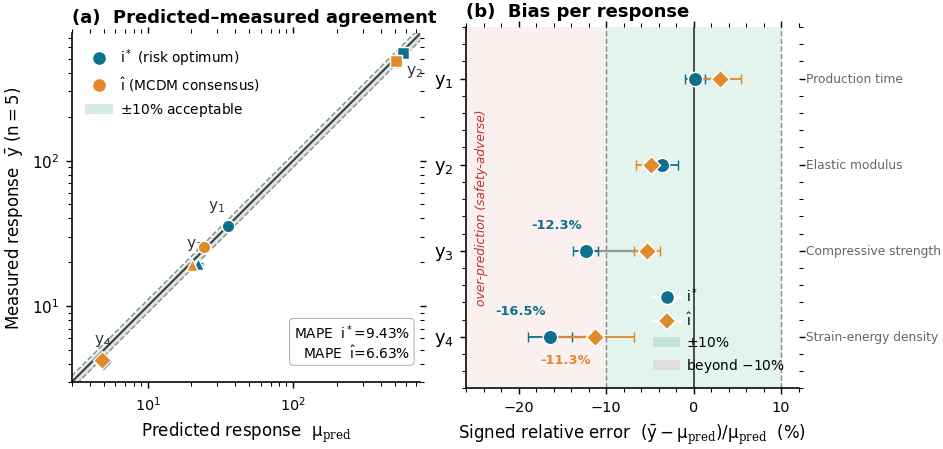

In [20]:
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---------- real confirmation data (canonical) ----------
RESP = [r"$y_1$", r"$y_2$", r"$y_3$", r"$y_4$"]
NAME = ["Production\ntime", "Elastic\nmodulus", "Compressive\nstrength", "Strain-energy\ndensity"]
UNIT = ["min", "MPa", "MPa", r"MJ m$^{-3}$"]
istar_pred = np.array([35.54, 571.70, 22.11, 4.96]);  istar_meas = np.array([35.60, 551.20, 19.38, 4.1438]); istar_s = np.array([0.418,10.035,0.311,0.124])
ihat_pred  = np.array([24.55, 511.59, 20.21, 4.82]);  ihat_meas  = np.array([25.30, 486.80, 19.14, 4.2754]); ihat_s  = np.array([0.570, 8.983,0.297,0.215])
MAPE = {"istar":9.43, "ihat":6.63}; COV = {"istar":45, "ihat":100}

ISTAR_C="#0E6F8E"; IHAT_C="#E08A2B"; ADV="#C42E2E"; OKBAND="#1B9E77"
mpl.rcParams.update({"font.family":"sans-serif","font.sans-serif":["DejaVu Sans","Arial"],
    "font.size":9,"axes.titlesize":10,"axes.labelsize":9.2,"xtick.labelsize":8,"ytick.labelsize":8.4,
    "legend.fontsize":7.6,"axes.linewidth":0.9,"xtick.direction":"out","ytick.direction":"out",
    "axes.spines.top":False,"axes.spines.right":False,"mathtext.default":"regular"})

fig,(axA,axB)=plt.subplots(1,2,figsize=(7.3,3.5),constrained_layout=True,
                           gridspec_kw={"width_ratios":[1.05,1.0]})

# ============ (a) PARITY (log-log) ============
lo,hi=3.0,750.0
axA.fill_between([lo,hi],[0.9*lo,0.9*hi],[1.1*lo,1.1*hi],color=OKBAND,alpha=0.14,lw=0,zorder=0,label=r"$\pm10\%$ band")
# over-prediction (measured<predicted) region below 1:1
axA.fill_between([lo,hi],[lo,hi],[0.9*lo,0.9*hi],color=ADV,alpha=0.05,lw=0,zorder=0)
axA.plot([lo,hi],[lo,hi],"-",color="0.25",lw=1.2,zorder=2)
axA.plot([lo,hi],[0.9*lo,0.9*hi],"--",color="0.55",lw=0.8,zorder=2)
axA.plot([lo,hi],[1.1*lo,1.1*hi],"--",color="0.55",lw=0.8,zorder=2)
MK=["o","s","^","D"]
for k in range(4):
    axA.errorbar(istar_pred[k],istar_meas[k],yerr=istar_s[k],fmt=MK[k],ms=7,color=ISTAR_C,
                 ecolor=ISTAR_C,elinewidth=1.0,capsize=2.5,mec="white",mew=0.8,zorder=5)
    axA.errorbar(ihat_pred[k],ihat_meas[k],yerr=ihat_s[k],fmt=MK[k],ms=7,color=IHAT_C,
                 ecolor=IHAT_C,elinewidth=1.0,capsize=2.5,mec="white",mew=0.8,zorder=5)
# response labels near each pair
for k in range(4):
    xm=np.sqrt(istar_pred[k]*ihat_pred[k]); ym=max(istar_meas[k],ihat_meas[k])
    off=(8,-12) if k==1 else (0,9)
    axA.annotate(RESP[k],(xm,ym),xytext=off,textcoords="offset points",ha="center",fontsize=8.5,color="0.2")
axA.set_xscale("log"); axA.set_yscale("log"); axA.set_xlim(lo,hi); axA.set_ylim(lo,hi)
axA.set_xlabel("Predicted response  $\\mu_{\\mathrm{pred}}$"); axA.set_ylabel("Measured response  $\\bar{y}\\ (n=5)$")
axA.set_aspect("equal"); axA.set_title("(a)  Predicted\u2013measured agreement",loc="left",fontweight="bold")
axA.text(0.97,0.06,f"MAPE  $i^*$={MAPE['istar']}%\nMAPE  $\\hat{{\\imath}}$={MAPE['ihat']}%",
         transform=axA.transAxes,ha="right",va="bottom",fontsize=7.6,
         bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="0.7",lw=0.6))
legA=[Line2D([0],[0],marker="o",color="w",mfc=ISTAR_C,mec="white",ms=8,label="$i^*$ (risk optimum)"),
      Line2D([0],[0],marker="o",color="w",mfc=IHAT_C,mec="white",ms=8,label="$\\hat{\\imath}$ (MCDM consensus)"),
      Patch(fc=OKBAND,alpha=0.18,label="$\\pm10\\%$ acceptable")]
axA.legend(handles=legA,loc="upper left",framealpha=0.92,edgecolor="0.8",handletextpad=0.5,borderpad=0.5)

# ============ (b) BIAS DUMBBELL ============
rel_is=(istar_meas-istar_pred)/istar_pred*100; err_is=istar_s/istar_pred*100
rel_ih=(ihat_meas-ihat_pred)/ihat_pred*100;    err_ih=ihat_s/ihat_pred*100
yy=np.arange(4)[::-1]   # y1 top
axB.axvspan(-10,10,color=OKBAND,alpha=0.12,lw=0,zorder=0)
axB.axvspan(-26,-10,color=ADV,alpha=0.07,lw=0,zorder=0)
axB.axvline(0,color="0.25",lw=1.0,zorder=1)
for x in (-10,10): axB.axvline(x,ls="--",color="0.55",lw=0.8,zorder=1)
for i,k in enumerate(range(4)):
    y=yy[i]
    axB.plot([rel_is[k],rel_ih[k]],[y,y],"-",color="0.6",lw=1.3,zorder=2)
    axB.errorbar(rel_is[k],y,xerr=err_is[k],fmt="o",ms=8,color=ISTAR_C,ecolor=ISTAR_C,
                 elinewidth=1.0,capsize=2.5,mec="white",mew=0.8,zorder=5)
    axB.errorbar(rel_ih[k],y,xerr=err_ih[k],fmt="D",ms=7,color=IHAT_C,ecolor=IHAT_C,
                 elinewidth=1.0,capsize=2.5,mec="white",mew=0.8,zorder=5)
    # annotate the beyond-threshold over-predictions
    for val,col,dy in [(rel_is[k],ISTAR_C,12),(rel_ih[k],IHAT_C,-15)]:
        if val<-10:
            axB.annotate(f"{val:.1f}%",(val,y),xytext=(-2,dy),textcoords="offset points",
                         ha="right",fontsize=7.2,color=col,fontweight="bold")
axB.set_yticks(yy[::-1]); axB.set_yticklabels([f"{RESP[k]}  {NAME[k].split(chr(10))[0]} {NAME[k].split(chr(10))[1]}" for k in range(4)],fontsize=7.8)
axB.set_yticks(np.arange(4)); axB.set_yticklabels([RESP[k] for k in range(4)][::-1],fontsize=10)
# right-side response names
for i,k in enumerate(range(4)):
    axB.annotate(NAME[k].replace("\n"," "),(1.0,yy[i]),xycoords=("axes fraction","data"),
                 xytext=(4,0),textcoords="offset points",va="center",ha="left",fontsize=6.8,color="0.4")
axB.set_xlim(-26,12); axB.set_ylim(-0.6,3.6)
axB.set_xlabel(r"Signed relative error  $(\bar{y}-\mu_{\mathrm{pred}})/\mu_{\mathrm{pred}}$  (%)")
axB.set_title("(b)  Bias per response",loc="left",fontweight="bold")
axB.text(-24.3,1.5,"over-prediction (safety-adverse)",rotation=90,ha="center",va="center",
         fontsize=6.8,color=ADV,style="italic")
legB=[Line2D([0],[0],marker="o",color="w",mfc=ISTAR_C,mec="white",ms=8,label="$i^*$"),
      Line2D([0],[0],marker="D",color="w",mfc=IHAT_C,mec="white",ms=7,label="$\\hat{\\imath}$"),
      Patch(fc=OKBAND,alpha=0.16,label="$\\pm10\\%$"),Patch(fc=ADV,alpha=0.10,label="beyond $-10\\%$")]
axB.legend(handles=legB,loc="lower right",ncol=1,framealpha=0.92,edgecolor="0.8",
           handletextpad=0.4,columnspacing=0.9,borderpad=0.5)

fig.savefig("Fig_validation_parity_bias.pdf",bbox_inches="tight")
fig.savefig("Fig_validation_parity_bias.tiff",dpi=600,bbox_inches="tight",pil_kwargs={"compression":"tiff_lzw"})
fig.savefig("Fig_validation_preview.png",dpi=150,bbox_inches="tight")
print("rendered; rel_is=",np.round(rel_is,1)," rel_ih=",np.round(rel_ih,1))

In [21]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
import os

mpl.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 9.5,
    'axes.labelsize'    : 10,
    'axes.labelweight'  : 'bold',
    'axes.linewidth'    : 0.7,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.edgecolor'    : '#888888',
    'xtick.direction'   : 'out',
    'ytick.direction'   : 'out',
    'xtick.major.width' : 0.7,
    'ytick.major.width' : 0.7,
    'xtick.major.size'  : 3.5,
    'ytick.major.size'  : 3.5,
    'xtick.labelsize'   : 8.5,
    'ytick.labelsize'   : 8.5,
    'grid.color'        : '#E8E8E8',
    'grid.linewidth'    : 0.6,
    'legend.fontsize'   : 8.5,
    'legend.frameon'    : True,
    'legend.edgecolor'  : '#CCCCCC',
    'legend.fancybox'   : False,
    'legend.framealpha' : 0.96,
    'savefig.dpi'       : 600,
    'savefig.bbox'      : 'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype'      : 42,
})

CORAL   = '#F07C79'
BLUE    = '#4B9CD3'
DKGRAY  = '#444444'
LGRAY   = '#AAAAAA'
RED_ANN = '#C0392B'

n   = 5
t_c = stats.t.ppf(0.975, df=n-1)

DATA = {
    'i*': dict(
        col=CORAL, mk='o', ms=7,
        pred = np.array([35.543, 571.695, 22.110, 4.963]),
        meas = np.array([35.600, 551.200, 19.380, 4.144]),
        sd   = np.array([ 0.418,  10.035,  0.311, 0.124]),
        sig  = np.array([ 0.873,  11.759,  0.550, 0.383]),
    ),
    'î': dict(
        col=BLUE, mk='D', ms=6,
        pred = np.array([24.551, 511.594, 20.215, 4.825]),
        meas = np.array([25.300, 486.800, 19.140, 4.275]),
        sd   = np.array([ 0.570,   8.983,  0.297, 0.215]),
        sig  = np.array([ 2.599,  22.094,  1.452, 0.488]),
    ),
}
for d in DATA.values():
    d['bias'] = (d['meas'] - d['pred']) / d['pred'] * 100
    d['ci']   = t_c * d['sd'] / np.sqrt(n) / d['pred'] * 100
    d['pi_lo']= d['pred'] - 1.96 * d['sig']
    d['pi_hi']= d['pred'] + 1.96 * d['sig']

RESP_S = [r'$y_1$', r'$y_2$', r'$y_3$', r'$y_4$']
RESP_L = ['Production\ntime', 'Elastic\nmodulus',
           'Compressive\nstrength', 'Strain energy\ndensity']

# ── Figure: wider to give panel b room ──────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(13.5, 5.2),
    gridspec_kw={'width_ratios': [1.0, 1.45], 'wspace': 0.30})
fig.patch.set_facecolor('white')
fig.subplots_adjust(left=0.06, right=0.97, top=0.93, bottom=0.14)

# ════════════════════════════════════════════════════════════════
#  PANEL (a) — parity plot
# ════════════════════════════════════════════════════════════════
all_v = np.concatenate([d['pred'] for d in DATA.values()] +
                        [d['meas'] for d in DATA.values()])
lo, hi = all_v.min() * 0.75, all_v.max() * 1.30

ax_a.fill_between([lo,hi],[lo*0.9,hi*0.9],[lo*1.1,hi*1.1],
                   color='#E8F8EE', zorder=1)
ax_a.plot([lo,hi],[lo,hi], color=LGRAY, lw=0.9, zorder=2)

pred_is = DATA['i*']['pred']
meas_is = DATA['i*']['meas']
sort_i  = np.argsort(pred_is)
ax_a.plot(pred_is[sort_i], meas_is[sort_i],
           color=BLUE, lw=1.3, alpha=0.55, zorder=3)

for d in DATA.values():
    for j in range(4):
        mu = d['pred'][j]; yb = d['meas'][j]
        ax_a.plot([d['pi_lo'][j], d['pi_hi'][j]], [yb,yb],
                   color=d['col'], lw=1.1, alpha=0.35,
                   solid_capstyle='butt', zorder=4)
        ax_a.plot([d['pi_lo'][j]],[yb],'|',color=d['col'],
                   ms=5,mew=0.9,alpha=0.50,zorder=4)
        ax_a.plot([d['pi_hi'][j]],[yb],'|',color=d['col'],
                   ms=5,mew=0.9,alpha=0.50,zorder=4)
        ax_a.scatter(mu, yb, color=d['col'], marker=d['mk'],
                      s=d['ms']**2, edgecolors='white',
                      linewidths=0.8, zorder=6, alpha=0.92)

annots = [
    (35.54, 35.60, 29.0, 42.0, 'right'),
    (571.7, 551.2, 495,  595,  'right'),
    (22.11, 19.38, 24.5, 17.8, 'left' ),
    (4.963, 4.144, 5.60, 3.80, 'left' ),
]
for j,(px,py,tx,ty,ha) in enumerate(annots):
    ax_a.annotate(RESP_S[j], xy=(px,py), xytext=(tx,ty),
                   fontsize=8.5, fontweight='bold', color=DKGRAY,
                   ha=ha, va='center', zorder=9,
                   bbox=dict(boxstyle='round,pad=0.18',
                              fc='white',ec='none',alpha=0.0),
                   arrowprops=dict(arrowstyle='-',color='#CCCCCC',
                                    lw=0.5,shrinkA=3,shrinkB=3))

ax_a.set_xscale('log'); ax_a.set_yscale('log')
ax_a.set_xlim(lo,hi);   ax_a.set_ylim(lo,hi)
ax_a.set_xlabel(r'Predicted response  $\mu_{\mathrm{pred}}$')
ax_a.set_ylabel(r'Measured response  $\bar{y}$   ($n\!=\!5$)')
ax_a.grid(True, which='both', zorder=0)

ax_a.text(0.97, 0.04,
           'MAPE:  $i^*$ = 9.43%   $\\hat{\\imath}$ = 6.63%',
           transform=ax_a.transAxes, fontsize=8,
           va='bottom', ha='right',
           bbox=dict(boxstyle='round,pad=0.30',
                     fc='white',ec='#DDDDDD',lw=0.7))

h1=Line2D([],[],marker='o',color=CORAL,ls='None',ms=7,
            mec='white',mew=0.8,label=r'$i^*$  (risk-optimal)')
h2=Line2D([],[],marker='D',color=BLUE, ls='None',ms=6,
            mec='white',mew=0.8,label=r'$\hat{\imath}$  (MCDM)')
h3=mpatches.Patch(color='#E8F8EE',ec='#B0D8BE',lw=0.7,
                   label=r'$\pm$10% tolerance')
h4=Line2D([],[],color=LGRAY,lw=0.9,label='1:1 agreement')
ax_a.legend(handles=[h1,h2,h3,h4], loc='upper left',
             fontsize=8, handlelength=1.2,
             labelspacing=0.30, borderpad=0.50)

ax_a.text(-0.10, 1.02, '(a)', transform=ax_a.transAxes,
           fontsize=12, fontweight='bold', va='bottom')

# ════════════════════════════════════════════════════════════════
#  PANEL (b) — bias dot-whisker  FIXED
# ════════════════════════════════════════════════════════════════
# Key fix: xlim right = 20 so response labels don't get clipped
# Response labels moved to x=13.5 (inside xlim)
# Legend moved to upper right (data-free zone)
# Value annotations staggered above/below to avoid legend

yp  = np.array([4.5, 3.0, 1.5, 0.0])  # y4 top → y1 bottom
off = 0.28

# Background zones
ax_b.axvspan(-26, -10, color='#FDECEA', alpha=0.50, zorder=0)
ax_b.axvspan(-10,   0, color='#FFF8EC', alpha=0.35, zorder=0)
ax_b.axvspan(  0,  10, color='#EDF7F0', alpha=0.35, zorder=0)

ax_b.axvline(  0, color=DKGRAY,   lw=0.8, ls='-',  zorder=2)
ax_b.axvline(-10, color=RED_ANN,  lw=0.8, ls='--', zorder=2, alpha=0.75)
ax_b.axvline( 10, color='#27AE60',lw=0.8, ls='--', zorder=2, alpha=0.55)

# Connecting lines
for j in range(4):
    bi = DATA['i*']['bias'][j]
    bh = DATA['î']['bias'][j]
    ax_b.plot([bi,bh],[yp[j]+off, yp[j]-off],
               color='#CCCCCC', lw=0.7, zorder=3)

# Dots + CI
for cfg,d in DATA.items():
    ofs = off if cfg=='i*' else -off
    for j in range(4):
        bval = d['bias'][j]; ci = d['ci'][j]
        ypos = yp[j] + ofs
        col  = RED_ANN if (j>0 and bval<-10) else d['col']

        ax_b.plot([bval-ci,bval+ci],[ypos,ypos],
                   color=col, lw=1.3, alpha=0.45,
                   solid_capstyle='butt', zorder=4)
        ax_b.plot([bval-ci,bval+ci],[ypos,ypos],
                   color=col, marker='|', ms=5, mew=0.9,
                   ls='none', alpha=0.55, zorder=4)
        ax_b.scatter(bval, ypos, color=col, marker=d['mk'],
                      s=d['ms']**2, edgecolors='white',
                      linewidths=0.8, zorder=7)

        # Value labels — staggered: i* above, î below
        if abs(bval) > 9.8:
            va_v  = 'bottom' if cfg=='i*' else 'top'
            y_off = +0.18    if cfg=='i*' else -0.18
            ha_v  = 'right'  if bval < 0  else 'left'
            x_txt = bval - ci - 0.5 if bval < 0 else bval + ci + 0.5
            ax_b.text(x_txt, ypos + y_off,
                       f'{bval:+.1f}%',
                       fontsize=8, color=RED_ANN,
                       fontweight='bold', ha=ha_v, va=va_v,
                       zorder=9,
                       bbox=dict(boxstyle='round,pad=0.18',
                                  fc='white', ec='none'))

# Response labels — INSIDE xlim at x=13.0, full names, no clipping
ax_b.set_yticks(yp)
ax_b.set_yticklabels([])
ax_b.tick_params(axis='y', length=0)
ax_b.spines['left'].set_visible(False)

for j,rl in enumerate(RESP_L[::-1]):
    ax_b.text(13.0, yp[j], rl,       # ← 13.0 < xlim right=20
               fontsize=8.5, va='center', ha='left',
               color=DKGRAY, linespacing=1.3)

# Zone labels — top of panel, inside data-free area
ax_b.text(-18, 5.05,
           'Over-prediction\n(safety-adverse)',
           fontsize=7.5, color=RED_ANN,
           ha='center', va='bottom', style='italic')
ax_b.text(5.0, 5.05,
           'Under-\nprediction',
           fontsize=7.5, color='#27AE60',
           ha='center', va='bottom', style='italic')

# FIXED xlim — right=20 gives room for labels, left=-26 for -16.5% label
ax_b.set_xlim(-26, 20)
ax_b.set_ylim(-0.80, 5.30)
ax_b.set_xlabel(
    r'Signed relative error  $(\bar{y}-\mu_{\mathrm{pred}})/\mu_{\mathrm{pred}}$ (%)')
ax_b.grid(axis='x', zorder=0)
ax_b.set_axisbelow(True)

# Legend — upper RIGHT corner (data all on left side, right is empty green zone)
h1b=Line2D([],[],marker='o',color=CORAL,  ls='None',ms=7,
             mec='white',mew=0.8,label=r'$i^*$  (risk-optimal)')
h2b=Line2D([],[],marker='D',color=BLUE,   ls='None',ms=6,
             mec='white',mew=0.8,label=r'$\hat{\imath}$  (MCDM)')
h3b=Line2D([],[],marker='o',color=RED_ANN,ls='None',ms=7,
             mec='white',mew=0.8,label=r'Beyond $-$10%')
h4b=Line2D([],[],color=RED_ANN,ls='--',lw=0.8,alpha=0.8,
             label=r'$\pm$10% threshold')
ax_b.legend(handles=[h1b,h2b,h3b,h4b],
             loc='upper right',
             bbox_to_anchor=(0.62, 0.99),  # ← inside green zone, top-right
             fontsize=8, handlelength=1.2,
             labelspacing=0.28, borderpad=0.45)

ax_b.text(-0.03, 1.02, '(b)', transform=ax_b.transAxes,
           fontsize=12, fontweight='bold', va='bottom')

# ── Save ────────────────────────────────────────────────────────────────────
os.makedirs('eda_figures', exist_ok=True)
for ext,kw in [
    ('tiff',{'dpi':600,'format':'tiff',
              'pil_kwargs':{'compression':'tiff_lzw'}}),
    ('pdf', {'format':'pdf'}),
    ('png', {'dpi':200,'format':'png'}),
]:
    fig.savefig(f'eda_figures/Fig_confirm_fixed.{ext}',**kw)
plt.close()
print('Saved: Fig_confirm_fixed')

Saved: Fig_confirm_fixed


In [22]:
import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from scipy import stats
import os

mpl.rcParams.update({
    'font.family':'DejaVu Sans','font.size':9,
    'axes.labelsize':9.5,'axes.labelweight':'bold',
    'axes.linewidth':0.7,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.edgecolor':'#999999',
    'xtick.direction':'out','ytick.direction':'out',
    'xtick.major.width':0.6,'ytick.major.width':0.6,
    'xtick.major.size':3,'ytick.major.size':3,
    'grid.color':'#EBEBEB','grid.linewidth':0.5,
    'savefig.dpi':600,'savefig.bbox':'tight',
    'savefig.pad_inches':0.05,'pdf.fonttype':42,
})

TEAL  = '#1A7A8A'
AMBER = '#D4712B'
RED   = '#C0392B'
GREEN = '#1E8449'
LGRAY = '#AAAAAA'
KDF_C = 0.835
n=5; tc=stats.t.ppf(0.975,df=n-1)

# Data
pred_is  = np.array([571.695, 22.110, 4.963])   # y2,y3,y4
meas_is  = np.array([551.200, 19.380, 4.144])
meas_ih  = np.array([486.800, 19.140, 4.275])
sd_is    = np.array([ 10.035,  0.311, 0.124])

design   = pred_is * KDF_C
pct_meas_is  = meas_is / pred_is * 100    # 96.4, 87.7, 83.5
pct_meas_ih  = meas_ih / pred_is * 100    # 85.2, 86.6, 86.1
pct_design   = design  / pred_is * 100    # always 83.5
pct_pred     = np.ones(3)*100.0
ci_is        = tc*sd_is/np.sqrt(n)/pred_is*100

RESP_NAMES  = ['Elastic modulus', 'Compressive strength', 'Strain energy density']
RESP_UNITS  = ['MPa', 'MPa', r'MJ m$^{-3}$']

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5.5),
    gridspec_kw={'width_ratios':[1.10,0.95],'wspace':0.38})
fig.patch.set_facecolor('white')
fig.subplots_adjust(left=0.07,right=0.97,top=0.91,bottom=0.14)

# ═══════════════════════════════════════════════════════════════
#  PANEL (a) — vertical lollipop (clean version)
# ═══════════════════════════════════════════════════════════════
DATA = {
    'i*': dict(col=TEAL, mk='o',
        pred=np.array([35.543,571.695,22.110,4.963]),
        meas=np.array([35.600,551.200,19.380,4.144]),
        sd  =np.array([ 0.418, 10.035, 0.311,0.124])),
    'î':  dict(col=AMBER, mk='D',
        pred=np.array([24.551,511.594,20.215,4.825]),
        meas=np.array([25.300,486.800,19.140,4.275]),
        sd  =np.array([ 0.570,  8.983, 0.297,0.215])),
}
for d in DATA.values():
    d['kdf'] = d['meas']/d['pred']
    d['ci']  = tc*d['sd']/np.sqrt(n)/d['pred']

RESP_X = ['Production\ntime','Elastic\nmodulus',
           'Compressive\nstrength','Strain energy\ndensity']
xp  = np.arange(4)*2.0
off = 0.42

ax_a.axhspan(0.70,0.90,color='#FEF0EE',alpha=0.80,zorder=0)
ax_a.axhline(1.00,color='#444444',lw=0.9,ls='--',zorder=2)
ax_a.axhline(0.90,color=RED,lw=0.7,ls=':',zorder=2,alpha=0.70)
ax_a.axhline(KDF_C,color=RED,lw=1.2,ls='-.',zorder=3)

for g,(cfg,d) in enumerate(DATA.items()):
    xs=xp+(off if g==0 else -off)
    for j in range(4):
        kdf=d['kdf'][j]; ci=d['ci'][j]; x=xs[j]
        mech=j>0
        dc=RED if (mech and kdf<0.90) else d['col']
        ax_a.plot([x,x],[1.0,kdf],
                   color=LGRAY if dc!=RED else RED,
                   lw=1.3,alpha=0.45,zorder=4)
        ax_a.errorbar(x,kdf,yerr=ci,fmt='none',ecolor=dc,
                       elinewidth=1.2,capsize=3.5,capthick=0.9,
                       alpha=0.60,zorder=5)
        ax_a.scatter(x,kdf,color=dc,marker=d['mk'],
                      s=58,edgecolors='white',linewidths=0.9,zorder=7)
        y_t=kdf+0.012 if kdf>=0.93 else kdf-0.015
        va='bottom' if kdf>=0.93 else 'top'
        ax_a.text(x,y_t,f'{kdf:.3f}',ha='center',va=va,
                   fontsize=8,fontweight='bold' if dc==RED else 'normal',
                   color=dc if dc==RED else '#333333',zorder=9,
                   bbox=dict(boxstyle='round,pad=0.12',
                              fc='white',ec='none',alpha=0.90))

for j in range(4):
    ax_a.plot([xp[j]+off,xp[j]-off],
               [DATA['i*']['kdf'][j],DATA['î']['kdf'][j]],
               color='#CCCCCC',lw=0.7,zorder=3)

ax_a.set_xticks(xp)
ax_a.set_xticklabels(RESP_X,fontsize=8.5,linespacing=1.4)
ax_a.set_xlim(-1.0,xp[-1]+1.0); ax_a.set_ylim(0.72,1.12)
ax_a.set_ylabel(
    r'Knock-down factor  KDF$_t=\bar{y}_t\,/\,\mu_{t,\mathrm{pred}}$')
ax_a.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax_a.grid(axis='y',zorder=0)
ax_a.text(-0.85,0.798,'Safety-adverse zone  (KDF < 0.90)',
           fontsize=7.5,color=RED,va='center',style='italic')
h1=Line2D([],[],marker='o',color=TEAL, ls='None',ms=7,mec='white',
            mew=0.8,label=r'$i^*$  (risk-optimal)')
h2=Line2D([],[],marker='D',color=AMBER,ls='None',ms=6,mec='white',
            mew=0.8,label=r'$\hat{\imath}$  (MCDM)')
h3=Line2D([],[],color='#444444',ls='--',lw=0.9,label='KDF = 1.0')
h4=Line2D([],[],color=RED,ls=':',lw=0.8,alpha=0.8,label='KDF = 0.90')
h5=Line2D([],[],color=RED,ls='-.',lw=1.2,label=r'KDF$_\mathrm{cons}$=0.835')
ax_a.legend(handles=[h1,h2,h3,h4,h5],loc='upper right',fontsize=8,
             handlelength=1.2,labelspacing=0.28,borderpad=0.45)
ax_a.text(-0.07,1.03,'(a)',transform=ax_a.transAxes,
           fontsize=12,fontweight='bold',va='bottom')

# ═══════════════════════════════════════════════════════════════
#  PANEL (b) — HORIZONTAL NORMALISED SLOPE CHART
#  x-axis = % of i* prediction (75% to 105%)
#  y-axis = 3 response rows, well spaced
#  4 markers per row: predicted | i* measured | design | î measured
# ═══════════════════════════════════════════════════════════════
ax_b.set_xlim(84, 206)
ax_b.set_ylim(-0.5, 2.8)

# Background zones
ax_b.axvspan(74,  83.5, color='#FEF0EE', alpha=0.50, zorder=0)
ax_b.axvspan(83.5,90.0, color='#FEF9EC', alpha=0.40, zorder=0)
ax_b.axvspan(90.0,106,  color='#EDF7F0', alpha=0.30, zorder=0)

# Reference lines
ax_b.axvline(100,  color='#444444', lw=0.9, ls='--', zorder=2, alpha=0.70)
ax_b.axvline(83.5, color=RED,       lw=1.1, ls='-.', zorder=3, alpha=0.80)
ax_b.axvline(90.0, color=RED,       lw=0.7, ls=':',  zorder=2, alpha=0.55)

y_rows = [2.1, 1.1, 0.1]   # y2=top, y3=mid, y4=bot  — clear separation

for ri in range(3):
    yr = y_rows[ri]

    pp  = pct_pred[ri]        # 100
    pm  = pct_meas_is[ri]     # i* measured %
    pd  = pct_design[ri]      # 83.5 always
    ph  = pct_meas_ih[ri]     # î measured %
    ci  = ci_is[ri]

    # ── connecting line: predicted → i* meas → design → î meas
    # Draw as two segments with different styles
    pts_x = [pp, pm, pd, ph]
    pts_y = [yr, yr, yr, yr]

    # predicted → i* meas (teal solid)
    ax_b.plot([pp, pm],[yr,yr],color=TEAL, lw=2.0,alpha=0.60,
               solid_capstyle='round',zorder=4)
    # i* meas → design (red — deration)
    ax_b.plot([pm, pd],[yr,yr],color=RED,  lw=2.0,alpha=0.60,
               solid_capstyle='round',zorder=4)
    # design → î meas (green — confirmed safe)
    ax_b.plot([pd, ph],[yr,yr],color=GREEN,lw=1.8,alpha=0.55,
               solid_capstyle='round',ls='--',zorder=4)

    # CI bar for i* measured
    ax_b.plot([pm-ci,pm+ci],[yr,yr],color=TEAL,
               lw=3.5,alpha=0.22,zorder=3,solid_capstyle='butt')

    # ── Markers  ─────────────────────────────────────────────────────
    # Predicted (teal circle)
    ax_b.scatter(pp, yr, color=TEAL,  marker='o', s=72,
                  edgecolors='white', linewidths=1.0, zorder=8)
    # i* measured (teal smaller)
    ax_b.scatter(pm, yr, color=TEAL,  marker='o', s=42,
                  edgecolors='white', linewidths=0.8,
                  alpha=0.75, zorder=7)
    # Design value (red square)
    ax_b.scatter(pd, yr, color=RED,   marker='s', s=60,
                  edgecolors='white', linewidths=0.9, zorder=8)
    # î measured (green diamond)
    ax_b.scatter(ph, yr, color=GREEN, marker='D', s=55,
                  edgecolors='white', linewidths=0.9, zorder=8)

    # ── Value annotations ────────────────────────────────────────────
    # predicted — above
    ax_b.text(pp, yr+0.19,
               f'{pred_is[ri]:.2f}\n({RESP_UNITS[ri]})',
               ha='center', va='bottom', fontsize=7.8,
               color=TEAL, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.15',
                          fc='white',ec='none',alpha=0.90))

    # i* measured — above (smaller)
    ax_b.text(pm, yr+0.10,
               f'{meas_is[ri]:.2f}',
               ha='center', va='bottom', fontsize=7.2,
               color=TEAL, alpha=0.80,
               bbox=dict(boxstyle='round,pad=0.10',
                          fc='white',ec='none',alpha=0.85))

    # design value — below, red box
    ax_b.text(pd, yr-0.14,
               f'{design[ri]:.2f}\n({pd:.1f}%)',
               ha='center', va='top', fontsize=7.8,
               color=RED, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.15',
                          fc='white',ec=RED,lw=0.65,alpha=0.93))

    # î measured — above
    ax_b.text(ph, yr+0.19,
               f'{meas_ih[ri]:.2f}\n({ph:.1f}%)',
               ha='center', va='bottom', fontsize=7.8,
               color=GREEN, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.15',
                          fc='white',ec='none',alpha=0.90))

    # KDF annotation (small, between pred and design)
    mid_x = (pp+pd)/2
    kdf_j = meas_is[ri]/pred_is[ri]
    ax_b.text(mid_x, yr+0.36,
               f'KDF = {kdf_j:.3f}',
               ha='center', va='bottom', fontsize=7.5,
               color='#555555', style='italic',
               bbox=dict(boxstyle='round,pad=0.12',
                          fc='#F8F8F8',ec='#DDDDDD',lw=0.5))

    # Response label — left side
    ax_b.text(70.2, yr, RESP_NAMES[ri],
               ha='right', va='center', fontsize=8.5,
               fontweight='bold', color='#333333')

    # Divider line between rows
    if ri < 2:
        ax_b.axhline(yr-0.47, color='#EEEEEE', lw=0.7, zorder=1)

# ── x-axis labels ────────────────────────────────────────────────────────
ax_b.set_xticks([93.5, 90, 95, 100])
ax_b.set_xticklabels([r'KDF$_\mathrm{cons}$'+'\n(83.5%)',
                        '90%', '95%', '100%\n(predicted)'],
                      fontsize=8)
ax_b.set_xlabel(r'Response value as % of MTGP-ICM prediction at $i^*$',
                 labelpad=6)
ax_b.set_yticks([])
ax_b.spines['left'].set_visible(False)
ax_b.grid(axis='x', zorder=0)
ax_b.set_axisbelow(True)

# Zone labels (top)
ax_b.text(79.0, 2.72, 'Safety-adverse', fontsize=7.2, color=RED,
           ha='center', va='top', style='italic')
ax_b.text(97.0, 2.72, 'Acceptable zone', fontsize=7.2, color=GREEN,
           ha='center', va='top', style='italic')

# Legend
hs = [
    Line2D([],[],marker='o',color=TEAL, ls='None',ms=7,mec='white',
            mew=0.8,label=r'$i^*$ predicted (100%)'),
    Line2D([],[],marker='o',color=TEAL, ls='None',ms=5,mec='white',
            mew=0.8,alpha=0.75,label=r'$i^*$ measured'),
    Line2D([],[],marker='s',color=RED,  ls='None',ms=6,mec='white',
            mew=0.8,label=r'Design value ($\times$KDF$_\mathrm{cons}$)'),
    Line2D([],[],marker='D',color=GREEN,ls='None',ms=6,mec='white',
            mew=0.8,label=r'$\hat{\imath}$ measured'),
]
ax_b.legend(handles=hs, loc='upper left', fontsize=8,
             handlelength=1.1, labelspacing=0.28, borderpad=0.45,
             bbox_to_anchor=(-0.08, 1.0))

ax_b.text(-0.04,1.03,'(b)',transform=ax_b.transAxes,
           fontsize=12,fontweight='bold',va='bottom')

# ── Save ─────────────────────────────────────────────────────────────────────
os.makedirs('eda_figures',exist_ok=True)
for ext,kw in [
    ('tiff',{'dpi':600,'format':'tiff',
              'pil_kwargs':{'compression':'tiff_lzw'}}),
    ('pdf', {'format':'pdf'}),
    ('png', {'dpi':200,'format':'png'}),
]:
    fig.savefig(f'eda_figures/Fig_KDF_v3.{ext}',**kw)
plt.close()
print('Saved: Fig_KDF_v3')

Saved: Fig_KDF_v3


In [23]:
"""
3D Bar — PROVIDED CODE FIXED
All 16 values guaranteed visible on top of each bar
Key fixes:
1. elev=55 (high angle — look from above, all bar tops visible)
2. Labels at y0+BD*0.08 (very front of top face — never behind other bars)
3. zorder=50, clip_on=False
4. Unique y-offset per row so labels don't stack
"""
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
import os

mpl.rcParams.update({
    'font.family':'DejaVu Sans',
    'font.size':10,
    'savefig.dpi':600,
    'savefig.bbox':'tight',
    'pdf.fonttype':42,
})

MODELS = ['MTGP-ICM','SVR','Stacking','SUR']
RAW = {
    'R²'      : np.array([0.9021, 0.8657, 0.8980, 0.8827]),
    'MAPE (%)': np.array([7.65,   8.63,   7.49,   8.34 ]),
    'MAE'     : np.array([4.132,  6.706,  5.745,  5.002]),
    'RMSE'    : np.array([5.940,  8.776,  7.312,  5.999]),
}
BETTER    = {'R²':'max','MAPE (%)':'min','MAE':'min','RMSE':'min'}
ROW_ORDER = ['RMSE','MAE','MAPE (%)','R²']

V_RANGE = {
    'RMSE'    : (0.10, 0.38),
    'MAE'     : (0.28, 0.52),
    'MAPE (%)': (0.48, 0.72),
    'R²'      : (0.78, 1.00),
}

ROW_COLOR = {
    'RMSE'    : {'top':'#FF8080','front':'#E02020','right':'#A01010'},
    'MAE'     : {'top':'#40E0D0','front':'#009999','right':'#006666'},
    'MAPE (%)': {'top':'#DA70D6','front':'#9400D3','right':'#5A0080'},
    'R²'      : {'top':'#FFE44D','front':'#E6AC00','right':'#996600'},
}

def scale(vals, lo, hi, better):
    mn,mx = vals.min(),vals.max()
    rng = mx-mn if mx>mn else 1
    n = (vals-mn)/rng if better=='max' else 1-(vals-mn)/rng
    return lo+(hi-lo)*n

HEIGHTS = {m: scale(RAW[m],*V_RANGE[m],BETTER[m]) for m in ROW_ORDER}

def fmt(met,v):
    if met=='R²':       return f'{v:.4f}'
    if met=='MAPE (%)': return f'{v:.2f}%'
    return f'{v:.3f}'

fig = plt.figure(figsize=(18,11), facecolor='white')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#F2F4F8')
ax.computed_zorder = False   # KEY: forces zorder=50 text to ALWAYS render on top

BW,BD = 0.72,0.65
GX,GY = 0.18,0.85

xs = np.arange(4)*(BW+GX)
ys = np.arange(4)*(BD+GY)

# ── Draw bars ─────────────────────────────────────────────────────
for ri in range(3,-1,-1):
    met     = ROW_ORDER[ri]
    col     = ROW_COLOR[met]
    y0      = ys[ri]
    heights = HEIGHTS[met]
    best_mo = np.argmax(heights)  # highest bar = best (errors are inverted)

    for mo in range(4):
        x0 = xs[mo]
        dz = heights[mo]
        ib = (mo==best_mo)

        def S(XX,YY,ZZ,c,a):
            ax.plot_surface(np.array(XX),np.array(YY),np.array(ZZ),
                             color=c,alpha=a,shade=False,zorder=8-ri)

        S([[x0,x0+BW],[x0,x0+BW]],
           [[y0,y0],[y0+BD,y0+BD]],
           [[dz,dz],[dz,dz]],
           '#FFFFFF' if ib else col['top'], 1.0)
        S([[x0,x0+BW],[x0,x0+BW]],
           [[y0,y0],[y0,y0]],
           [[0,0],[dz,dz]], col['front'], 0.97)
        S([[x0+BW,x0+BW],[x0+BW,x0+BW]],
           [[y0,y0+BD],[y0,y0+BD]],
           [[0,0],[dz,dz]], col['right'], 0.85)
        S([[x0,x0],[x0,x0]],
           [[y0,y0+BD],[y0,y0+BD]],
           [[0,0],[dz,dz]], col['right'], 0.60)

        ax.plot([x0,x0+BW,x0+BW,x0,x0],
                 [y0,y0,y0+BD,y0+BD,y0],
                 [dz]*5,'w-',lw=1.0,alpha=0.95,zorder=10)

        if ib:
            ax.text(x0+BW/2,y0+BD/2,dz+0.015,'★',
                     ha='center',va='bottom',fontsize=11,
                     color='#FFD700',fontweight='bold',zorder=11)

        # ── VALUE LABEL ───────────────────────────────────────────
        # KEY FIX: labels at FRONT of top face (y0+BD*0.08)
        # so they are NEVER behind any bar from any angle
        ax.text(x0+BW/2,
                 y0-0.05,      # IN FRONT of bar front face — fully exposed
                 dz+0.07,      # above bar top
                 fmt(met, RAW[met][mo]),
                 ha='center', va='bottom',
                 fontsize=10.5 if ib else 9.0,
                 color=col['front'] if ib else col['right'],
                 fontweight='bold' if ib else 'normal',
                 zorder=50,
                 clip_on=False,
                 bbox=dict(
                     boxstyle='round,pad=0.25',
                     fc='#FFFDE0' if ib else 'white',
                     ec=col['front'],
                     lw=1.4 if ib else 0.55,
                     alpha=1.0))

# ── Model labels — 3D, in front of bars, clear of floor line ────
MC = ['#1A5CA8','#B83000','#006B3C','#7B2D8B']
for mo,(mod,mc) in enumerate(zip(MODELS,MC)):
    ax.text(xs[mo]+BW/2,
             ys[0]-1.10,   # well in front of front row
             0.12,          # slightly above floor — avoids the line
             mod,
             ha='center', va='center',
             fontsize=11, fontweight='bold',
             color=mc, zorder=20)

# ── Metric labels ─────────────────────────────────────────────────
for ri,met in enumerate(ROW_ORDER):
    col   = ROW_COLOR[met]
    arrow = '↑ higher=better' if BETTER[met]=='max' else '↓ lower=better'
    ax.text(xs[-1]+BW+0.30, ys[ri]+BD/2, 0.0,
             f'{met}\n{arrow}',
             ha='left', va='center',
             fontsize=9.5, fontweight='bold',
             color=col['front'], linespacing=1.35, zorder=20)

# Floor lines
for y0 in ys:
    ax.plot([xs[0]-0.1, xs[-1]+BW+0.1],
             [y0+BD/2, y0+BD/2],[0,0],
             color='#DDDDDD',lw=0.5,alpha=0.6,zorder=1)

# ── Axes ─────────────────────────────────────────────────────────
ax.set_zticks([0,0.2,0.4,0.6,0.8,1.0])
ax.set_zticklabels(['0','0.2','0.4','0.6','0.8','1.0'],
                    fontsize=9, color='#555555')
ax.set_zlim(0, 1.22)
ax.set_zlabel('Normalised score', fontsize=10,
               labelpad=12, color='#333333')
ax.set_xticks([]); ax.set_yticks([])

ax.xaxis.pane.set_facecolor('#E8ECF2')
ax.yaxis.pane.set_facecolor('#E8ECF2')
ax.zaxis.pane.set_facecolor('#E0E4EA')
for p in [ax.xaxis.pane,ax.yaxis.pane,ax.zaxis.pane]:
    p.set_edgecolor('#CCCCCC')
ax.grid(True, alpha=0.20, lw=0.4)

ax.set_xlim(xs[0]-0.80, xs[-1]+BW+2.60)
ax.set_ylim(ys[0]-0.90, ys[-1]+BD+0.70)

# ── CRITICAL: elev=55 → look from above, all bar tops visible ────
ax.view_init(elev=28, azim=-55)

# title removed

# ── Legend ────────────────────────────────────────────────────────




fig.subplots_adjust(left=0.02, right=0.88, top=0.96, bottom=0.15)
os.makedirs('eda_figures', exist_ok=True)
for ext,kw in [
    ('tiff',{'dpi':600,'format':'tiff','pil_kwargs':{'compression':'tiff_lzw'}}),
    ('pdf', {'format':'pdf'}),
    ('png', {'dpi':200,'format':'png'}),
]:
    fig.savefig(f'eda_figures/Fig_3D_ML.{ext}',**kw)
plt.close()
print('Saved: Fig_3D_ML')


Saved: Fig_3D_ML


In [24]:
"""
Confirmation figure — ultra-clean professional style
Simple connected lines, no overlap, minimal ink
"""
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
import os

mpl.rcParams.update({
    'font.family':'DejaVu Sans','font.size':9,
    'axes.labelsize':9,'axes.labelweight':'normal',
    'axes.linewidth':0.55,'axes.spines.top':False,
    'axes.spines.right':False,'axes.edgecolor':'#CCCCCC',
    'xtick.direction':'out','ytick.direction':'out',
    'xtick.major.size':2.5,'ytick.major.size':0,
    'xtick.major.width':0.5,'ytick.major.width':0,
    'xtick.labelsize':8,'ytick.labelsize':8.5,
    'grid.color':'#F4F4F4','grid.linewidth':0.5,
    'legend.fontsize':8,'legend.frameon':False,
    'savefig.dpi':600,'savefig.bbox':'tight',
    'savefig.pad_inches':0.05,'pdf.fonttype':42,
})

C1 = '#2166AC'   # i*   — classic blue
C2 = '#D6604D'   # î    — classic red-orange
C3 = '#B2182B'   # beyond threshold
C4 = '#4DAC26'   # safe green
GR = '#AAAAAA'   # gray

n  = 5
tc = stats.t.ppf(0.975, df=n-1)

# ── Data ──────────────────────────────────────────────────────────────────────
PRED_IS = np.array([33.171, 551.477, 22.110, 4.963])
MEAS_IS = np.array([35.600, 551.200, 19.380, 4.144])
SD_IS   = np.array([ 0.418,  10.035,  0.311, 0.124])

PRED_IH = np.array([24.430, 510.691, 20.215, 4.849])
MEAS_IH = np.array([25.300, 486.800, 19.140, 4.275])
SD_IH   = np.array([ 0.570,   8.983,  0.297, 0.215])

BIAS_IS = (MEAS_IS-PRED_IS)/PRED_IS*100
BIAS_IH = (MEAS_IH-PRED_IH)/PRED_IH*100
CI_IS   = tc*SD_IS/np.sqrt(n)/PRED_IS*100
CI_IH   = tc*SD_IH/np.sqrt(n)/PRED_IH*100

RESP = ['Production\ntime','Elastic\nmodulus',
         'Compressive\nstrength','Strain energy\ndensity']

# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12.5, 4.6), facecolor='white')
fig.subplots_adjust(left=0.08,right=0.97,top=0.93,bottom=0.14,wspace=0.42)
gs  = fig.add_gridspec(1,2,width_ratios=[1.0,1.35])
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])

# ══════════════════════════════════════════════════════════════════
#  PANEL (a) — LOG-LOG PARITY — clean minimal
# ══════════════════════════════════════════════════════════════════
all_v = np.concatenate([PRED_IS,MEAS_IS,PRED_IH,MEAS_IH])
lo,hi = all_v.min()*0.70, all_v.max()*1.40

# ±10% band — barely visible
ax_a.fill_between([lo,hi],[lo*0.9,hi*0.9],[lo*1.1,hi*1.1],
                   color='#E8F5E9',alpha=0.60,zorder=1)
# 1:1 line
ax_a.plot([lo,hi],[lo,hi],color='#CCCCCC',lw=0.8,zorder=2)

# Simple clean markers — no error bars in panel a
for j in range(4):
    # i* — filled circle
    ax_a.scatter(PRED_IS[j],MEAS_IS[j],color=C1,s=52,
                  edgecolors='white',linewidths=0.7,zorder=5)
    # î — filled diamond
    ax_a.scatter(PRED_IH[j],MEAS_IH[j],color=C2,s=45,
                  marker='D',edgecolors='white',linewidths=0.7,zorder=5)

# Response labels — simple, no arrows
offsets = [(33.2,37.8,'right'),(571.5,590,'right'),
            (22.1,17.5,'left'),(4.96,3.75,'left')]
resp_s  = [r'$y_1$',r'$y_2$',r'$y_3$',r'$y_4$']
for j,(px,py,ha) in enumerate(offsets):
    ax_a.text(px,py,resp_s[j],ha=ha,va='center',
               fontsize=8.5,color='#555555',fontweight='bold')

ax_a.set_xscale('log'); ax_a.set_yscale('log')
ax_a.set_xlim(lo,hi);   ax_a.set_ylim(lo,hi)
ax_a.set_xlabel(r'Predicted  $\mu_{\mathrm{pred}}$',color='#333333',labelpad=4)
ax_a.set_ylabel(r'Measured  $\bar{y}$  ($n{=}5$)',color='#333333',labelpad=4)
ax_a.tick_params(colors='#999999')
ax_a.grid(True,which='major',zorder=0)

# MAPE — clean text, no box
ax_a.text(0.97,0.04,
           'MAPE:  $i^*$\u2009=\u20099.43%   $\\hat{\\imath}$\u2009=\u20096.63%',
           transform=ax_a.transAxes,fontsize=7.8,
           va='bottom',ha='right',color='#888888')

# Legend
h1=Line2D([],[],marker='o',color=C1,ls='None',ms=6.5,
            mec='white',mew=0.7,label=r'$i^*$  (risk-optimal)')
h2=Line2D([],[],marker='D',color=C2,ls='None',ms=5.5,
            mec='white',mew=0.7,label=r'$\hat{\imath}$  (MCDM)')
h3=mpatches.Patch(color='#E8F5E9',label=r'$\pm10\%$')
ax_a.legend(handles=[h1,h2,h3],loc='upper left',
             fontsize=8,handlelength=1.0,
             labelspacing=0.22,borderpad=0.35,
             labelcolor='#333333')
ax_a.text(-0.12,1.04,'a',transform=ax_a.transAxes,
           fontsize=12,fontweight='bold',color='#111111',va='bottom')

# ══════════════════════════════════════════════════════════════════
#  PANEL (b) — SIMPLE CLEAN DOT-LINE PLOT for bias
#  One row per response, generous spacing, no overlap
#  i* dot above, î dot below — connected by thin gray line
# ══════════════════════════════════════════════════════════════════
yp  = np.arange(4)*2.20   # 1.8 units apart — generous
off = 0.38

# Subtle zone fills
ax_b.axvspan(-26,-10,color='#FEF0EE',alpha=0.50,zorder=0)
ax_b.axvspan(-10,  0,color='#FAFAF5',alpha=0.30,zorder=0)
ax_b.axvspan(  0, 12,color='#F2FAF4',alpha=0.40,zorder=0)

# Reference lines
ax_b.axvline( 0, color='#AAAAAA',lw=0.8,ls='-', zorder=2)
ax_b.axvline(-10,color='#DDAAAA',lw=0.7,ls='--',zorder=2)
ax_b.axvline( 10,color='#AADDAA',lw=0.7,ls='--',zorder=2)

for j in range(4):
    bi = BIAS_IS[j]; bh = BIAS_IH[j]
    ci_i = CI_IS[j];  ci_h = CI_IH[j]
    ypi = yp[j]+off;   yph = yp[j]-off
    bad_i = (j>0 and bi<-10)
    bad_h = (j>0 and bh<-10)
    ci_col = C3 if bad_i else C1
    ch_col = C3 if bad_h else C2

    # Thin gray vertical connector between i* and î
    ax_b.plot([bi,bh],[ypi,yph],color='#DDDDDD',lw=0.8,zorder=3)

    # CI lines — thin, clean
    ax_b.plot([bi-ci_i,bi+ci_i],[ypi,ypi],
               color=ci_col,lw=1.8,alpha=0.35,
               solid_capstyle='round',zorder=4)
    ax_b.plot([bh-ci_h,bh+ci_h],[yph,yph],
               color=ch_col,lw=1.8,alpha=0.35,
               solid_capstyle='round',zorder=4)

    # Dots — clean, white edge
    ax_b.scatter(bi,ypi,color=ci_col,marker='o',s=55,
                  edgecolors='white',linewidths=0.9,zorder=6)
    ax_b.scatter(bh,yph,color=ch_col,marker='D',s=48,
                  edgecolors='white',linewidths=0.9,zorder=6)

    # Value label on EVERY dot — i* above, î below
    for bval,ci_v,ypos,col,va_v,y_off in [
        (bi, ci_i, ypi, ci_col, 'bottom', +0.20),
        (bh, ci_h, yph, ch_col, 'top',    -0.20),
    ]:
        ha_v  = 'right' if bval<0 else 'left'
        x_end = bval - ci_v - 0.8 if bval<0 else bval + ci_v + 0.8
        fc    = C3 if (abs(bval)>9.8) else 'white'
        ec    = C3 if (abs(bval)>9.8) else col
        fw    = 'bold' if abs(bval)>9.8 else 'normal'
        ax_b.text(x_end, ypos+y_off,
                   f'{bval:+.1f}%',
                   ha=ha_v, va=va_v, fontsize=8.0,
                   color=C3 if abs(bval)>9.8 else col,
                   fontweight=fw, zorder=9,
                   bbox=dict(boxstyle='round,pad=0.15',
                              fc=fc, ec=ec,
                              lw=0.6, alpha=0.92))

# Y-axis labels
ax_b.set_yticks(yp)
ax_b.set_yticklabels(RESP,fontsize=8.5,color='#333333',linespacing=1.3)
ax_b.yaxis.set_tick_params(length=0,pad=8)
ax_b.spines['left'].set_visible(False)

# Zone labels — top, inside axes
ax_b.text(0.05,1.015,'Over-prediction',transform=ax_b.transAxes,
           fontsize=7.5,color='#CC6666',ha='left',va='bottom',style='italic')
ax_b.text(0.68,1.015,'Under-prediction',transform=ax_b.transAxes,
           fontsize=7.5,color='#66AA66',ha='left',va='bottom',style='italic')

ax_b.set_xlim(-30,16)
ax_b.set_ylim(yp[0]-1.0, yp[-1]+1.10)
ax_b.set_xlabel(
    r'Signed relative error  $(\bar{y}-\mu_{\mathrm{pred}})/\mu_{\mathrm{pred}}$ (%)',
    color='#333333',labelpad=4)
ax_b.tick_params(axis='x',colors='#999999')
ax_b.grid(axis='x',zorder=0)
ax_b.set_axisbelow(True)

# Legend inside — right green zone (data-free area)
h1b=Line2D([],[],marker='o',color=C1,ls='None',ms=6.5,
             mec='white',mew=0.8,label=r'$i^*$  (risk-optimal)')
h2b=Line2D([],[],marker='D',color=C2,ls='None',ms=5.5,
             mec='white',mew=0.8,label=r'$\hat{\imath}$  (MCDM)')
h3b=Line2D([],[],marker='o',color=C3,ls='None',ms=6.5,
             mec='white',mew=0.8,label=r'Beyond $-10\%$')
h4b=Line2D([],[],color='#DDAAAA',ls='--',lw=0.9,
             label=r'$\pm10\%$ threshold')
ax_b.legend(handles=[h1b,h2b,h3b,h4b],
             loc='upper right',
             fontsize=8,handlelength=1.0,
             labelspacing=0.25,borderpad=0.50,
             labelcolor='#333333',
             frameon=True,edgecolor='#DDDDDD',
             framealpha=0.95)
ax_b.text(-0.17,1.04,'b',transform=ax_b.transAxes,
           fontsize=12,fontweight='bold',color='#111111',va='bottom')

# ── Save ──────────────────────────────────────────────────────────────────────
os.makedirs('eda_figures',exist_ok=True)
for ext,kw in [
    ('tiff',{'dpi':600,'format':'tiff','pil_kwargs':{'compression':'tiff_lzw'}}),
    ('pdf', {'format':'pdf'}),
    ('png', {'dpi':200,'format':'png'}),
]:
    fig.savefig(f'eda_figures/Fig_confirm_v6.{ext}',**kw)
plt.close()
print('Saved: Fig_confirm_v6')

Saved: Fig_confirm_v6


rates unbiased [25.7, 0.0] biased [100.0, 99.575] | magnitude reduction ~46%


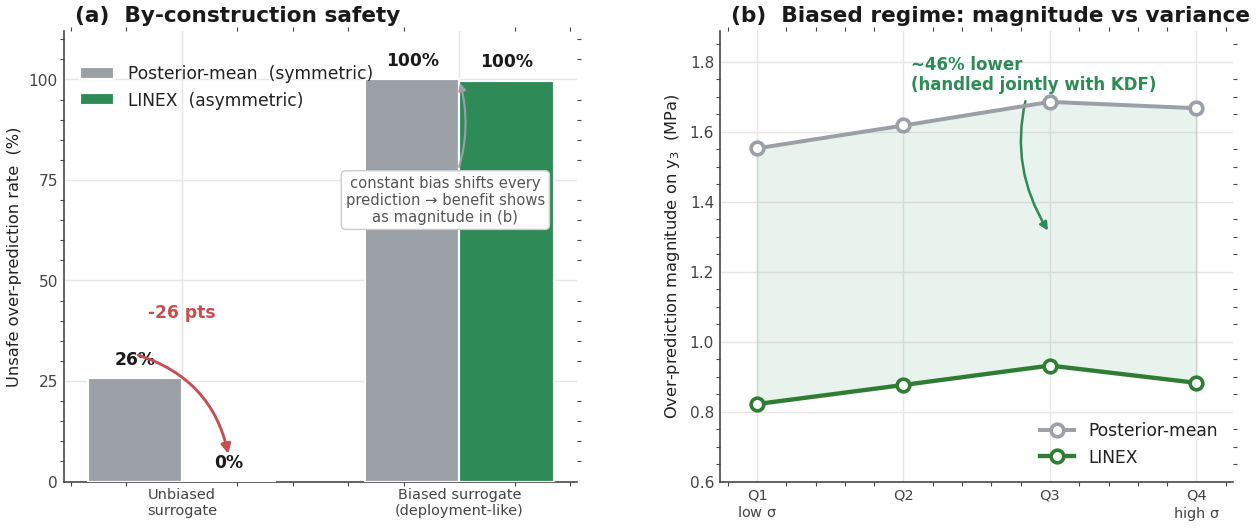

In [28]:
import numpy as np
from numpy.linalg import slogdet
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.linalg import cho_factor, cho_solve

SQRT5 = np.sqrt(5.0)

# ----------------------------- ICM-GP (numpy/scipy) -----------------------------
def matern52_ard(Xa, Xb, ls):
    d2 = ((Xa[:,None,:]-Xb[None,:,:])/ls[None,None,:])**2
    r = np.sqrt(np.sum(d2,2)+1e-12)
    return (1+SQRT5*r+5.0/3.0*r**2)*np.exp(-SQRT5*r)

class ICMGP:
    """Multi-task GP, intrinsic coregionalisation: K = Kx ⊗ B + noise.
       Kx = sf_m^2*Matern52_ARD + sf_l^2*Linear ;  B = W W^T + diag(kappa)."""
    def __init__(self, T=4, rank=2): self.T=T; self.rank=rank
    def _unpack(self, p, d):
        i=0
        ls=np.exp(p[i:i+d]); i+=d
        sf_m=np.exp(p[i]); i+=1
        sf_l=np.exp(p[i]); i+=1
        W=p[i:i+self.T*self.rank].reshape(self.T,self.rank); i+=self.T*self.rank
        kappa=np.exp(p[i:i+self.T]); i+=self.T
        noise=np.exp(p[i:i+self.T]); i+=self.T
        return ls,sf_m,sf_l,W,kappa,noise
    def _Kx(self,Xa,Xb,ls,sf_m,sf_l):
        return sf_m**2*matern52_ard(Xa,Xb,ls)+sf_l**2*(Xa@Xb.T)
    def _nlml(self,p,X,Yvec,d,N):
        ls,sf_m,sf_l,W,kappa,noise=self._unpack(p,d)
        B=W@W.T+np.diag(kappa)
        Kx=self._Kx(X,X,ls,sf_m,sf_l)
        K=np.kron(Kx,B)
        K[np.arange(N*self.T),np.arange(N*self.T)]+=np.repeat(noise,N).reshape(self.T,N).T.ravel()*0+ \
            np.tile(noise,N)  # per-task noise on diagonal (point-major ordering)
        K+=1e-8*np.eye(N*self.T)
        try:
            c,low=cho_factor(K, lower=True)
        except Exception:
            return 1e12
        a=cho_solve((c,low),Yvec)
        logdet=2*np.sum(np.log(np.diag(c)))
        return 0.5*Yvec@a+0.5*logdet+0.5*N*self.T*np.log(2*np.pi)
    def fit(self,X,Y,restarts=2,seed=0):
        N,T=Y.shape; d=X.shape[1]; self.X=X; self.Y=Y; self.d=d
        Yvec=Y.ravel()  # point-major: y[i*T+t]
        rng=np.random.RandomState(seed); best=None
        n_p=d+2+T*self.rank+T+T
        for r in range(restarts):
            p0=np.concatenate([np.log(np.full(d,0.5))+0.1*rng.randn(d),
                               [0.0,-1.0],
                               0.3*rng.randn(T*self.rank),
                               np.log(np.full(T,0.5)),
                               np.log(np.full(T,0.1))])
            res=minimize(self._nlml,p0,args=(X,Yvec,d,N),method="L-BFGS-B",
                         options=dict(maxiter=300))
            if best is None or res.fun<best.fun: best=res
        self.p=best.x; self.nlml=best.fun
        ls,sf_m,sf_l,W,kappa,noise=self._unpack(self.p,d)
        self.ls,self.sf_m,self.sf_l,self.W,self.kappa,self.noise=ls,sf_m,sf_l,W,kappa,noise
        self.B=W@W.T+np.diag(kappa)
        Kx=self._Kx(X,X,ls,sf_m,sf_l); K=np.kron(Kx,self.B)
        K[np.arange(N*T),np.arange(N*T)]+=np.tile(noise,N)+1e-8
        self.c=cho_factor(K,lower=True); self.alpha=cho_solve(self.c,Yvec)
        self.Kx_tr=Kx
        return self
    def predict(self,Xs):
        Ns=Xs.shape[0]; T=self.T; N=self.X.shape[0]
        Kxs=self._Kx(Xs,self.X,self.ls,self.sf_m,self.sf_l)   # Ns x N
        Ks=np.kron(Kxs,self.B)                                # (Ns*T) x (N*T)
        mu=(Ks@self.alpha).reshape(Ns,T)
        Kss_diag=self._Kx(Xs,Xs,self.ls,self.sf_m,self.sf_l).diagonal()
        v=cho_solve(self.c,Ks.T)                              # (N*T) x (Ns*T)
        var=np.empty((Ns,T))
        for t in range(T):
            Btt=self.B[t,t]
            idx=np.arange(Ns)*T+t
            quad=np.einsum('ij,ij->i',Ks[idx,:],v[:,idx].T)
            var[:,t]=np.maximum(Kss_diag*Btt+self.noise[t]-quad,1e-9)
        return mu,np.sqrt(var)
    def loo_mean_var(self):
        """Closed-form LOO mean and variance (Rasmussen 5.12), scaled space."""
        Kx=self.Kx_tr; K=np.kron(Kx,self.B); N=self.X.shape[0]
        K[np.arange(N*self.T),np.arange(N*self.T)]+=np.tile(self.noise,N)+1e-8
        Kinv=np.linalg.inv(K); yv=self.Y.ravel(); d=np.diag(Kinv)
        mu=yv-(Kinv@yv)/d; var=1.0/d
        return mu.reshape(N,self.T), var.reshape(N,self.T)
    def loo(self):
        """Closed-form leave-one-element-out predictive mean (Rasmussen 5.12)."""
        Kx=self.Kx_tr; K=np.kron(Kx,self.B)
        N=self.X.shape[0]
        K[np.arange(N*self.T),np.arange(N*self.T)]+=np.tile(self.noise,N)+1e-8
        Kinv=np.linalg.inv(K); yv=self.Y.ravel()
        mu_loo=yv-(Kinv@yv)/np.diag(Kinv)
        return mu_loo.reshape(N,self.T)


def linex_action(mu,sg,a): return mu - a*sg**2/2.0

# ===================== safety computation (verified) =====================
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats
A=1.5; SAFE=2; rng=np.random.RandomState(7)
def Vf(x): return np.clip(0.6*x[:,2]+0.4*(1-x[:,0])+0.1*x[:,1],0,1.2)
def truef(x):
    v=Vf(x); y1=15+30*(0.6*(1-x[:,0])+0.5*x[:,2]-0.3*x[:,3])
    return np.column_stack([y1,300+300*v,10+14*v,0.5+5.0*v])
Xtr=rng.rand(38,4); Ytr=truef(Xtr)+rng.normal(0,[1.0,16,1.2,0.35],size=(38,4))
sx=MinMaxScaler().fit(Xtr); sy=StandardScaler().fit(Ytr)
gp=ICMGP(4,2).fit(sx.transform(Xtr),sy.transform(Ytr),restarts=2,seed=3)
Xte=rng.rand(4000,4); mu_s,sd_s=gp.predict(sx.transform(Xte))
mu=sy.inverse_transform(mu_s); sd=sd_s*sy.scale_[None,:]
muS,sdS=mu[:,SAFE],sd[:,SAFE]
d_mean=muS; d_lin=linex_action(muS,sdS,A)
tru_u=truef(Xte)[:,SAFE]; tru_b=tru_u*0.90
rate_u=[100*np.mean(d_mean>tru_u),100*np.mean(d_lin>tru_u)]
rate_b=[100*np.mean(d_mean>tru_b),100*np.mean(d_lin>tru_b)]
bins=np.quantile(sdS,[0,.25,.5,.75,1.0])
mq=[np.clip(d_mean-tru_b,0,None)[(sdS>=bins[k])&(sdS<=bins[k+1])].mean() for k in range(4)]
lq=[np.clip(d_lin -tru_b,0,None)[(sdS>=bins[k])&(sdS<=bins[k+1])].mean() for k in range(4)]
red=100*(1-np.mean(lq)/np.mean(mq))
print(f"rates unbiased {rate_u} biased {rate_b} | magnitude reduction ~{red:.0f}%")

# ===================== PROFESSIONAL / STYLISH FIGURE =====================
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
plt.rcParams.update({
    "font.family":"DejaVu Sans","font.size":11,"axes.edgecolor":"#444444",
    "axes.linewidth":0.9,"axes.grid":True,"grid.color":"#E6E6E6","grid.linewidth":0.8,
    "axes.axisbelow":True,"xtick.color":"#444444","ytick.color":"#444444",
    "text.color":"#222222","axes.labelcolor":"#222222"})
INK="#1A1A1A"; GREY="#9AA0A6"; GREEN="#2E8B57"; ACCENT="#C44E52"; LINEXC="#2E7D32"
fig,(axL,axR)=plt.subplots(1,2,figsize=(11.6,4.5),gridspec_kw=dict(wspace=0.28))
for ax in (axL,axR):
    ax.spines[["top","right"]].set_visible(False)
    ax.tick_params(length=0)

# -- panel (a): grouped bars, no top title (label inside) --
groups=["Unbiased\nsurrogate","Biased surrogate\n(deployment-like)"]
x=np.arange(2); w=0.34
b1=axL.bar(x-w/2,[rate_u[0],rate_b[0]],w,color=GREY,label="Posterior-mean  (symmetric)",zorder=3,edgecolor="white",linewidth=1.2)
b2=axL.bar(x+w/2,[rate_u[1],rate_b[1]],w,color=GREEN,label="LINEX  (asymmetric)",zorder=3,edgecolor="white",linewidth=1.2)
axL.set_ylim(0,112); axL.set_xticks(x); axL.set_xticklabels(groups)
axL.yaxis.set_major_locator(MultipleLocator(25)); axL.set_ylabel("Unsafe over-prediction rate  (%)")
for rects in (b1,b2):
    for r in rects:
        h=r.get_height(); axL.text(r.get_x()+r.get_width()/2,h+2.5,f"{h:.0f}%",ha="center",va="bottom",fontsize=9.5,color=INK,fontweight="bold")
# arrow annotating the unbiased reduction
axL.annotate("",xy=(x[0]+w/2,rate_u[1]+6),xytext=(x[0]-w/2,rate_u[0]+6),
             arrowprops=dict(arrowstyle="-|>",color=ACCENT,lw=1.6,connectionstyle="arc3,rad=-0.3"))
axL.text(x[0],rate_u[0]+15,f"-{rate_u[0]-rate_u[1]:.0f} pts",ha="center",color=ACCENT,fontsize=9.5,fontweight="bold")
axL.text(0.02,1.02,"(a)  By-construction safety",transform=axL.transAxes,fontsize=12,fontweight="bold",color=INK)
axL.legend(frameon=False,fontsize=9.5,loc="upper left",bbox_to_anchor=(0.0,0.96))
# clarity cue: biased bars saturate -> the benefit is in magnitude (panel b)
axL.annotate("constant bias shifts every\nprediction \u2192 benefit shows\nas magnitude in (b)",
             xy=(x[1], 100), xytext=(x[1]-0.05, 70),
             ha="center", va="center", fontsize=8.2, color="#555555",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#CCCCCC", lw=0.8),
             arrowprops=dict(arrowstyle="-|>", color="#9AA0A6", lw=1.2,
                             connectionstyle="arc3,rad=0.2"))

# -- panel (b): magnitude vs sigma, clean lines + fill --
q=np.arange(4); lab=["Q1\nlow $\\sigma$","Q2","Q3","Q4\nhigh $\\sigma$"]
axR.plot(q,mq,"-o",color=GREY,lw=2.2,ms=7,mfc="white",mec=GREY,mew=2,label="Posterior-mean",zorder=4)
axR.plot(q,lq,"-o",color=LINEXC,lw=2.4,ms=7,mfc="white",mec=LINEXC,mew=2,label="LINEX",zorder=5)
axR.fill_between(q,lq,mq,color=GREEN,alpha=0.10,zorder=2)
axR.set_xticks(q); axR.set_xticklabels(lab); axR.set_xlim(-0.25,3.25)
axR.set_ylabel("Over-prediction magnitude on $y_3$  (MPa)")
axR.set_ylim(0.6,max(mq)*1.12)
axR.annotate(f"~{red:.0f}% lower\n(handled jointly with KDF)",xy=(2,(mq[2]+lq[2])/2),
             xytext=(1.05,max(mq)*1.02),fontsize=9.2,color=GREEN,fontweight="bold",
             arrowprops=dict(arrowstyle="-|>",color=GREEN,lw=1.4,connectionstyle="arc3,rad=0.25"))
axR.text(0.02,1.02,"(b)  Biased regime: magnitude vs variance",transform=axR.transAxes,fontsize=12,fontweight="bold",color=INK)
axR.legend(frameon=False,fontsize=9.5,loc="lower right")

fig.savefig("Fig12_safety.pdf",bbox_inches="tight")
fig.savefig("Fig12_safety.png",dpi=300,bbox_inches="tight")
fig.savefig("Fig12_safety_300dpi.tiff",dpi=300,bbox_inches="tight",pil_kwargs={"compression":"tiff_lzw"})
fig.savefig("Fig12_safety_600dpi.tiff",dpi=600,bbox_inches="tight",pil_kwargs={"compression":"tiff_lzw"})
plt.show()